# BNP Paribas- Bussines Case Project 2025/2026
**DATA VISUALIZATION AND PREPROCESSING NOTEBOOK**

**Project developed by Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

## 1. Import the needed libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from suport import *
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score   
from sklearn.impute import KNNImputer 

## 2. Data importation

In [ ]:
#pip install pandas pyarrow
#!pip install fastparquet

In [ ]:
file_path_CRC = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\crc.parquet"
file_path_CREDSCORE = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BNP-Paribas\credscore.parquet"
file_path_BDOSS = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\bdoss.parquet"
file_path_FAMA = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BNP-Paribas\fama.parquet"

CRC = pd.read_parquet(file_path_CRC, engine="fastparquet")
CREDSCORE = pd.read_parquet(file_path_CREDSCORE, engine="fastparquet")
FAMA = pd.read_parquet(file_path_FAMA, engine="fastparquet")
BDOSS = pd.read_parquet(file_path_BDOSS, engine="fastparquet")

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# CRC Dataset
       
</div>


## 3. Data exploration and understanding

**METADATA:**
- *Date_Obs*: Observation Date (MMYY).
- *MT_MENSAL*: Sum of monthly installments paid by the client.
- *COUNT_CL*: Consumer credit count.
- *COUNT_CP*: Credit card or revolving credit count.
- *COUNT_AUTO*:  Auto loan credit count.
- *COUNT_HT*: Mortgage credit count.
- *COUNT_CONEXO*: Connected credit count.
- *COUNT_OTHER*: Other credits count.
- *COUNT_TOTAL*: Total credits count.
- *MONTVENC_CL*:  Sum of overdue amounts in consumer credit. 
- *MONTVENC_CP*:  Sum of overdue amounts in credit card and revolving credit.
- *MONTVENC_AUTO*:  Sum of overdue amounts in auto loans.
- *MONTVENC_HT*:  Sum of overdue amounts in mortgages.
- *MONTABATV_CL*:  Sum of written-off amounts in consumer credit.
- *MONTABATV_CP*:  Sum of written-off amounts in credit card and revolving credit.
- *MONTABATV_AUTO*:  Sum of written-off amounts in auto loans.
- *MONTABATV_HT*:  Sum of written-off amounts in mortgages.
- *DIVIDAS_CL*:   Total consumer credit debt.
- *DIVIDAS_CP*:  Total credit card and revolving credit debt.
- *DIVIDAS_AUTO*: Total auto loan debt.
- *DIVIDAS_HT*: Total mortgage debt.

### 3.1. Data Overview

In [3]:
#overview the dataset
CRC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3034921 entries, 0 to 3034920
Data columns (total 22 columns):
 #   Column          Dtype         
---  ------          -----         
 0   CONTRIB         object        
 1   OBS_DATE        datetime64[ns]
 2   MT_MENSAL       float64       
 3   COUNT_CL        float64       
 4   COUNT_CP        float64       
 5   COUNT_AUTO      float64       
 6   COUNT_HT        float64       
 7   COUNT_CONEXO    float64       
 8   COUNT_OTHER     float64       
 9   COUNT_TOTAL     float64       
 10  MONTVENC_CL     float64       
 11  MONTVENC_CP     float64       
 12  MONTVENC_AUTO   float64       
 13  MONTVENC_HT     float64       
 14  MONTABATV_CL    float64       
 15  MONTABATV_CP    float64       
 16  MONTABATV_AUTO  float64       
 17  MONTABATV_HT    float64       
 18  DIVIDAS_CL      float64       
 19  DIVIDAS_CP      float64       
 20  DIVIDAS_AUTO    float64       
 21  DIVIDAS_HT      float64       
dtypes: datetime64[ns](

At first sight we can understand that: 
- The most important (serious ones) are the MONTABATV. If those variables are too high, the client is not trustworthy.
- It is normal for a client to have "DIVIDAS", but is preferable if they reduce month to month.

In [4]:
#first 20 rows
CRC.head(20)

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,...,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2023-12-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6842.10,963.55,0.00,0.00
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,2023-12-31,547.18,4.0,5.0,0.0,0.0,0.0,1.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,28532.06,7115.46,0.00,0.00
2,0000f858346061c53064586a3347b34659565a6712d004...,2023-12-31,NaN,1.0,5.0,1.0,1.0,0.0,0.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2957.28,2150.90,2408.56,85549.49
3,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,2023-12-31,515.57,3.0,1.0,0.0,0.0,0.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,27120.42,152.95,0.00,0.00
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,2023-12-31,NaN,8.0,3.0,0.0,0.0,0.0,1.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,46104.39,4128.54,0.00,0.00
5,000508d6436a34b780df1aa8068568f1b118f5d589ddc7...,2023-12-31,NaN,0.0,5.0,0.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1219.82,0.00,0.00
6,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6...,2023-12-31,113.79,1.0,2.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3876.44,273.70,0.00,0.00
7,0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a9...,2023-12-31,1802.33,4.0,3.0,0.0,1.0,0.0,0.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,33512.86,12494.52,0.00,169533.98
8,000607d1adce7aa9ac87274d1a2ffa84e240188de0872f...,2023-12-31,NaN,0.0,4.0,0.0,1.0,1.0,1.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,4803.57,0.00,50195.43
9,00063f4ff357806252119717d819d2f5acb3bc68cf56a7...,2023-12-31,93.64,1.0,1.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3233.72,3570.00,0.00,0.00


In [5]:
#last 20 rows
CRC.tail(20)

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,...,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
3034901,fff7a7c5b2ad6a0c1de016614040047f7355e0c7d87514...,2025-12-31,NaN,1.0,5.0,1.0,1.0,0.0,2.0,10.0,...,0.00,0.0,0.0,0.0,0.0,0.0,571.67,470.21,3584.60,89681.61
3034902,fff7b0e56b9fa839796052774400e1def4402ea414142d...,2025-12-31,NaN,0.0,1.0,1.0,1.0,0.0,2.0,5.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.00,380.72,3343.45,82113.70
3034903,fff8aeb0ed2090d1a11420a889cd821a9d6b2989857373...,2025-12-31,NaN,0.0,3.0,1.0,2.0,0.0,1.0,7.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.00,3328.32,8580.67,85462.74
3034904,fff9b4ec881528770eb45d95f3d1fdc4918b353d27ced0...,2025-12-31,NaN,1.0,2.0,0.0,0.0,0.0,0.0,3.0,...,0.00,0.0,0.0,0.0,0.0,0.0,4753.55,0.00,0.00,0.00
3034905,fff9d46434f2c40c84b4bfe268c53fa0351ee861bd46f7...,2025-12-31,NaN,0.0,5.0,0.0,1.0,0.0,1.0,7.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.00,432.97,0.00,69734.80
3034906,fff9d6d8fa1e236901f5dfd67c755b924aa7fa97525011...,2025-12-31,505.10,1.0,4.0,2.0,0.0,0.0,0.0,7.0,...,0.00,0.0,0.0,0.0,0.0,0.0,12909.20,1598.43,6147.46,0.00
3034907,fffa1f8ea172263443e76caa5bef96a4415e5b9a7851c0...,2025-12-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,...,0.00,0.0,0.0,0.0,0.0,0.0,1968.90,284.21,0.00,0.00
3034908,fffa36f944396a3e75f9c54900165502a3eb725962144b...,2025-12-31,NaN,0.0,3.0,0.0,0.0,0.0,0.0,3.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.00,1048.34,0.00,0.00
3034909,fffa9b9225bff7296ad890805ea9ccf9a105663acb1a97...,2025-12-31,1055.07,3.0,1.0,1.0,1.0,1.0,0.0,7.0,...,0.00,0.0,0.0,0.0,0.0,0.0,27893.90,1628.12,18782.41,61600.85
3034910,fffa9ff4598e3f04fa8eef5903352d5130126481085b18...,2025-12-31,NaN,2.0,5.0,0.0,0.0,0.0,1.0,8.0,...,0.00,0.0,0.0,0.0,0.0,0.0,4918.55,4771.00,0.00,0.00


In [6]:
#descriptive statistics for numerical data
CRC.describe().round(2)

,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,...,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
count,3034921,1029718.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,...,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00
mean,2025-01-01 06:09:42.119141376,552.09,1.65,3.09,0.55,0.46,0.07,0.67,6.49,103.33,...,19.69,37.85,4.34,4.27,0.30,0.47,11438.98,2624.60,5403.67,30449.71
min,2023-12-31 00:00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2024-06-30 00:00:00,236.67,1.00,2.00,0.00,0.00,0.00,0.00,4.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1128.30,132.84,0.00,0.00
50%,2024-12-31 00:00:00,446.60,1.00,3.00,0.00,0.00,0.00,0.00,6.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,6160.02,1133.66,0.00,0.00
75%,2025-06-30 00:00:00,724.99,2.00,4.00,1.00,1.00,0.00,1.00,8.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,15248.11,3219.76,8243.23,46515.51
max,2025-12-31 00:00:00,1224049.39,90.00,183.00,26.00,36.00,15.00,72.00,330.00,2923893.44,...,130756.11,807322.92,171424.67,62861.30,33127.84,288803.22,3194523.32,480181.93,514850.48,4582324.44
std,NaN,1736.58,1.65,2.41,0.76,0.73,0.30,0.88,4.07,2818.38,...,591.92,2541.25,285.17,209.89,59.54,211.27,17905.50,4414.23,9711.06,59607.22


- The dataset presents information from Dec 2023 to Dec 2025: this indicates we have very up to date data. 
- Many variables have almost 75% of data equal to 0, which can affect our model and interpretation. 

In [7]:
#To each client, checking the maximum and minimum number of each variable to facilitate the interpretation
CRC.groupby('CONTRIB').agg(['min', 'max'])

OBS_DATE             \
                                                          min        max   
CONTRIB                                                                    
00008246f87bcc3c17b90629bb183fe2e58795176310f01... 2023-12-31 2025-12-31   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349... 2023-12-31 2025-12-31   
0000f858346061c53064586a3347b34659565a6712d004e... 2023-12-31 2025-12-31   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6... 2023-12-31 2025-12-31   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd... 2023-12-31 2025-11-30   
...                                                       ...        ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67... 2023-12-31 2025-12-31   
fffc991d73df732084dab58938d520b8a5d8712474fa539... 2023-12-31 2025-12-31   
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9... 2023-12-31 2025-12-31   
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c... 2023-12-31 2025-12-31   
ffff943c736f98d4840f65328ba372a29689312dd781b43... 2023-12-31 2025-08-31   

                                                   MT_MENSAL           \
                                                         min      max   
CONTRIB                                                                 
00008246f87bcc3c17b90629bb183fe2e58795176310f01...       NaN      NaN   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349...    538.67   547.45   
0000f858346061c53064586a3347b34659565a6712d004e...       NaN      NaN   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6...    515.57   515.57   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd...       NaN      NaN   
...                                                      ...      ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67...    305.96  1031.51   
fffc991d73df732084dab58938d520b8a5d8712474fa539...       NaN      NaN   
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9...       NaN      NaN   
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c...       NaN      NaN   
ffff943c736f98d4840f65328ba372a29689312dd781b43...       NaN      NaN   

                                                   COUNT_CL       COUNT_CP  \
                                                        min   max      min   
CONTRIB                                                                      
00008246f87bcc3c17b90629bb183fe2e58795176310f01...      0.0   1.0      3.0   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349...      4.0  12.0      5.0   
0000f858346061c53064586a3347b34659565a6712d004e...      1.0   2.0      5.0   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6...      3.0   3.0      1.0   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd...      8.0  36.0      3.0   
...                                                     ...   ...      ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67...      1.0   3.0      2.0   
fffc991d73df732084dab58938d520b8a5d8712474fa539...      0.0   1.0      2.0   
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9...      1.0   1.0      1.0   
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c...      2.0   3.0      1.0   
ffff943c736f98d4840f65328ba372a29689312dd781b43...      0.0   1.0      3.0   

                                                         COUNT_AUTO       ...  \
                                                     max        min  max  ...   
CONTRIB                                                                   ...   
00008246f87bcc3c17b90629bb183fe2e58795176310f01...   9.0        0.0  6.0  ...   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349...  15.0        0.0  0.0  ...   
0000f858346061c53064586a3347b34659565a6712d004e...  10.0        1.0  2.0  ...   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6...   2.0        0.0  0.0  ...   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd...  16.0        0.0  0.0  ...   
...                                                  ...        ...  ...  ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67...   8.0        0.0  1.0  ...   
fffc991d73df732084dab58938d520b8a5d8712474fa539...   2.0      

In [8]:
#how many months of data do we have per client
CRC['CONTRIB'].value_counts()

CONTRIB
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b    25
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9adcf1007f61b9a9c4    25
0010e3d14c44e09d7939962038d87bcbfca2e0c1021778efb4c464b07f460b43    25
0010590e59808eac98cd5ea30fdf722110a82061d3e77d8de7775d014d7d2eee    25
000c1d07343251f8247578d802494996ca054de69ae681decedb188e037ba40b    25
                                                                    ..
c108a77ce77ff7887ab9ceecd19aa6f8f179050b6b3fddd19e25a14fc48c5763     1
bc1a2ee37e62f4aae09e7c067f5d9a9d936b88e2b385fb43864ded8cfeb771c1     1
b34a4691a74ff5ce9d7e24d4e370e122158d6a6cd89535f6153f2e0d719acbb1     1
d848e1e52e3a1237d2b232f617f8d6ab8561e7a8c8322bcb4f5ec495e86904de     1
66c3457d810521e2e98194577aeeb3b6f2aa0f47bdf4920662077d1609fab76c     1
Name: count, Length: 141663, dtype: int64

- It is possible see that not all clients have the information for all months.

In [9]:
#sort data by 'CONTRIB' and 'OBS_DATE'
pd.set_option('display.max_columns', None)
CRC.sort_values(by=['CONTRIB','OBS_DATE'], ascending=False)
CRC.head(25)

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2023-12-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,6842.10,963.55,0.00,0.00
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,2023-12-31,547.18,4.0,5.0,0.0,0.0,0.0,1.0,10.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,28532.06,7115.46,0.00,0.00
2,0000f858346061c53064586a3347b34659565a6712d004...,2023-12-31,NaN,1.0,5.0,1.0,1.0,0.0,0.0,8.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,2957.28,2150.90,2408.56,85549.49
3,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,2023-12-31,515.57,3.0,1.0,0.0,0.0,0.0,1.0,5.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,27120.42,152.95,0.00,0.00
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,2023-12-31,NaN,8.0,3.0,0.0,0.0,0.0,1.0,12.0,810.88,0.00,0.0,0.0,0.0,0.0,0.0,0.0,46104.39,4128.54,0.00,0.00
5,000508d6436a34b780df1aa8068568f1b118f5d589ddc7...,2023-12-31,NaN,0.0,5.0,0.0,0.0,0.0,0.0,5.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1219.82,0.00,0.00
6,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6...,2023-12-31,113.79,1.0,2.0,0.0,0.0,0.0,0.0,3.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,3876.44,273.70,0.00,0.00
7,0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a9...,2023-12-31,1802.33,4.0,3.0,0.0,1.0,0.0,0.0,8.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,33512.86,12494.52,0.00,169533.98
8,000607d1adce7aa9ac87274d1a2ffa84e240188de0872f...,2023-12-31,NaN,0.0,4.0,0.0,1.0,1.0,1.0,7.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,4803.57,0.00,50195.43
9,00063f4ff357806252119717d819d2f5acb3bc68cf56a7...,2023-12-31,93.64,1.0,1.0,0.0,0.0,0.0,0.0,2.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,3233.72,3570.00,0.00,0.00


In [10]:
#checking the unique values for 'DIVIDAS_CL'
CRC['DIVIDAS_CL'].value_counts(dropna=False)

DIVIDAS_CL
0.00        567067
5000.00       4716
3000.00       2347
2500.00       2330
10000.00      2130
             ...  
225.74           1
265.16           1
18250.96         1
18395.02         1
46222.13         1
Name: count, Length: 1463522, dtype: int64

### 3.2. Checking Duplicates

In [11]:
#checking number of duplicates
CRC.duplicated().sum()

np.int64(0)

### 3.3. Checking Missing Values

In [12]:
#checking number of missing values
CRC.isna().sum()

CONTRIB                 0
OBS_DATE                0
MT_MENSAL         2005203
COUNT_CL              172
COUNT_CP              172
COUNT_AUTO            172
COUNT_HT              172
COUNT_CONEXO          172
COUNT_OTHER           172
COUNT_TOTAL           172
MONTVENC_CL           172
MONTVENC_CP           172
MONTVENC_AUTO         172
MONTVENC_HT           172
MONTABATV_CL          172
MONTABATV_CP          172
MONTABATV_AUTO        172
MONTABATV_HT          172
DIVIDAS_CL            172
DIVIDAS_CP            172
DIVIDAS_AUTO          172
DIVIDAS_HT            172
dtype: int64

In [13]:
#checking umber of missing values in each column as a percentage
CRC.isna().sum()/len(CRC) * 100

CONTRIB            0.000000
OBS_DATE           0.000000
MT_MENSAL         66.071011
COUNT_CL           0.005667
COUNT_CP           0.005667
COUNT_AUTO         0.005667
COUNT_HT           0.005667
COUNT_CONEXO       0.005667
COUNT_OTHER        0.005667
COUNT_TOTAL        0.005667
MONTVENC_CL        0.005667
MONTVENC_CP        0.005667
MONTVENC_AUTO      0.005667
MONTVENC_HT        0.005667
MONTABATV_CL       0.005667
MONTABATV_CP       0.005667
MONTABATV_AUTO     0.005667
MONTABATV_HT       0.005667
DIVIDAS_CL         0.005667
DIVIDAS_CP         0.005667
DIVIDAS_AUTO       0.005667
DIVIDAS_HT         0.005667
dtype: float64

- MT_MENSAL have a lot of missing values (more than 66% of the observations are missing values)- it is likely to be a variable that do not gives us much information 
- All variables (except for *OBS_DATE*) have the same number of missing values which is likely to be the same observations- therefore it can be removed.

In [14]:
#checking obervations where 'COUNT_CL' have missing values
CRC[CRC['COUNT_CL'].isna()]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
16677,246028aa732dccdcbb4a59d0de5bf2195154a87c93349f...,2023-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36377,4e8dd38f4bf02f0ec56a3901a8bb0890f54bd6bd92a67b...,2023-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75904,a3aecd3b649fce86a1337dcb3f23a1dfa03a21dae0a46f...,2023-12-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81305,af6c29c28d7de808d1f86e00b6a279ed9c5cc3119dc8c0...,2023-12-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87441,bc6a1a24545459c49741c0a3e21a7f0707b59a008902c2...,2023-12-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2764798,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2025-10-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2881432,bc6a1a24545459c49741c0a3e21a7f0707b59a008902c2...,2025-11-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2886934,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2025-11-30,394.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3002785,bc6a1a24545459c49741c0a3e21a7f0707b59a008902c2...,2025-12-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
#checking obervations where 'COUNT_CP' have missing values
CRC[CRC['COUNT_CP'].isna()]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
16677,246028aa732dccdcbb4a59d0de5bf2195154a87c93349f...,2023-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36377,4e8dd38f4bf02f0ec56a3901a8bb0890f54bd6bd92a67b...,2023-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75904,a3aecd3b649fce86a1337dcb3f23a1dfa03a21dae0a46f...,2023-12-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81305,af6c29c28d7de808d1f86e00b6a279ed9c5cc3119dc8c0...,2023-12-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87441,bc6a1a24545459c49741c0a3e21a7f0707b59a008902c2...,2023-12-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2764798,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2025-10-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2881432,bc6a1a24545459c49741c0a3e21a7f0707b59a008902c2...,2025-11-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2886934,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2025-11-30,394.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3002785,bc6a1a24545459c49741c0a3e21a7f0707b59a008902c2...,2025-12-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.4. Checking Outliers

In [16]:
#setting metric fearures
metric_features= [ 'MT_MENSAL','COUNT_CL', 'COUNT_CP', 'COUNT_AUTO', 'COUNT_HT', 'COUNT_CONEXO', 'COUNT_OTHER', 'COUNT_TOTAL', 'MONTVENC_CL', 'MONTVENC_CP', 'MONTVENC_AUTO', 'MONTVENC_HT', 'MONTABATV_CL', 'MONTABATV_CP', 'MONTABATV_AUTO', 'MONTABATV_HT', 'DIVIDAS_CL', 'DIVIDAS_CP', 'DIVIDAS_AUTO', 'DIVIDAS_HT']

In [17]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables' Box Plots (>0 only)"):
    
    n_rows = ceil(len(feats) / n_cols)
    
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )
    
    axes = axes.flatten()
    
    for i, feat in enumerate(feats):
        
        # Keep only values strictly greater than 0
        values = data[feat]
        values = values[(values > 0) & (values.notna())]
        
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i])
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no >0 values)", fontsize=10)
    
    # Remove unused subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [18]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables - Box Plots"):

    #defining grid size
    n_rows = ceil(len(feats) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )

    axes = axes.flatten()
    #looping through features
    for i, feat in enumerate(feats):

        #keeping ALL values except missing ones
        values = data[feat].dropna()

        #plotting only if there is data
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i], color="#798a40")
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no data)", fontsize=10)

    # removing empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])

    # final layout adjustments
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

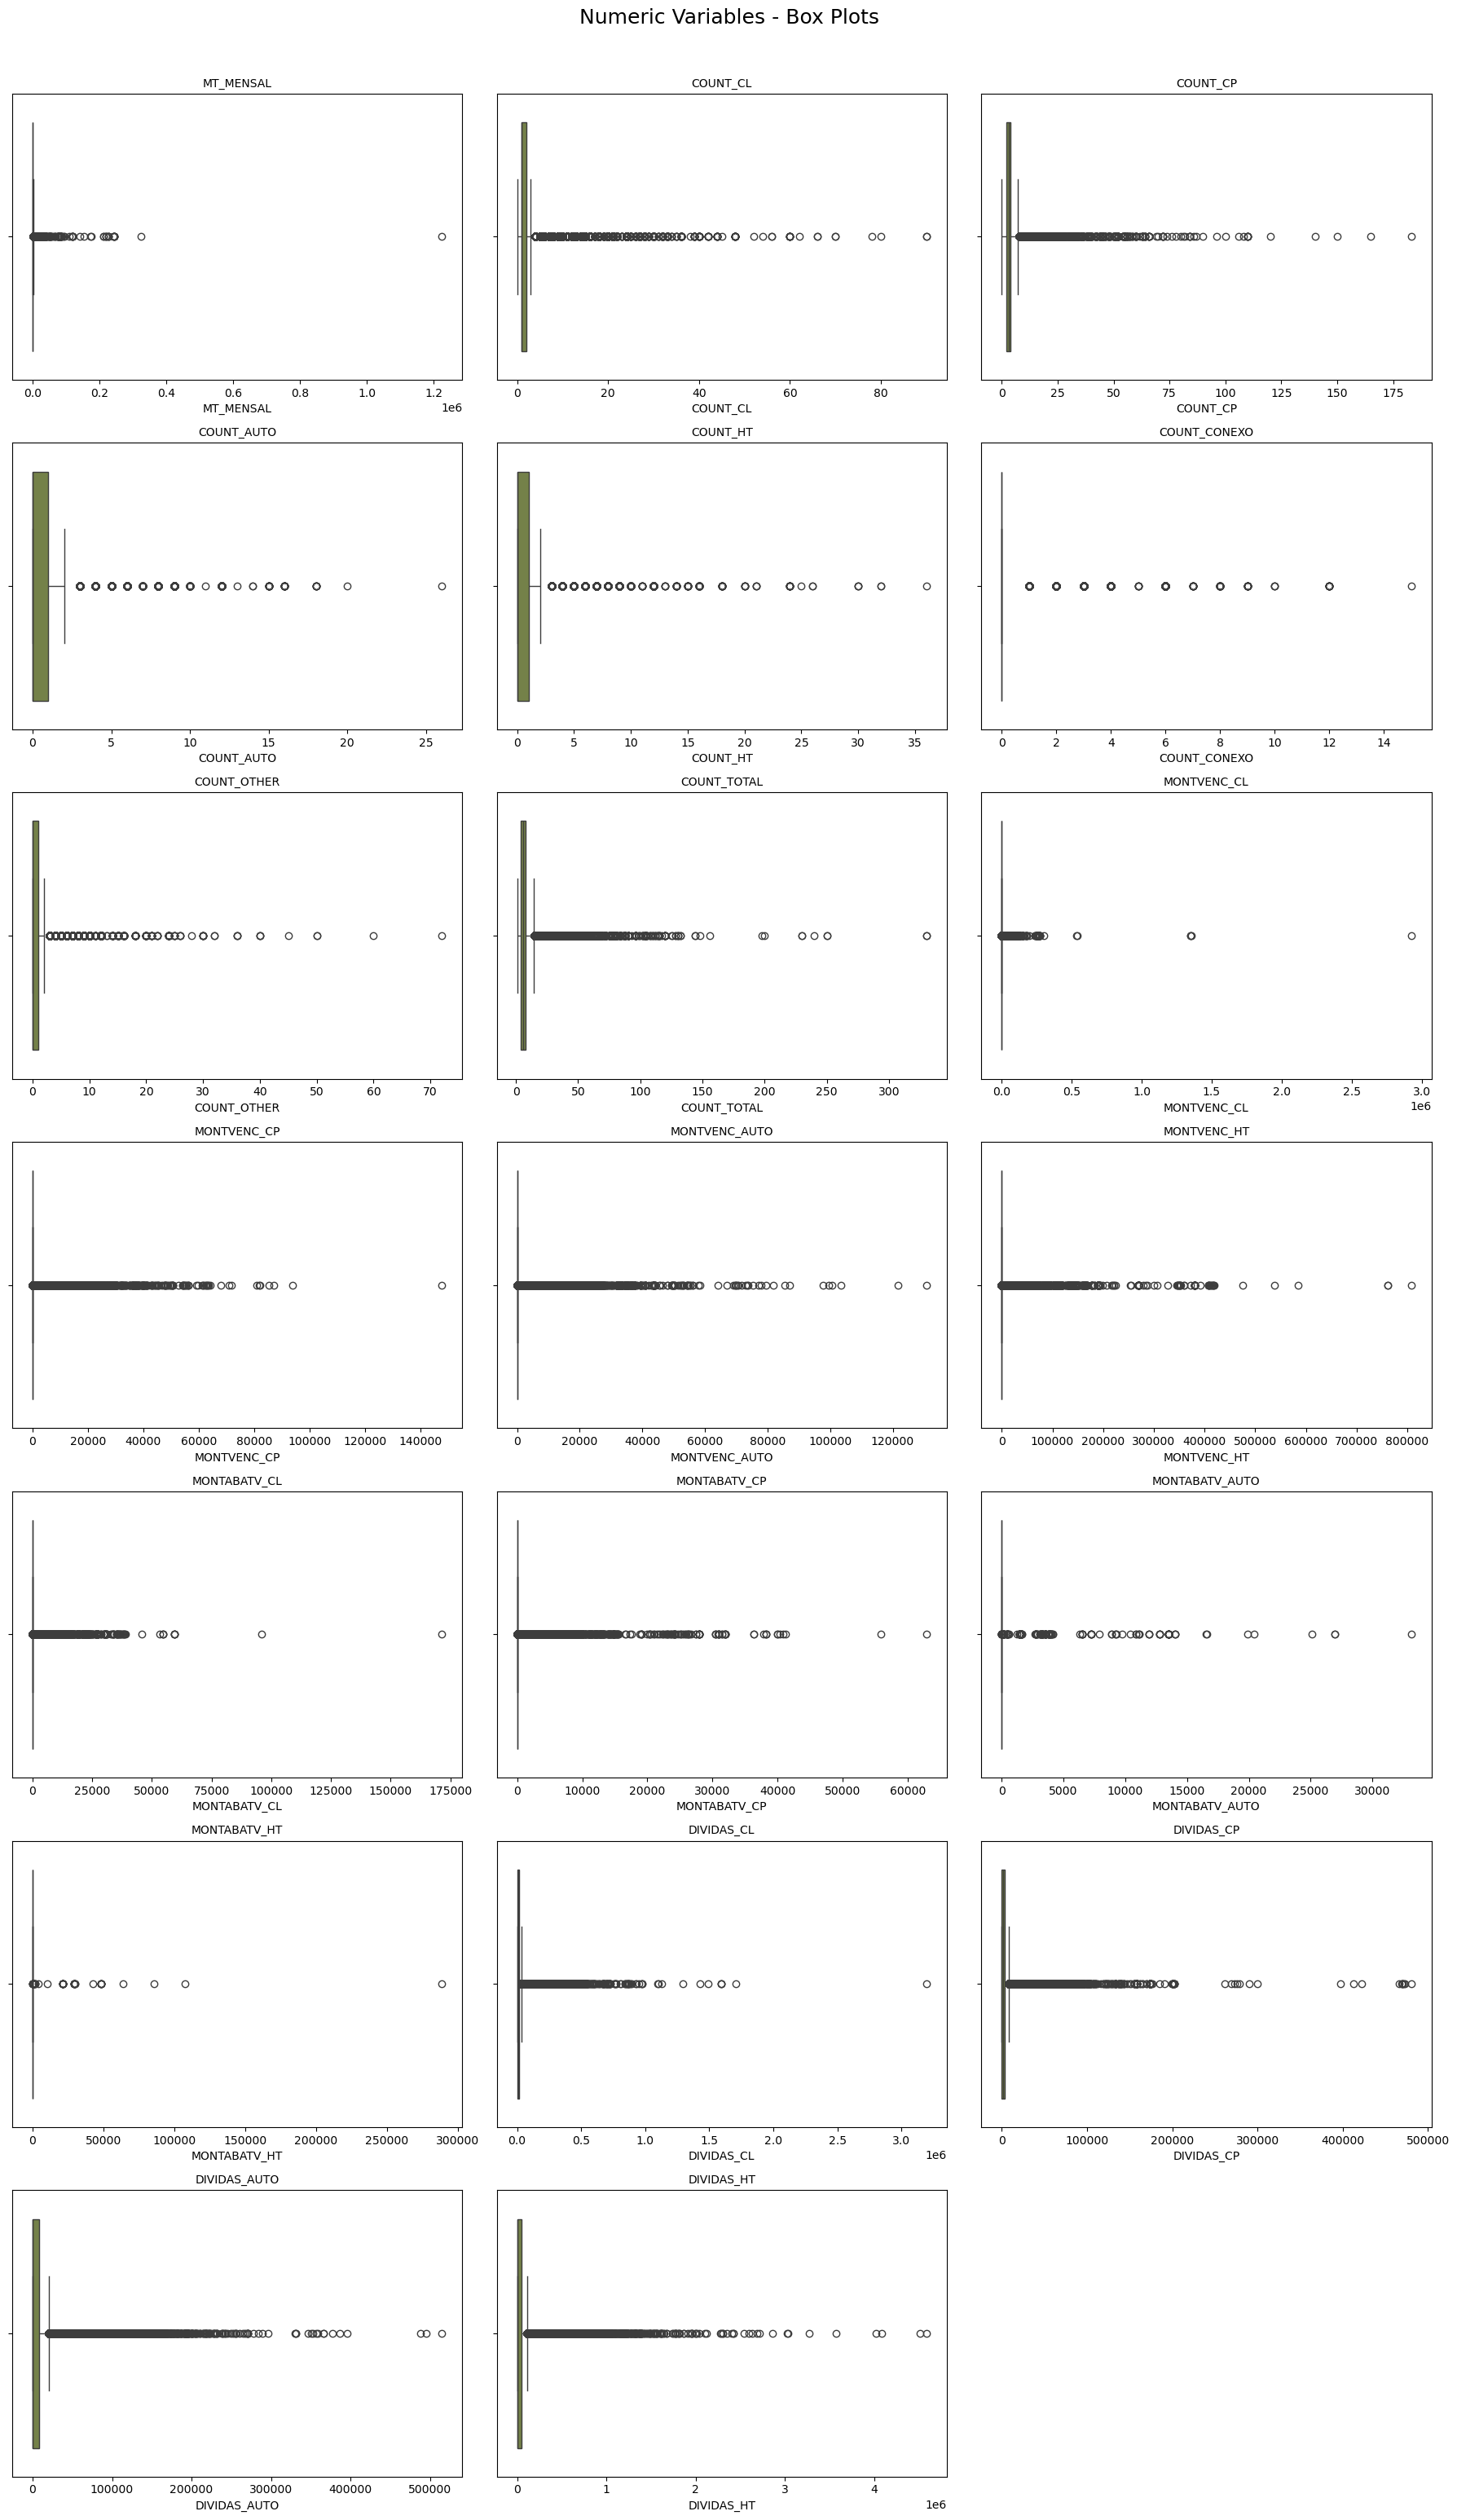

In [19]:
#applying the function to our numerical features
plot_multiple_boxplots(CRC, metric_features)

In [20]:
#checking nº of observations where 'COUNT_CL'> 50
CRC[CRC['COUNT_CL'] > 50].count()

CONTRIB           20
OBS_DATE          20
MT_MENSAL         14
COUNT_CL          20
COUNT_CP          20
COUNT_AUTO        20
COUNT_HT          20
COUNT_CONEXO      20
COUNT_OTHER       20
COUNT_TOTAL       20
MONTVENC_CL       20
MONTVENC_CP       20
MONTVENC_AUTO     20
MONTVENC_HT       20
MONTABATV_CL      20
MONTABATV_CP      20
MONTABATV_AUTO    20
MONTABATV_HT      20
DIVIDAS_CL        20
DIVIDAS_CP        20
DIVIDAS_AUTO      20
DIVIDAS_HT        20
dtype: int64

In [21]:
#checking nº of observations where 'COUNT_CP'> 100
CRC[CRC['COUNT_CP'] > 100].count()

CONTRIB           12
OBS_DATE          12
MT_MENSAL          9
COUNT_CL          12
COUNT_CP          12
COUNT_AUTO        12
COUNT_HT          12
COUNT_CONEXO      12
COUNT_OTHER       12
COUNT_TOTAL       12
MONTVENC_CL       12
MONTVENC_CP       12
MONTVENC_AUTO     12
MONTVENC_HT       12
MONTABATV_CL      12
MONTABATV_CP      12
MONTABATV_AUTO    12
MONTABATV_HT      12
DIVIDAS_CL        12
DIVIDAS_CP        12
DIVIDAS_AUTO      12
DIVIDAS_HT        12
dtype: int64

In [22]:
#checking nº of observations where 'COUNT_AUTO'> 15
CRC[CRC['COUNT_AUTO'] > 15].count()

CONTRIB           25
OBS_DATE          25
MT_MENSAL          6
COUNT_CL          25
COUNT_CP          25
COUNT_AUTO        25
COUNT_HT          25
COUNT_CONEXO      25
COUNT_OTHER       25
COUNT_TOTAL       25
MONTVENC_CL       25
MONTVENC_CP       25
MONTVENC_AUTO     25
MONTVENC_HT       25
MONTABATV_CL      25
MONTABATV_CP      25
MONTABATV_AUTO    25
MONTABATV_HT      25
DIVIDAS_CL        25
DIVIDAS_CP        25
DIVIDAS_AUTO      25
DIVIDAS_HT        25
dtype: int64

In [23]:
#checking nº of observations where 'COUNT_HT'> 20
CRC[CRC['COUNT_HT'] > 20].count()

CONTRIB           23
OBS_DATE          23
MT_MENSAL          6
COUNT_CL          23
COUNT_CP          23
COUNT_AUTO        23
COUNT_HT          23
COUNT_CONEXO      23
COUNT_OTHER       23
COUNT_TOTAL       23
MONTVENC_CL       23
MONTVENC_CP       23
MONTVENC_AUTO     23
MONTVENC_HT       23
MONTABATV_CL      23
MONTABATV_CP      23
MONTABATV_AUTO    23
MONTABATV_HT      23
DIVIDAS_CL        23
DIVIDAS_CP        23
DIVIDAS_AUTO      23
DIVIDAS_HT        23
dtype: int64

In [24]:
#checking nº of observations where 'COUNT_CONEXO'> 10
CRC[CRC['COUNT_CONEXO'] > 10].count()

CONTRIB           11
OBS_DATE          11
MT_MENSAL          6
COUNT_CL          11
COUNT_CP          11
COUNT_AUTO        11
COUNT_HT          11
COUNT_CONEXO      11
COUNT_OTHER       11
COUNT_TOTAL       11
MONTVENC_CL       11
MONTVENC_CP       11
MONTVENC_AUTO     11
MONTVENC_HT       11
MONTABATV_CL      11
MONTABATV_CP      11
MONTABATV_AUTO    11
MONTABATV_HT      11
DIVIDAS_CL        11
DIVIDAS_CP        11
DIVIDAS_AUTO      11
DIVIDAS_HT        11
dtype: int64

In [25]:
#checking nº of observations where 'COUNT_OTHER'> 30
CRC[CRC['COUNT_OTHER'] > 30].count()

CONTRIB           13
OBS_DATE          13
MT_MENSAL         10
COUNT_CL          13
COUNT_CP          13
COUNT_AUTO        13
COUNT_HT          13
COUNT_CONEXO      13
COUNT_OTHER       13
COUNT_TOTAL       13
MONTVENC_CL       13
MONTVENC_CP       13
MONTVENC_AUTO     13
MONTVENC_HT       13
MONTABATV_CL      13
MONTABATV_CP      13
MONTABATV_AUTO    13
MONTABATV_HT      13
DIVIDAS_CL        13
DIVIDAS_CP        13
DIVIDAS_AUTO      13
DIVIDAS_HT        13
dtype: int64

In [26]:
#checking nº of observations where 'MONTVENC_CL'> 300000
CRC[CRC['MONTVENC_CL'] > 300000].count()

CONTRIB           7
OBS_DATE          7
MT_MENSAL         7
COUNT_CL          7
COUNT_CP          7
COUNT_AUTO        7
COUNT_HT          7
COUNT_CONEXO      7
COUNT_OTHER       7
COUNT_TOTAL       7
MONTVENC_CL       7
MONTVENC_CP       7
MONTVENC_AUTO     7
MONTVENC_HT       7
MONTABATV_CL      7
MONTABATV_CP      7
MONTABATV_AUTO    7
MONTABATV_HT      7
DIVIDAS_CL        7
DIVIDAS_CP        7
DIVIDAS_AUTO      7
DIVIDAS_HT        7
dtype: int64

In [27]:
#checking nº of observations where 'MONTVENC_CP'> 60000
CRC[CRC['MONTVENC_CP'] > 60000].count()

CONTRIB           19
OBS_DATE          19
MT_MENSAL         13
COUNT_CL          19
COUNT_CP          19
COUNT_AUTO        19
COUNT_HT          19
COUNT_CONEXO      19
COUNT_OTHER       19
COUNT_TOTAL       19
MONTVENC_CL       19
MONTVENC_CP       19
MONTVENC_AUTO     19
MONTVENC_HT       19
MONTABATV_CL      19
MONTABATV_CP      19
MONTABATV_AUTO    19
MONTABATV_HT      19
DIVIDAS_CL        19
DIVIDAS_CP        19
DIVIDAS_AUTO      19
DIVIDAS_HT        19
dtype: int64

In [28]:
#checking nº of observations where 'MONTVENC_AUTO'> 70000
CRC[CRC['MONTVENC_AUTO'] > 70000].count()

CONTRIB           19
OBS_DATE          19
MT_MENSAL          5
COUNT_CL          19
COUNT_CP          19
COUNT_AUTO        19
COUNT_HT          19
COUNT_CONEXO      19
COUNT_OTHER       19
COUNT_TOTAL       19
MONTVENC_CL       19
MONTVENC_CP       19
MONTVENC_AUTO     19
MONTVENC_HT       19
MONTABATV_CL      19
MONTABATV_CP      19
MONTABATV_AUTO    19
MONTABATV_HT      19
DIVIDAS_CL        19
DIVIDAS_CP        19
DIVIDAS_AUTO      19
DIVIDAS_HT        19
dtype: int64

In [29]:
#checking nº of observations where 'MONTVENC_HT'> 400000
CRC[CRC['MONTVENC_HT'] > 400000].count()

CONTRIB           17
OBS_DATE          17
MT_MENSAL         15
COUNT_CL          17
COUNT_CP          17
COUNT_AUTO        17
COUNT_HT          17
COUNT_CONEXO      17
COUNT_OTHER       17
COUNT_TOTAL       17
MONTVENC_CL       17
MONTVENC_CP       17
MONTVENC_AUTO     17
MONTVENC_HT       17
MONTABATV_CL      17
MONTABATV_CP      17
MONTABATV_AUTO    17
MONTABATV_HT      17
DIVIDAS_CL        17
DIVIDAS_CP        17
DIVIDAS_AUTO      17
DIVIDAS_HT        17
dtype: int64

In [30]:
#checking nº of observations where 'MONTABATV_CL'> 50000
CRC[CRC['MONTABATV_CL'] > 50000].count()

CONTRIB           10
OBS_DATE          10
MT_MENSAL          2
COUNT_CL          10
COUNT_CP          10
COUNT_AUTO        10
COUNT_HT          10
COUNT_CONEXO      10
COUNT_OTHER       10
COUNT_TOTAL       10
MONTVENC_CL       10
MONTVENC_CP       10
MONTVENC_AUTO     10
MONTVENC_HT       10
MONTABATV_CL      10
MONTABATV_CP      10
MONTABATV_AUTO    10
MONTABATV_HT      10
DIVIDAS_CL        10
DIVIDAS_CP        10
DIVIDAS_AUTO      10
DIVIDAS_HT        10
dtype: int64

In [31]:
#checking nº of observations where 'MONTABATV_CP'> 30000
CRC[CRC['MONTABATV_CP'] > 30000].count()

CONTRIB           28
OBS_DATE          28
MT_MENSAL         19
COUNT_CL          28
COUNT_CP          28
COUNT_AUTO        28
COUNT_HT          28
COUNT_CONEXO      28
COUNT_OTHER       28
COUNT_TOTAL       28
MONTVENC_CL       28
MONTVENC_CP       28
MONTVENC_AUTO     28
MONTVENC_HT       28
MONTABATV_CL      28
MONTABATV_CP      28
MONTABATV_AUTO    28
MONTABATV_HT      28
DIVIDAS_CL        28
DIVIDAS_CP        28
DIVIDAS_AUTO      28
DIVIDAS_HT        28
dtype: int64

In [32]:
#checking nº of observations where 'MONTABATV_AUTO'> 10000
CRC[CRC['MONTABATV_AUTO'] > 10000].count()

CONTRIB           35
OBS_DATE          35
MT_MENSAL          8
COUNT_CL          35
COUNT_CP          35
COUNT_AUTO        35
COUNT_HT          35
COUNT_CONEXO      35
COUNT_OTHER       35
COUNT_TOTAL       35
MONTVENC_CL       35
MONTVENC_CP       35
MONTVENC_AUTO     35
MONTVENC_HT       35
MONTABATV_CL      35
MONTABATV_CP      35
MONTABATV_AUTO    35
MONTABATV_HT      35
DIVIDAS_CL        35
DIVIDAS_CP        35
DIVIDAS_AUTO      35
DIVIDAS_HT        35
dtype: int64

In [33]:
#checking nº of observations where 'MONTABATV_HT'> 100000
CRC[CRC['MONTABATV_HT'] > 100000].count()

CONTRIB           2
OBS_DATE          2
MT_MENSAL         2
COUNT_CL          2
COUNT_CP          2
COUNT_AUTO        2
COUNT_HT          2
COUNT_CONEXO      2
COUNT_OTHER       2
COUNT_TOTAL       2
MONTVENC_CL       2
MONTVENC_CP       2
MONTVENC_AUTO     2
MONTVENC_HT       2
MONTABATV_CL      2
MONTABATV_CP      2
MONTABATV_AUTO    2
MONTABATV_HT      2
DIVIDAS_CL        2
DIVIDAS_CP        2
DIVIDAS_AUTO      2
DIVIDAS_HT        2
dtype: int64

In [34]:
#checking nº of observations where 'DIVIDAS_CL'> 1000000
CRC[CRC['DIVIDAS_CL'] > 1000000].count()

CONTRIB           11
OBS_DATE          11
MT_MENSAL         11
COUNT_CL          11
COUNT_CP          11
COUNT_AUTO        11
COUNT_HT          11
COUNT_CONEXO      11
COUNT_OTHER       11
COUNT_TOTAL       11
MONTVENC_CL       11
MONTVENC_CP       11
MONTVENC_AUTO     11
MONTVENC_HT       11
MONTABATV_CL      11
MONTABATV_CP      11
MONTABATV_AUTO    11
MONTABATV_HT      11
DIVIDAS_CL        11
DIVIDAS_CP        11
DIVIDAS_AUTO      11
DIVIDAS_HT        11
dtype: int64

In [35]:
#checking nº of observations where 'DIVIDAS_CP'> 200000
CRC[CRC['DIVIDAS_CP'] > 200000].count()

CONTRIB           24
OBS_DATE          24
MT_MENSAL         16
COUNT_CL          24
COUNT_CP          24
COUNT_AUTO        24
COUNT_HT          24
COUNT_CONEXO      24
COUNT_OTHER       24
COUNT_TOTAL       24
MONTVENC_CL       24
MONTVENC_CP       24
MONTVENC_AUTO     24
MONTVENC_HT       24
MONTABATV_CL      24
MONTABATV_CP      24
MONTABATV_AUTO    24
MONTABATV_HT      24
DIVIDAS_CL        24
DIVIDAS_CP        24
DIVIDAS_AUTO      24
DIVIDAS_HT        24
dtype: int64

In [36]:
#checking nº of observations where 'DIVIDAS_AUTO'> 300000
CRC[CRC['DIVIDAS_AUTO'] > 300000].count()

CONTRIB           16
OBS_DATE          16
MT_MENSAL          3
COUNT_CL          16
COUNT_CP          16
COUNT_AUTO        16
COUNT_HT          16
COUNT_CONEXO      16
COUNT_OTHER       16
COUNT_TOTAL       16
MONTVENC_CL       16
MONTVENC_CP       16
MONTVENC_AUTO     16
MONTVENC_HT       16
MONTABATV_CL      16
MONTABATV_CP      16
MONTABATV_AUTO    16
MONTABATV_HT      16
DIVIDAS_CL        16
DIVIDAS_CP        16
DIVIDAS_AUTO      16
DIVIDAS_HT        16
dtype: int64

In [37]:
#checking nº of observations where 'DIVIDAS_HT'> 2000000
CRC[CRC['DIVIDAS_HT'] > 2000000].count()

CONTRIB           27
OBS_DATE          27
MT_MENSAL          1
COUNT_CL          27
COUNT_CP          27
COUNT_AUTO        27
COUNT_HT          27
COUNT_CONEXO      27
COUNT_OTHER       27
COUNT_TOTAL       27
MONTVENC_CL       27
MONTVENC_CP       27
MONTVENC_AUTO     27
MONTVENC_HT       27
MONTABATV_CL      27
MONTABATV_CP      27
MONTABATV_AUTO    27
MONTABATV_HT      27
DIVIDAS_CL        27
DIVIDAS_CP        27
DIVIDAS_AUTO      27
DIVIDAS_HT        27
dtype: int64

### 3.5. Checking Distribution

In [38]:
df= pd.DataFrame(CRC[metric_features])

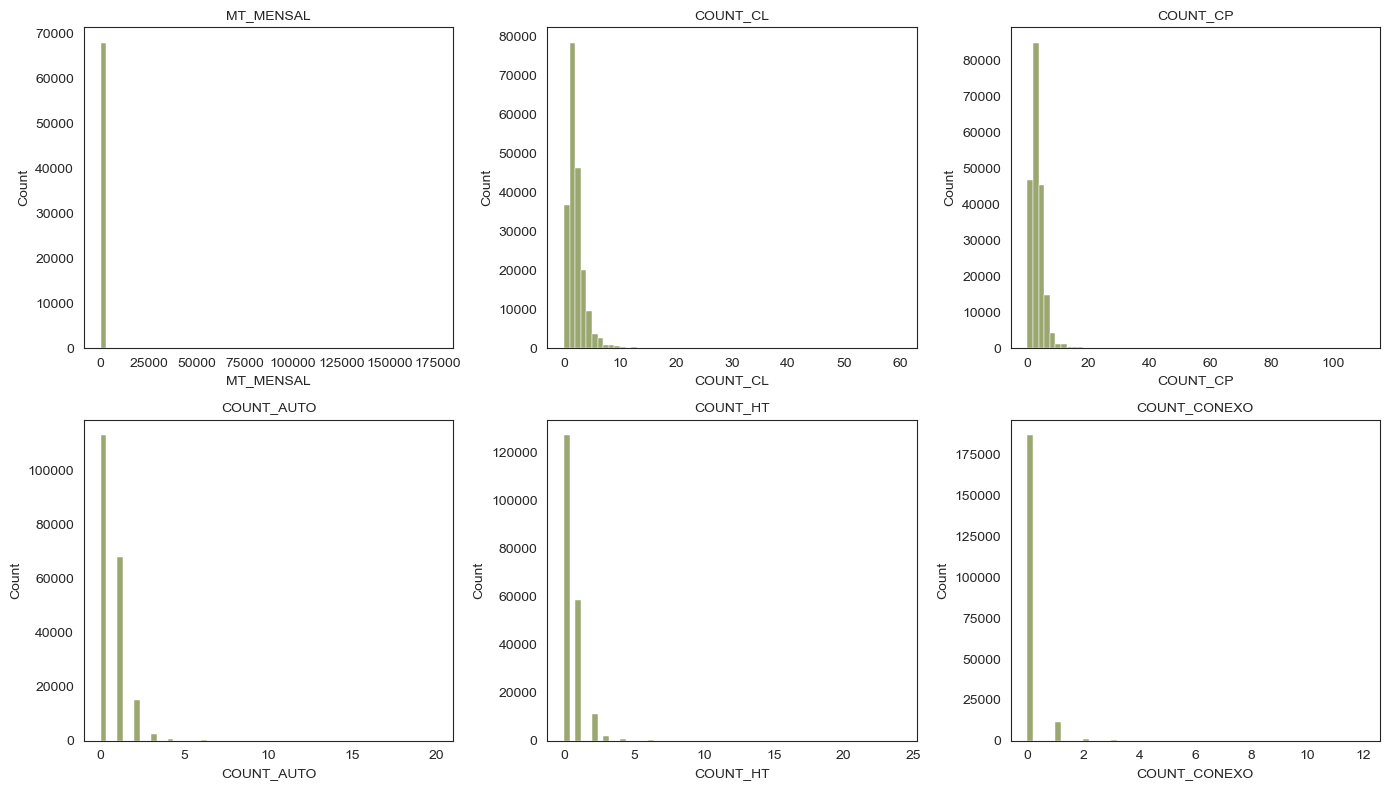

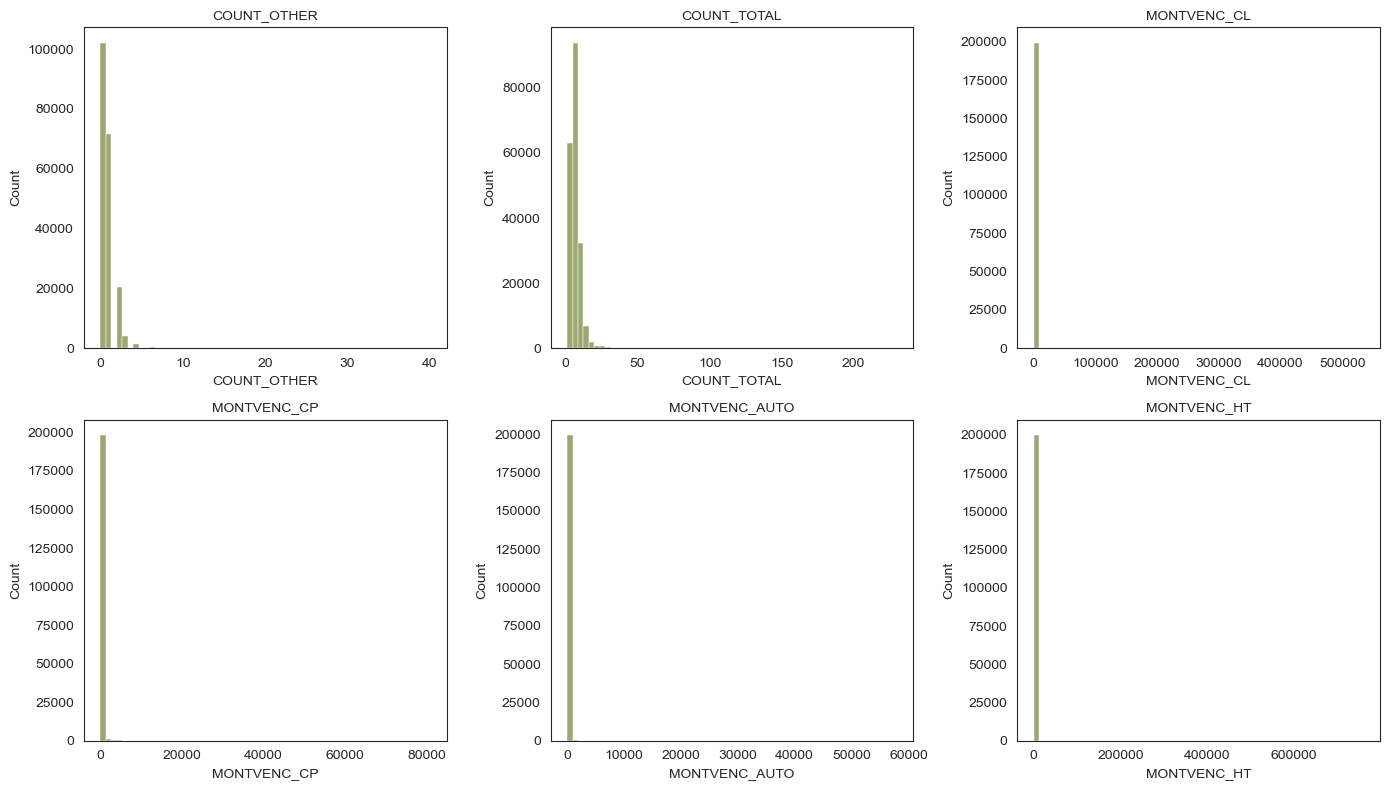

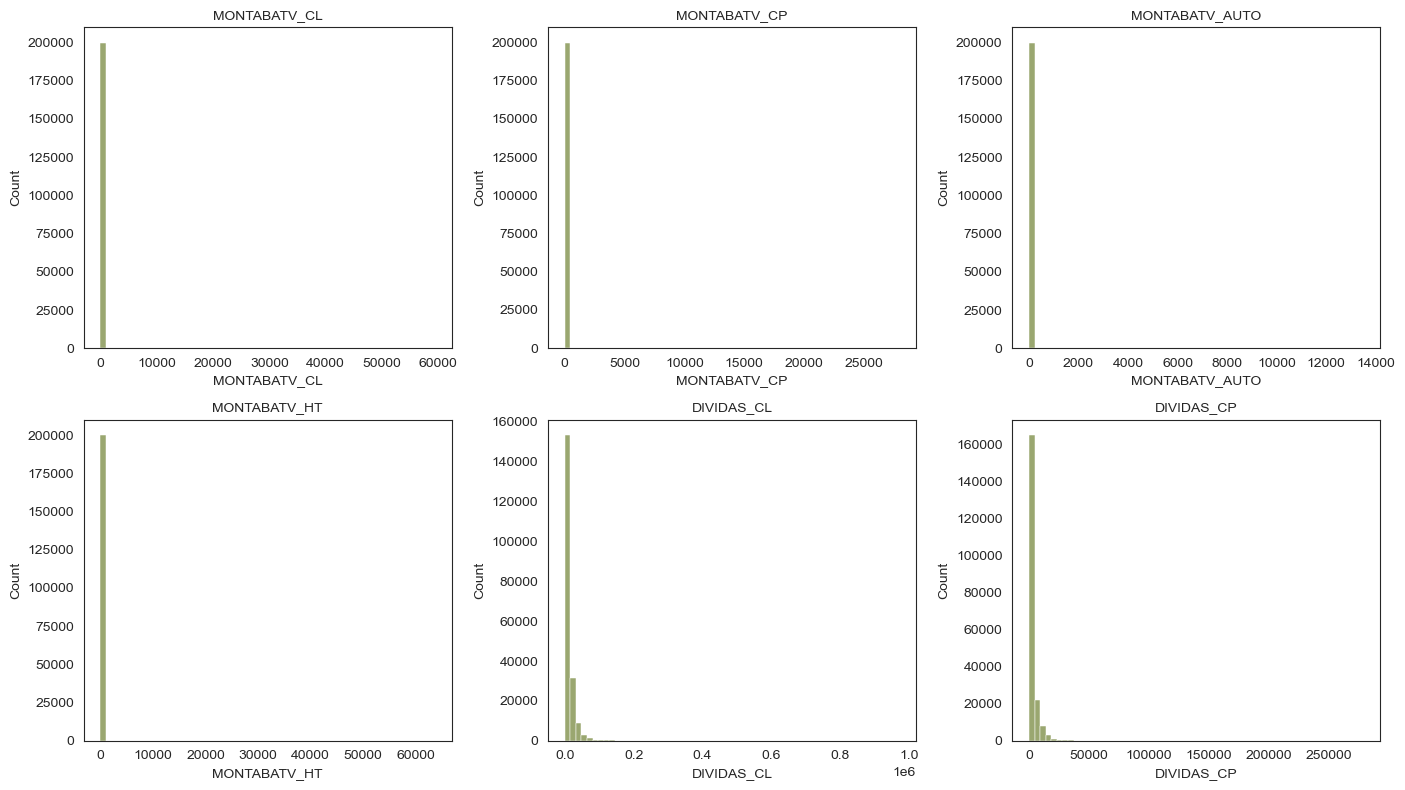

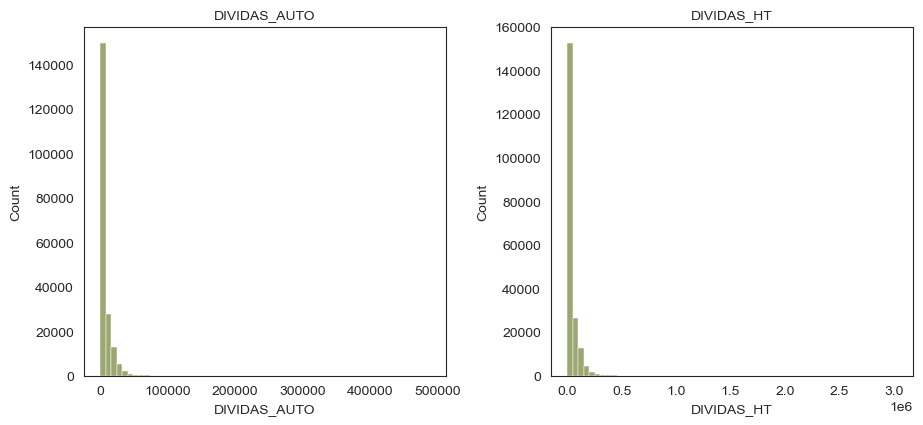

In [39]:
#setting visual style
sns.set_style("white")  # clean background for reports
#sampling the dataset
N = 200_000
sample = CRC.sample(n=min(N, len(CRC)), random_state=42)

#selecting numeric variables
cols = sample.select_dtypes(include=[np.number]).columns

#defining plotting structure
plots_per_fig = 6   
n_figs = ceil(len(cols) / plots_per_fig)

#looping through figures
for f in range(n_figs):
    
    #selecting subset of columns for current figure
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    #creating subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    #ploting histograms
    for ax, col in zip(axes, subset_cols):
        
        #removing missing values only 
        data = sample[col].dropna()
        
        sns.histplot(
            data,
            bins=60,
            kde=False,
            ax=ax,
            color="#798a40"   
        )
        
        ax.set_title(col, fontsize=10)

    #removing empty subplots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
        #adjusting layout and display
    plt.tight_layout()
    plt.show()

- Most variables are skewed to the left.

### 3.6. Checking Correlation between variables

In [40]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = CRC[metric_features].corr(method ='spearman')
cor_spearman

,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
MT_MENSAL,1.000000,0.395456,0.236308,0.231944,0.528161,0.272057,0.236045,0.558835,0.003648,-0.000568,0.016154,0.055819,-0.015057,-0.012127,-0.006622,-0.001455,0.533841,0.253331,0.266549,0.549654
COUNT_CL,0.395456,1.000000,0.204948,-0.183313,-0.006950,0.007571,0.086483,0.508537,0.166407,0.095022,0.025574,0.024357,0.022919,0.009356,-0.000684,0.000307,0.754133,0.321823,-0.153515,-0.014785
COUNT_CP,0.236308,0.204948,1.000000,-0.018989,0.130792,0.048963,0.223728,0.792283,-0.009487,0.065507,-0.021295,-0.004927,-0.006277,0.006749,-0.004314,-0.000484,0.197549,0.578446,-0.012727,0.122814
COUNT_AUTO,0.231944,-0.183313,-0.018989,1.000000,0.013875,0.015116,-0.035781,0.133008,-0.019078,-0.003135,0.136465,-0.001945,-0.001732,0.001956,0.011013,-0.003241,-0.231844,-0.033016,0.949972,0.016585
COUNT_HT,0.528161,-0.006950,0.130792,0.013875,1.000000,0.320383,0.221910,0.369609,-0.055014,-0.045006,-0.036792,0.113256,-0.009013,-0.011366,-0.005470,0.006431,0.014450,0.026859,0.011636,0.960529
COUNT_CONEXO,0.272057,0.007571,0.048963,0.015116,0.320383,1.000000,0.091806,0.195976,-0.018923,-0.018080,-0.010738,0.040709,-0.000477,-0.002240,-0.001672,-0.001178,0.017701,0.034912,0.012127,0.281941
COUNT_OTHER,0.236045,0.086483,0.223728,-0.035781,0.221910,0.091806,1.000000,0.464314,-0.006671,-0.008518,-0.019657,0.027521,-0.001341,0.000122,-0.001632,-0.001998,0.098743,0.129794,-0.035553,0.190432
COUNT_TOTAL,0.558835,0.508537,0.792283,0.133008,0.369609,0.195976,0.464314,1.000000,0.052153,0.069136,0.016794,0.041150,0.003689,0.006556,-0.001466,0.000327,0.398894,0.532123,0.133098,0.338988
MONTVENC_CL,0.003648,0.166407,-0.009487,-0.019078,-0.055014,-0.018923,-0.006671,0.052153,1.000000,0.464612,0.237175,0.113478,0.065208,0.077152,0.017712,0.007293,0.123688,0.078203,-0.017696,-0.055038
MONTVENC_CP,-0.000568,0.095022,0.065507,-0.003135,-0.045006,-0.018080,-0.008518,0.069136,0.464612,1.000000,0.230611,0.095578,0.050279,0.075669,0.011731,0.000846,0.074388,0.167852,-0.002428,-0.044053


In [41]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap=sns.light_palette("#798a40", as_cmap=True), #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

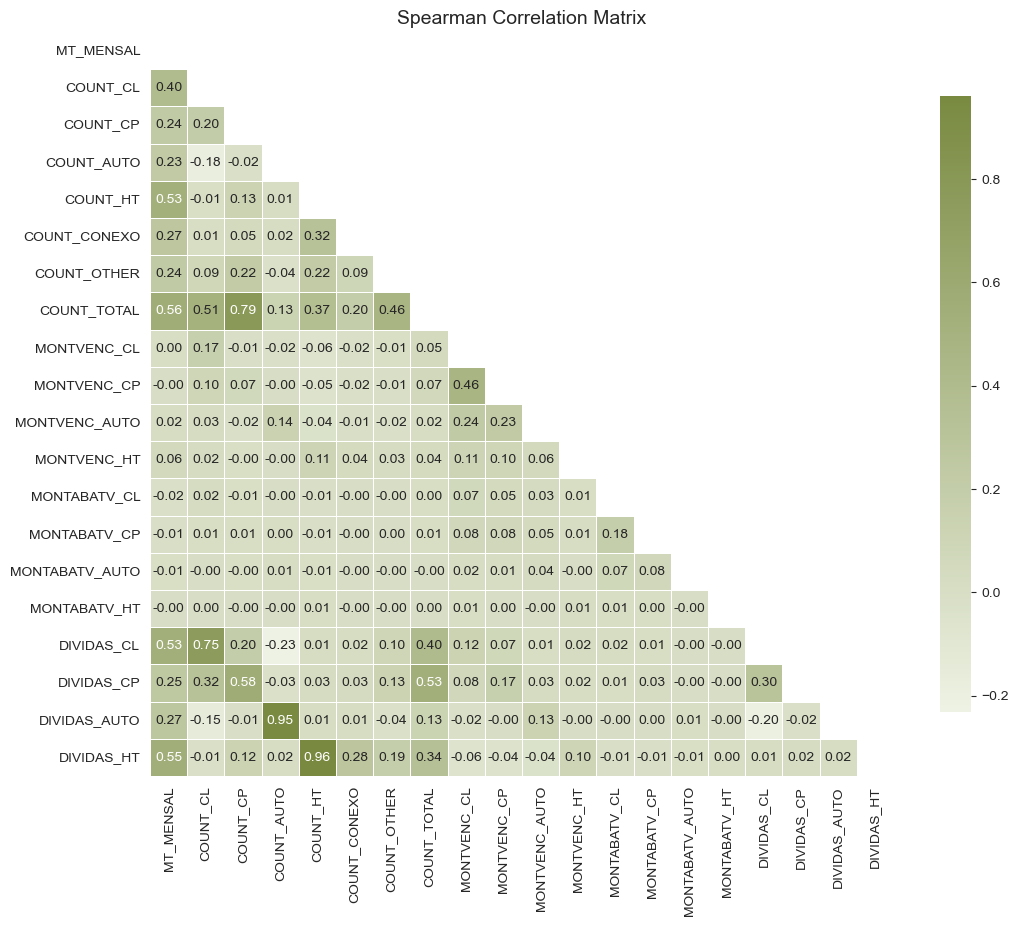

In [42]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

Redundant Features (considering >0.80):
- *DIVIDAS_AUTO* vs *COUNT_AUTO* (0.95)
- *DIVIDAS_HT* vs *COUNT_HT* (0.96)

### 3.7. Checking Incoherencies

In [43]:
#checking observations where 'COUNT_CL' > 'DIVIDAS_CL'
CRC[CRC['COUNT_CL'] > CRC['DIVIDAS_CL']]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
1191,02a3ed6dc4c0d578b0534978d2dba698c99e438f337347...,2023-12-31,0.00,1.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
1349,03014d8e554ac8d9087bdab1e42ef7f2664edbac02be24...,2023-12-31,NaN,1.0,1.0,1.0,1.0,0.0,0.0,4.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,865.93,20000.00,90349.71
2152,04ad29d772620c78099d7b966105ffd27d1f54bd456d06...,2023-12-31,NaN,2.0,5.0,0.0,2.0,0.0,1.0,10.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,993.72,0.00,86093.75
2211,04ca9ebb201a1512937d0e40004d63b704a029d0425de6...,2023-12-31,NaN,1.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,48181.97
2217,04cd1bc1a93cad7b0d1cd894f6fcad04f970491ba0f640...,2023-12-31,NaN,1.0,1.0,0.0,2.0,0.0,0.0,4.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,126336.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3030680,f7332c02ce93afd62f1ab27b6f996d1dbaf4bb5029af88...,2025-12-31,NaN,1.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
3031596,f92a8527efc8239592046a9e1f32048fc7f0eba2e228bd...,2025-12-31,1034.58,1.0,1.0,1.0,1.0,0.0,1.0,5.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,8145.64,185238.92
3031783,f9892e1d11c49cb06737bd097e00ceb75714a189fd7118...,2025-12-31,NaN,1.0,3.0,1.0,0.0,0.0,0.0,5.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,57.49,13993.69,0.00
3032328,faa3eacee6189959a5e129a3925816010c95332e60fff5...,2025-12-31,NaN,1.0,3.0,1.0,0.0,0.0,0.0,5.0,0.0,24.51,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1874.16,12318.54,0.00


In [44]:
#checking observations where 'COUNT_CP' > 'DIVIDAS_CP'
CRC[CRC['COUNT_CP'] > CRC['DIVIDAS_CP']]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
13,00090305c0bcef4a212c328717f904808c0ae3b520eff9...,2023-12-31,NaN,1.0,1.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5380.76,0.0,0.00,0.00
14,0009346ec91e4e678cf9300a19e768a8802390d528d5f0...,2023-12-31,NaN,1.0,1.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3726.30,0.0,0.00,78167.93
19,000a129438776dca90f4359642f343cb037d9afe60897f...,2023-12-31,NaN,2.0,1.0,0.0,0.0,0.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21233.45,0.0,0.00,0.00
31,0010e3d14c44e09d7939962038d87bcbfca2e0c1021778...,2023-12-31,NaN,0.0,3.0,1.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,16589.98,0.00
52,001d32c6f38c51e124300c6db05e5f3230c598d016ff4b...,2023-12-31,NaN,1.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25775.60,0.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3034892,fff437ed8b6c8eb46dee5ab5968d2abb4eabd769eac974...,2025-12-31,278.96,2.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3913.53,0.0,0.00,0.00
3034895,fff5ddd56beab05c4edf78f77f859205b3f8f3b6b23b91...,2025-12-31,NaN,2.0,1.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3626.39,0.0,0.00,0.00
3034898,fff6c6de3c9e5c3c6fa1cd6888e81a0cd3bcbead7a54e8...,2025-12-31,NaN,1.0,2.0,1.0,1.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.96,0.0,15852.65,197896.94
3034904,fff9b4ec881528770eb45d95f3d1fdc4918b353d27ced0...,2025-12-31,NaN,1.0,2.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4753.55,0.0,0.00,0.00


In [45]:
#checking observations where 'COUNT_TOTAL' is not the sum of all other 'COUNT'
CRC[
    CRC['COUNT_CL'] +
    CRC['COUNT_CP'] +
    CRC['COUNT_AUTO'] +
    CRC['COUNT_HT'] +
    CRC['COUNT_CONEXO'] +
    CRC['COUNT_OTHER']
    != CRC['COUNT_TOTAL']
]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
16677,246028aa732dccdcbb4a59d0de5bf2195154a87c93349f...,2023-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36377,4e8dd38f4bf02f0ec56a3901a8bb0890f54bd6bd92a67b...,2023-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75904,a3aecd3b649fce86a1337dcb3f23a1dfa03a21dae0a46f...,2023-12-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81305,af6c29c28d7de808d1f86e00b6a279ed9c5cc3119dc8c0...,2023-12-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87441,bc6a1a24545459c49741c0a3e21a7f0707b59a008902c2...,2023-12-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2764798,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2025-10-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2881432,bc6a1a24545459c49741c0a3e21a7f0707b59a008902c2...,2025-11-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2886934,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2025-11-30,394.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3002785,bc6a1a24545459c49741c0a3e21a7f0707b59a008902c2...,2025-12-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Preparation

### 4.1. Changing Datatypes

In [46]:
#Changing Datatypes
CRC['COUNT_CL'] = CRC['COUNT_CL'].round().astype('Int32')
CRC['COUNT_CP'] = CRC['COUNT_CP'].round().astype('Int32')
CRC['COUNT_AUTO'] = CRC['COUNT_AUTO'].round().astype('Int32')
CRC['COUNT_HT'] = CRC['COUNT_HT'].round().astype('Int32')
CRC['COUNT_CONEXO'] = CRC['COUNT_CONEXO'].round().astype('Int32')
CRC['COUNT_OTHER'] = CRC['COUNT_OTHER'].round().astype('Int32')
CRC['COUNT_TOTAL'] = CRC['COUNT_TOTAL'].round().astype('Int32')

### 4.2. Handling Missing Values

In [47]:
#handling missing values of 172 rows
CRC = CRC.dropna(subset=['COUNT_CL'])

In [48]:
#droping MT_MENSAL due to its elevated number of missing values
CRC = CRC.drop(columns=['MT_MENSAL'])

In [49]:
#checking number of missing values
CRC.isna().sum()

CONTRIB           0
OBS_DATE          0
COUNT_CL          0
COUNT_CP          0
COUNT_AUTO        0
COUNT_HT          0
COUNT_CONEXO      0
COUNT_OTHER       0
COUNT_TOTAL       0
MONTVENC_CL       0
MONTVENC_CP       0
MONTVENC_AUTO     0
MONTVENC_HT       0
MONTABATV_CL      0
MONTABATV_CP      0
MONTABATV_AUTO    0
MONTABATV_HT      0
DIVIDAS_CL        0
DIVIDAS_CP        0
DIVIDAS_AUTO      0
DIVIDAS_HT        0
dtype: int64

### 4.3. Handling Outliers

In [50]:
#setting a maximum number for each variable that needs outliers treated
CRC['COUNT_CL'] = CRC['COUNT_CL'].clip(upper=50)
CRC['COUNT_CP'] = CRC['COUNT_CP'].clip(upper=100)
CRC['COUNT_AUTO'] = CRC['COUNT_AUTO'].clip(upper=15)
CRC['COUNT_HT'] = CRC['COUNT_HT'].clip(upper=20)
CRC['COUNT_CONEXO'] = CRC['COUNT_CONEXO'].clip(upper=10)
CRC['COUNT_OTHER'] = CRC['COUNT_OTHER'].clip(upper=30)
CRC['MONTVENC_CL'] = CRC['MONTVENC_CL'].clip(upper=300000)
CRC['MONTVENC_CP'] = CRC['MONTVENC_CP'].clip(upper=60000)
CRC['MONTVENC_AUTO'] = CRC['MONTVENC_AUTO'].clip(upper=70000)
CRC['MONTVENC_HT'] = CRC['MONTVENC_HT'].clip(upper=400000)
CRC['MONTABATV_CL'] = CRC['MONTABATV_CL'].clip(upper=50000)
CRC['MONTABATV_CP'] = CRC['MONTABATV_CP'].clip(upper=30000)
CRC['MONTABATV_AUTO'] = CRC['MONTABATV_AUTO'].clip(upper=10000)
CRC['MONTABATV_HT'] = CRC['MONTABATV_HT'].clip(upper=100000)
CRC['DIVIDAS_CL'] = CRC['DIVIDAS_CL'].clip(upper=1000000)
CRC['DIVIDAS_CP'] = CRC['DIVIDAS_CP'].clip(upper=200000)
CRC['DIVIDAS_AUTO'] = CRC['DIVIDAS_AUTO'].clip(upper=300000)
CRC['DIVIDAS_HT'] = CRC['DIVIDAS_HT'].clip(upper=300000)

In [51]:
#checking if 'COUNT_TOTAL' is well calculated after handling outliers
CRC[
    CRC['COUNT_CL'] +
    CRC['COUNT_CP'] +
    CRC['COUNT_AUTO'] +
    CRC['COUNT_HT'] +
    CRC['COUNT_CONEXO'] +
    CRC['COUNT_OTHER']
    != CRC['COUNT_TOTAL']
]

,CONTRIB,OBS_DATE,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
7732,10d819a5d3374566b01cc287e212bfd30ccabb911bacf7...,2023-12-31,0,15,3,20,0,9,57,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,16445.31,53071.71,300000.00
89652,c1084cf8628c8ad5352c03c4a8d903621dcaca9b4b7b61...,2023-12-31,8,16,15,0,0,0,40,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,83601.36,119.92,68089.52,0.00
152211,47639645b5408e171d103a50a4eae026ba4b4c8b8c822f...,2024-01-31,16,48,15,8,0,0,88,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,290330.80,24698.32,135622.16,300000.00
185404,8ee439f9fe287cda494b1cc50c8d7b955df2552b2eeb65...,2024-01-31,24,24,15,8,8,24,104,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,165744.48,2816.40,177547.52,124740.24
193078,9f3454d721886d7629fe2c0ad169579d79e7cd10e54675...,2024-01-31,0,24,15,8,0,8,56,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,1455.92,96033.76,300000.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2820550,3c9a565cadf56ff1554623a9273255fc546d96b2687dd7...,2025-11-30,16,0,15,0,0,4,36,323.88,0.00,4838.36,0.0,0.0,0.0,0.0,0.0,166320.04,0.00,175980.52,0.00
2859534,8ee439f9fe287cda494b1cc50c8d7b955df2552b2eeb65...,2025-11-30,24,16,15,8,8,24,96,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,114909.60,2672.96,194108.00,106210.88
2946646,45e07fa5cc2621083b672ed204306b9a99e52e41698a6e...,2025-12-31,50,100,10,10,0,20,200,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,925475.50,200000.00,47171.10,300000.00
3011933,cfa7e105c17b77302c2753081d0517ac9a602dfd4edbb5...,2025-12-31,2,10,15,0,0,2,30,352.10,3940.36,18573.56,0.0,0.0,0.0,0.0,0.0,9885.00,31044.22,300000.00,0.00


In [52]:
components = [
    'COUNT_CL',
    'COUNT_CP',
    'COUNT_AUTO',
    'COUNT_HT',
    'COUNT_CONEXO',
    'COUNT_OTHER'
]

# Calculate the correct sum
component_sum = CRC[components].sum(axis=1)

# Replace COUNT_TOTAL only where it is different
CRC.loc[CRC['COUNT_TOTAL'] != component_sum, 'COUNT_TOTAL'] = component_sum

### 4.4. Feature Engineering

In [53]:
#creating 'SUBCOUNT_TOTAL'
CRC['SUBCOUNT_TOTAL'] = CRC[
    ['COUNT_CL','COUNT_CP','COUNT_AUTO','COUNT_HT']
].sum(axis=1)

In [54]:
#creating 'MONTVENC_TOTAL'
CRC['MONTVENC_TOTAL'] = CRC[
    ['MONTVENC_CL','MONTVENC_CP','MONTVENC_AUTO','MONTVENC_HT']
].sum(axis=1)

In [55]:
#creating 'MONTABATV_TOTAL'
CRC['MONTABATV_TOTAL'] = CRC[
    ['MONTABATV_CL','MONTABATV_CP','MONTABATV_AUTO','MONTABATV_HT']
].sum(axis=1)

In [56]:
#creating 'DIVIDAS_TOTAL'
CRC['DIVIDAS_TOTAL'] = CRC[
    ['DIVIDAS_CL','DIVIDAS_CP','DIVIDAS_AUTO','DIVIDAS_HT']
].sum(axis=1)

In [57]:
pd.set_option('display.max_columns', None)
CRC = CRC.sort_values(['CONTRIB', 'OBS_DATE'])
CRC.tail(30)

,CONTRIB,OBS_DATE,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT,SUBCOUNT_TOTAL,MONTVENC_TOTAL,MONTABATV_TOTAL,DIVIDAS_TOTAL
717013,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-05-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17345.04,3320.12,0.00,0.0,3,0.00,0.0,20665.16
837416,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-06-30,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17512.16,3244.15,0.00,0.0,3,0.00,0.0,20756.31
957819,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-07-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17512.16,3244.15,0.00,0.0,3,0.00,0.0,20756.31
1078222,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-08-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17512.16,3244.15,0.00,0.0,3,0.00,0.0,20756.31
1199420,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-09-30,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17218.32,3011.78,0.00,0.0,3,0.00,0.0,20230.10
1320617,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-10-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17218.32,3011.78,0.00,0.0,3,0.00,0.0,20230.10
1442298,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-11-30,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17143.40,3272.10,0.00,0.0,3,0.00,0.0,20415.50
1564571,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2024-12-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,17067.34,3158.29,0.00,0.0,3,0.00,0.0,20225.63
1686627,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2025-01-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,16991.81,2885.36,0.00,0.0,3,0.00,0.0,19877.17
1809009,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2025-02-28,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,16914.79,2949.03,0.00,0.0,3,0.00,0.0,19863.82


### 4.5. Data Aggregation

In [58]:
#defining a function to calculate the mode
def moda(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan

In [59]:
#aggregating CRC's variables we consider relevant
CRC_agg = (
    CRC
    .groupby("CONTRIB", as_index=True)
    .agg(
        count_cl_mean=("COUNT_CL", "mean"),
        montvenc_cl_mean= ("MONTVENC_CL", "mean"),
        montabatv_cl_mean= ("MONTABATV_CL", "mean"),
        dividas_cl_mean=("DIVIDAS_CL", "mean"),
        subcount_total_mean=("SUBCOUNT_TOTAL", "mean"),
        montenc_total_mean=("MONTVENC_TOTAL", "mean"),
        montabatv_total_mean=("MONTABATV_TOTAL", "mean"),
        dividas_total_mean=("DIVIDAS_TOTAL", "mean") 
              
    )
)

In [60]:
#creating 'HIGH_RISK_CURRENT'after aggregation
CRC_agg['HIGH_RISK_CURRENT'] = (
    (CRC_agg['montenc_total_mean'] > 0) | 
    (CRC_agg['montabatv_total_mean'] > 0)
).astype(int)

In [61]:
#chacking how many clients are considered high risk
CRC_agg[CRC_agg['HIGH_RISK_CURRENT'] == 1].count()

count_cl_mean           32098
montvenc_cl_mean        32098
montabatv_cl_mean       32098
dividas_cl_mean         32098
subcount_total_mean     32098
montenc_total_mean      32098
montabatv_total_mean    32098
dividas_total_mean      32098
HIGH_RISK_CURRENT       32098
dtype: int64

In [62]:
#checking umber of missing values in each column as a percentage after aggregation
CRC_agg.isna().sum()/len(CRC_agg) * 100

count_cl_mean           0.0
montvenc_cl_mean        0.0
montabatv_cl_mean       0.0
dividas_cl_mean         0.0
subcount_total_mean     0.0
montenc_total_mean      0.0
montabatv_total_mean    0.0
dividas_total_mean      0.0
HIGH_RISK_CURRENT       0.0
dtype: float64

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# CREDSCORE Dataset
       
</div>

**METADATA**:
- *sys_numero_submissao*: Submission number. 
- *sys_data_procura*: Date of risk probing.
- *kp_sqe*: Risk score of known customers based on behavior: A-X, A is better, null= unknown.
- *ks_score_tier*: risk score for granting (all customers) lower is better.

## 3. Data exploration and understanding

### 3.1. Data Overview

In [63]:
#overview the dataset
CREDSCORE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63704 entries, 0 to 63703
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CONTRIB               63704 non-null  object        
 1   sys_numero_submissao  63704 non-null  float64       
 2   sys_data_procura      63704 non-null  datetime64[ns]
 3   kp_sqe                45653 non-null  object        
 4   ks_score_tier         63704 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 2.4+ MB


In [64]:
#first 20 rows
CREDSCORE.head(20)

,CONTRIB,sys_numero_submissao,sys_data_procura,kp_sqe,ks_score_tier
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,22.0,2025-02-05,H,2.0
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,4.0,2025-04-09,D,1.0
2,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,1.0,2023-08-08,F,3.0
3,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6...,4.0,2023-09-11,A,1.0
4,0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a9...,15.0,2025-08-14,H,1.0
5,000607d1adce7aa9ac87274d1a2ffa84e240188de0872f...,2.0,2023-08-03,A,1.0
6,00074b200f6c11a8731d6da396546e8d2e7be5621c931b...,1.0,2024-02-28,W,1.0
7,000785e8aca11cecd0db680ef13a751aa97ccf322d0333...,6.0,2023-04-02,C,1.0
8,000803da8192598bfa2bbd780df6da11b3fe54ff332748...,7.0,2024-03-19,None,1.0
9,0008972f591b1158d65ebfff2618796f4801f56d0f24a9...,4.0,2025-06-02,C,1.0


In [65]:
#last 20 rows
CREDSCORE.tail(20)

,CONTRIB,sys_numero_submissao,sys_data_procura,kp_sqe,ks_score_tier
63684,fff18028fa9ebf368d380d1479d52ad3b33b80574041fb...,10.0,2024-04-18,F,4.0
63685,fff1d927bb2944ee8f4dc3f03b656f7fcb087ae1067276...,0.0,2024-08-26,None,3.0
63686,fff1f40e1b55438136afc245cb65ffb282d014131db5bd...,1.0,2025-04-11,None,5.0
63687,fff23dbcd0dadd138dfef23c328f1c1029df12dbbf4e49...,6.0,2024-04-05,None,1.0
63688,fff273429dc2fbf20303c710116f4a32e9f11bec8bdb1c...,7.0,2024-12-01,None,1.0
63689,fff401035189b742da3b159c46068039e3e1a690fa6b3f...,9.0,2024-10-04,None,3.0
63690,fff56d30ec9a1e58be6d34c56c398db0782b4351cb26bd...,11.0,2023-07-13,None,1.0
63691,fff56fee584eb19fac469a7b1b58a275abf4622411c14b...,8.0,2023-11-07,D,1.0
63692,fff609096cf494f778d94319540d0c03e299be965198f3...,3.0,2023-11-22,None,2.0
63693,fff6c6de3c9e5c3c6fa1cd6888e81a0cd3bcbead7a54e8...,11.0,2025-01-11,None,1.0


In [66]:
#descriptive statistics for numerical data
CREDSCORE.describe().round(2)

,sys_numero_submissao,sys_data_procura,ks_score_tier
count,63704.00,63704,63704.00
mean,5.86,2024-08-26 19:30:49.503955968,1.59
min,0.00,2020-08-12 00:00:00,1.00
25%,3.00,2023-12-07 00:00:00,1.00
50%,5.00,2024-10-10 00:00:00,1.00
75%,8.00,2025-06-05 00:00:00,2.00
max,62.00,2025-12-15 00:00:00,5.00
std,4.19,NaN,0.84


In [67]:
#descriptive statistics for categorical data
CREDSCORE.describe(include = ['O'])

,CONTRIB,kp_sqe
count,63704,45653
unique,62173,15
top,0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9...,A
freq,20,6977


In [68]:
#how many clients exists for each classification (Alphabetical order)
CREDSCORE['kp_sqe'] \
    .value_counts(dropna=False) \
    .sort_index()

kp_sqe
A        6977
B        5404
C        4205
D        4638
E        6300
F        6085
G        3386
H        4788
I        1476
J         665
K         499
M         155
U         600
V         128
W         347
None    18051
Name: count, dtype: int64

- We can see the most common classification is 'A' which is a good indicator, and there is no client with classification 'X' (the worst)
- We should see what classification is considered risky

In [69]:
#checking nº of observations in ks_score_tier by number
CREDSCORE['ks_score_tier'].value_counts(dropna=False)

ks_score_tier
1.0    39117
2.0    12670
3.0    10961
4.0      633
5.0      323
Name: count, dtype: int64

- The most common one is 1, which is also a good indicator.

### 3.2. Checking Duplicates

In [70]:
#checking number of duplicates
CREDSCORE.duplicated().sum()

np.int64(831)

In [71]:
#checking if for each client we have more than one date
dups = CREDSCORE[CREDSCORE.duplicated(subset=["CONTRIB"], keep=False)].sort_values("CONTRIB")
display(dups.head(20))

,CONTRIB,sys_numero_submissao,sys_data_procura,kp_sqe,ks_score_tier
47,0026b5f0de9828ec21d97c586dc791fb0671a0224617d1...,1.0,2024-03-20,H,2.0
48,0026b5f0de9828ec21d97c586dc791fb0671a0224617d1...,1.0,2024-03-20,H,1.0
202,00c37349b39ab60123c5f27d2a6dbed7491c55650506d6...,1.0,2023-09-12,D,3.0
203,00c37349b39ab60123c5f27d2a6dbed7491c55650506d6...,1.0,2023-09-12,D,2.0
249,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,1.0,2023-06-15,U,3.0
250,00f7e9f67656f7f492faef74c1452f49148c0969f54e35...,1.0,2023-06-15,U,3.0
263,01075c43c0ff8ec7ff76ffe65db4231a528099497f5d7d...,1.0,2025-08-19,None,5.0
264,01075c43c0ff8ec7ff76ffe65db4231a528099497f5d7d...,1.0,2025-08-19,None,2.0
341,01528f21434f34c7976541dca95691cea0b4778577c537...,1.0,2024-07-04,None,4.0
342,01528f21434f34c7976541dca95691cea0b4778577c537...,1.0,2024-07-04,None,2.0


In [72]:
#sort observations by 'CONTRIB'
CREDSCORE = CREDSCORE.sort_values(['CONTRIB'])

### 3.3. Checking Incoherencies

In [73]:
print("shape:", CREDSCORE.shape)
print("unique clients:", CREDSCORE['CONTRIB'].nunique())
print("duplicates per client:", CREDSCORE.duplicated(subset=['CONTRIB']).sum())

shape: (63704, 5)
unique clients: 62173
duplicates per client: 1531


In [74]:
CREDSCORE['sys_data_procura'] = pd.to_datetime(CREDSCORE['sys_data_procura'], errors='coerce')

# número de datas diferentes por cliente
dates_per_client = CREDSCORE.groupby('CONTRIB')['sys_data_procura'].nunique()

print("Clients with >1 date:", (dates_per_client > 1).sum())

Clients with >1 date: 106


- There are 106 clients that have more than 1 date, which is not possible because in this dataset we are only considering the date of client's last credit proposal.

### 3.4. Checking Missing Values

In [75]:
#replacing the observation where it appears 'NULL' and 'NONE' and replace for missing values
CREDSCORE['kp_sqe'] = CREDSCORE['kp_sqe'].astype(str).str.strip().str.upper()
CREDSCORE['kp_sqe'] = CREDSCORE['kp_sqe'].replace({'NULL': np.nan, 'NONE': np.nan})

In [76]:
#checking umber of missing values in each column as a percentage
CREDSCORE.isna().sum()/len(CREDSCORE) * 100

CONTRIB                  0.00000
sys_numero_submissao     0.00000
sys_data_procura         0.00000
kp_sqe                  28.33574
ks_score_tier            0.00000
dtype: float64

In [77]:
#checking number of missing values
CREDSCORE.isna().sum()

CONTRIB                     0
sys_numero_submissao        0
sys_data_procura            0
kp_sqe                  18051
ks_score_tier               0
dtype: int64

- These missing values correspond to unknown clients.

### 3.5. Checking Outliers

In [78]:
#defining metric features
metric_features= ['ks_score_tier']

In [79]:
def plot_boxplot(data, feat='ks_score_tier', title="Box Plot"):
    #setting visual style
    sns.set_style("white") 

    #keeping ALL values except missing ones
    values = data[feat].dropna()
    plt.figure(figsize=(6, 4.5))
    
    #plotting boxplot
    if len(values) > 0:
        sns.boxplot(
            x=values,
            color="#798a40",  
            linewidth=1.2
        )
        plt.title(feat, fontsize=10)
    else:
        plt.title(f"{feat} (no data)", fontsize=10)

    #final layout
    plt.suptitle(title, fontsize=16)

    #removing unnecessary borders 
    sns.despine(left=True)

    plt.tight_layout()
    plt.show()

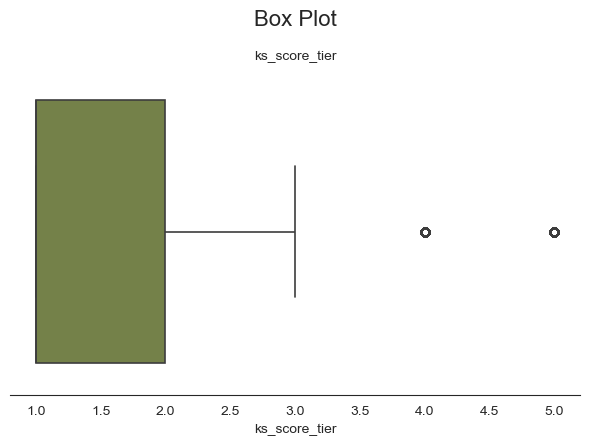

In [80]:
#applying the function to our numerical features
plot_boxplot(CREDSCORE)

In [81]:
#checking nº of observations where 'ks_score_tier'> 4
CREDSCORE[CREDSCORE['ks_score_tier'] > 4].count()

CONTRIB                 323
sys_numero_submissao    323
sys_data_procura        323
kp_sqe                    9
ks_score_tier           323
dtype: int64

### 3.6. Checking Distribution

#### 3.6.1. Numerical Variable

In [82]:
#defining a data frame
df= pd.DataFrame(CREDSCORE[metric_features])

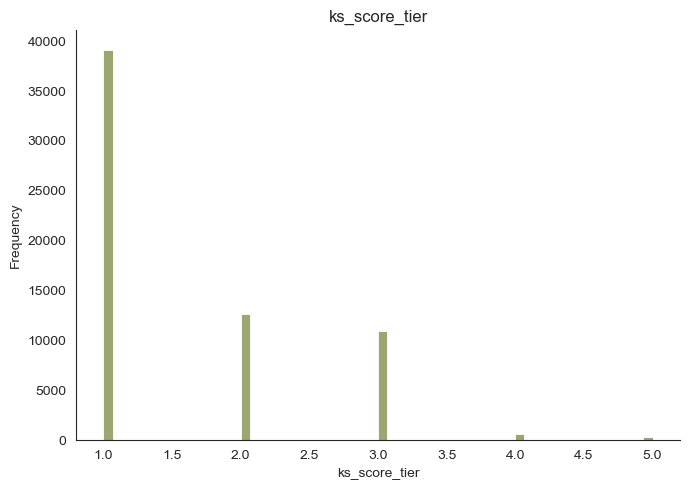

In [83]:
#setting visual style
sns.set_style("white") 

#sampling up to 200k observations for performance
N = min(200_000, len(CREDSCORE))
sample = CREDSCORE.sample(n=N, random_state=42)

#selecting variables to plot
col = metric_features[0]  
fig, ax = plt.subplots(figsize=(7, 5))

#ploting histogram
#keeping all values except missing ones
data = sample[col].dropna()

sns.histplot(
    data,
    bins=60,
    kde=False,
    ax=ax,
    color="#798a40"   
)

ax.set_title(col, fontsize=12)
ax.set_ylabel("Frequency")
sns.despine()
plt.tight_layout()
plt.show()

#### 3.6.2. Categorical Variable

C:\Users\alano\AppData\Local\Temp\ipykernel_16168\865861358.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


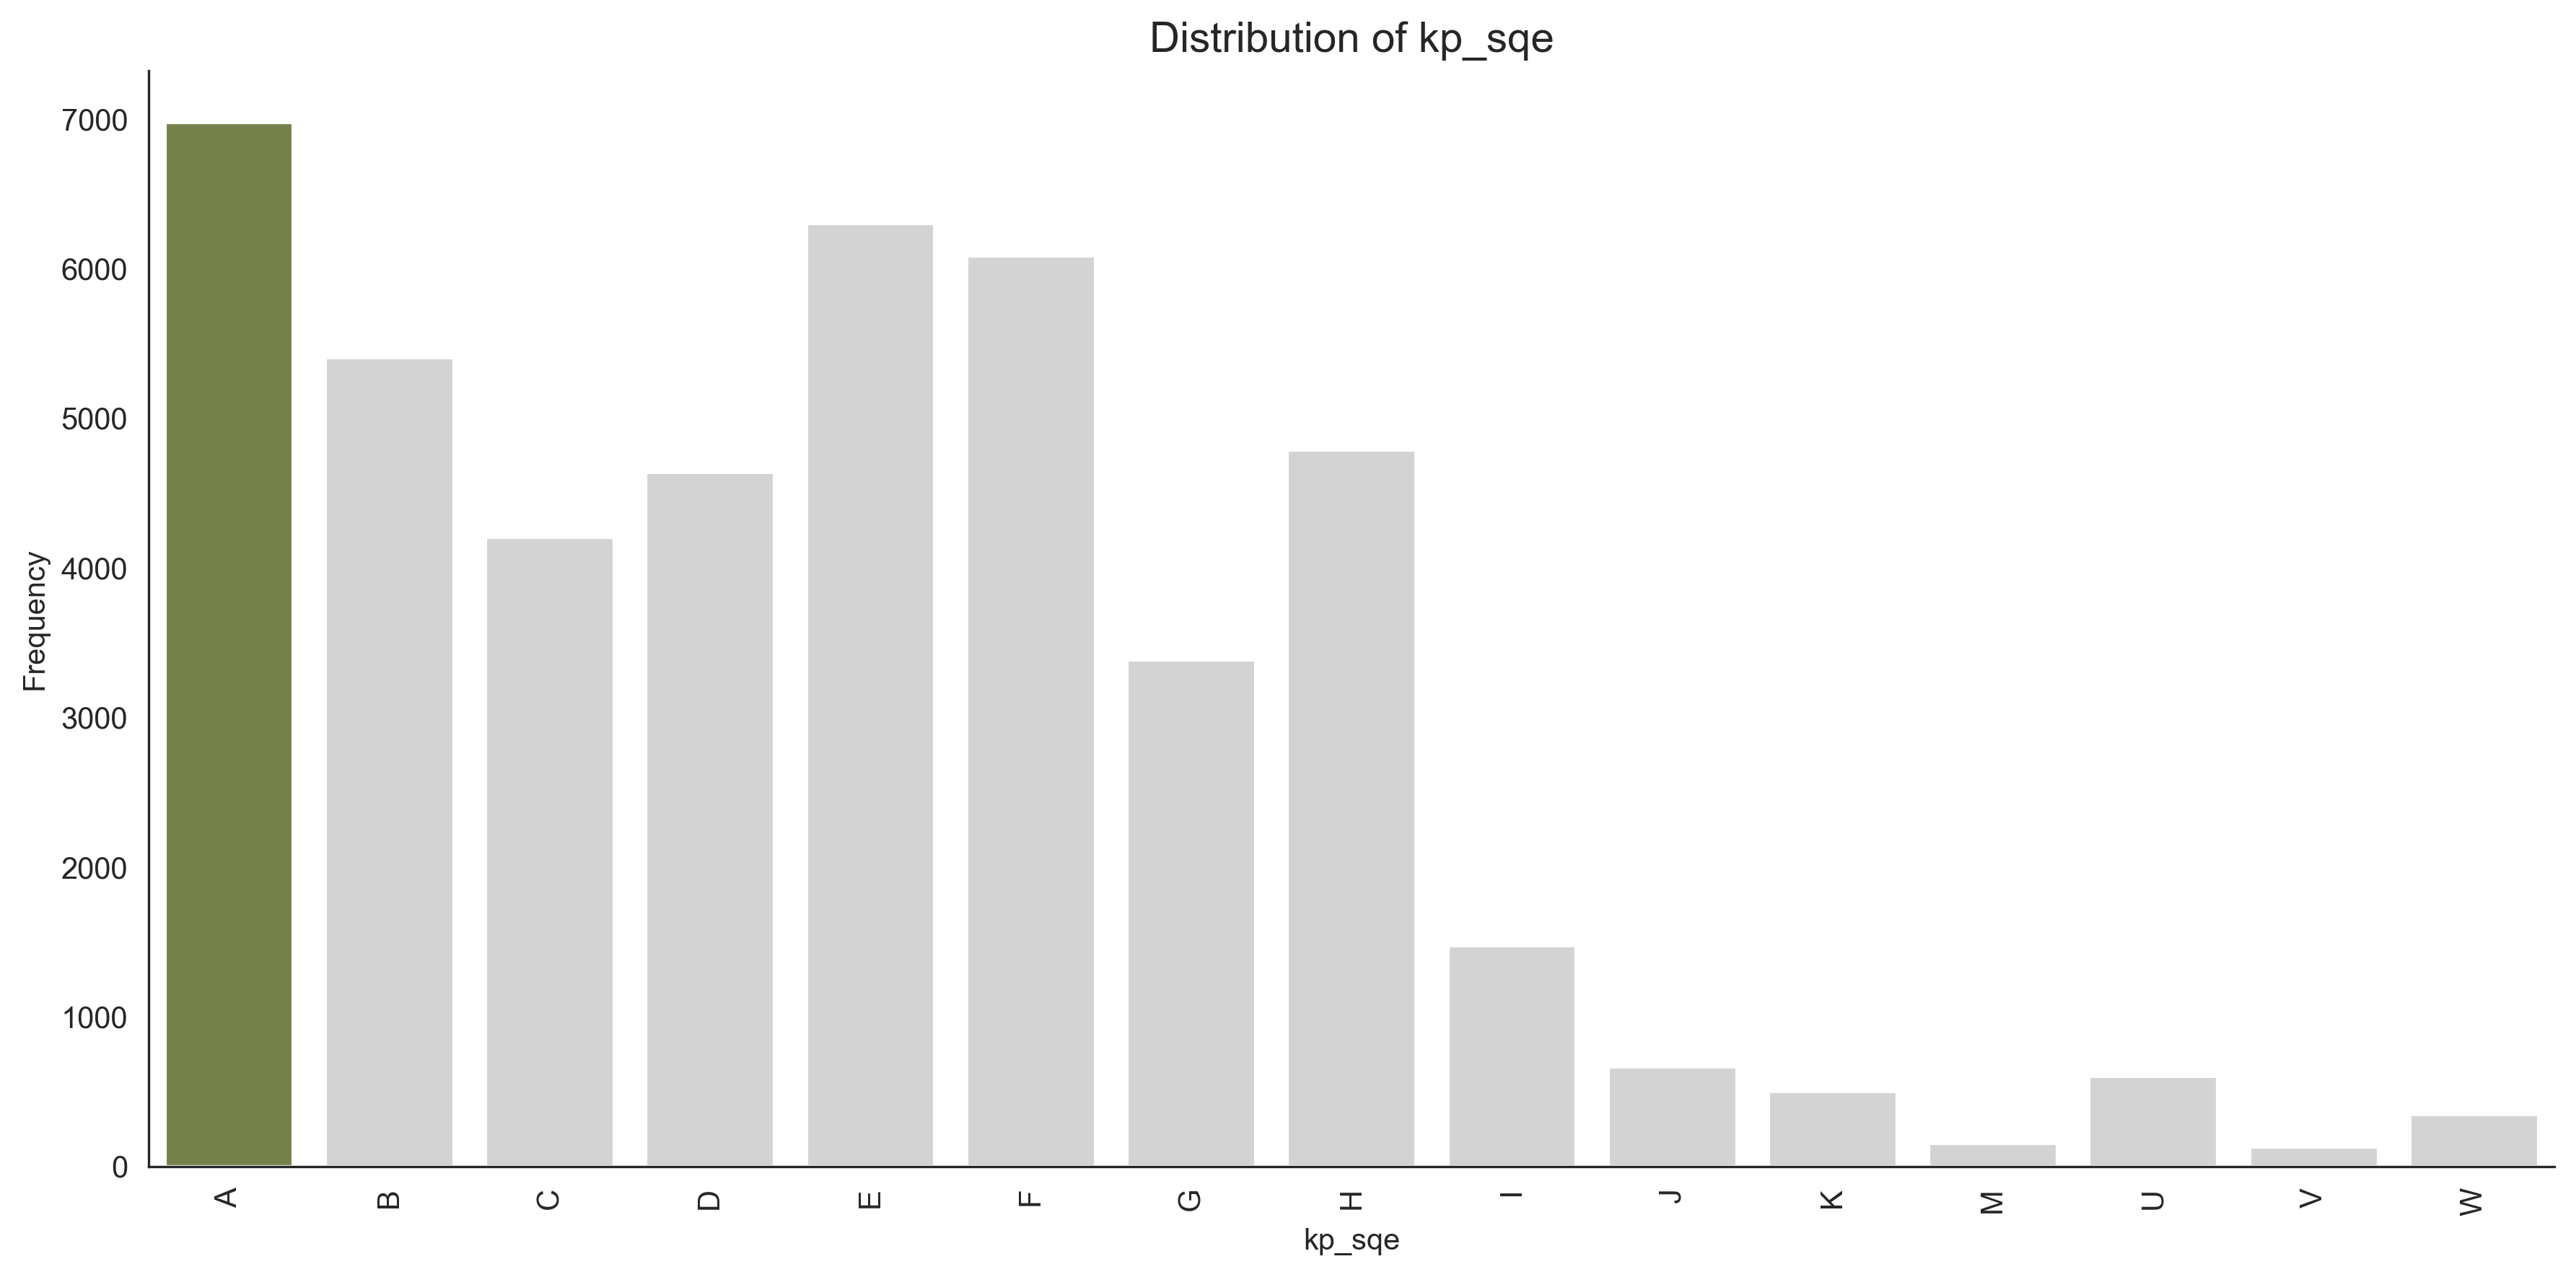

In [84]:
def plot_categorical_highlight(data, column, highlight_color="#798a40", default_color="lightgray"):

    #counting observations per category
    counts = data[column].value_counts().sort_index()

    #finding category with highest observations
    max_category = counts.idxmax()
    palette = [highlight_color if cat == max_category else default_color for cat in counts.index]

    #setting style and figure
    sns.set_style("white")
    plt.figure(dpi=300, figsize=(12,6))
    plt.gcf().patch.set_facecolor('white')  # background

    #ploting bar chart
    sns.barplot(
        x=counts.index,
        y=counts.values,
        palette=palette
    )

    plt.xticks(rotation=90)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}", fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.show()

# -----------------------------
# Example usage
# -----------------------------
plot_categorical_highlight(CREDSCORE, "kp_sqe")


## 4. Data Preparation

### 4.1. Changing Datatypes

In [85]:
#Changing datatypes
CREDSCORE['ks_score_tier'] = CREDSCORE['ks_score_tier'].round().astype('Int32')

### 4.2. Handling Incoherencies

In [86]:
#soring values by 'CONTRIB' and 'sys_data_procura' and only date for each client
CREDSCORE = CREDSCORE.sort_values(['CONTRIB','sys_data_procura'])
CREDSCORE = CREDSCORE.groupby('CONTRIB', as_index=False).tail(1)

In [87]:
#removing unnecessary columns
CREDSCORE = CREDSCORE.drop(columns=['sys_numero_submissao','sys_data_procura'], errors='ignore')

In [88]:
CREDSCORE.groupby(CREDSCORE['kp_sqe'].isna())['ks_score_tier'].describe()

,count,mean,std,min,25%,50%,75%,max
kp_sqe,,,,,,,,
False,44389.0,1.463944,0.738791,1.0,1.0,1.0,2.0,5.0
True,17784.0,1.844861,0.94191,1.0,1.0,2.0,3.0,5.0


### 3.3. Removing Duplicates

In [89]:
#droping duplicate rows 
CREDSCORE = CREDSCORE.drop_duplicates()

In [90]:
for col in CREDSCORE.columns:
    print(f"'{col}'")

'CONTRIB'
'kp_sqe'
'ks_score_tier'


### 3.4. Handling Missing Values

In [91]:
#filling missing values
CREDSCORE['kp_sqe'] = CREDSCORE['kp_sqe'].fillna('Unknown')

### 3.5. Feature Engineering

In [92]:
#creating is_risky 
CREDSCORE['is_risky'] = (
    (CREDSCORE['kp_sqe'] > 'D') |
    (CREDSCORE['ks_score_tier'] > 2)
)

In [93]:
CREDSCORE['is_risky'].value_counts(dropna=False)

is_risky
True     42302
False    19871
Name: count, dtype: Int64

In [94]:
CREDSCORE['is_risky'] = CREDSCORE['is_risky'].astype(int)

In [95]:
CREDSCORE.head()

,CONTRIB,kp_sqe,ks_score_tier,is_risky
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,H,2,1
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,D,1,0
2,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,F,3,1
3,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6...,A,1,0
4,0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a9...,H,1,1


<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# FAMA Dataset
       
</div>

**METADATA**
- *Date_Obs*: Observation Date (MMYY).
- *ALLBD_N_Dossiers__N*: Distinct count of Dossiers.
- *ALLBD_N_CL__N*: Distinct count of Dossiers for CL.
- *ALLBD_N_CP__N*: Distinct count of Dossiers for CP.
- *ALLBD_A_CL__N*: Distinct count of Dossiers for active CL.
- *ALLBD_A_CP__N*: Distinct count of Dossiers for active CP.
- *ALLBD_MTFINO_CL__N*: Number financings on CL - Total ammount.
- *ALLBD_MTFINO_CP__N*: Number financings on CP -Total ammount.
- *ALLBD_MTFIN_CL__N*: Presently financed on CL -present.
- *ALLBD_MTFIN_CP__N*: presently financed on CP -present.
- *ALLBD_IDADE_MSA__N*: max antiquity of contracts.
- *ALLBD_IDADE_MIN__N*: min antiquity of contracts.
- *ALLBD_IDADE_MEAN__N*: mean antiquity of contracts.
- *ALLBD_SUM_NUMFIN_CP__N*: Number Financings on CP  -lifetime.
- *ALLBD_mean_active_resso__N*: Average income from active contracts.
- *ALLBD_max_active_resso__N*: Maximum income from active contracts.
- *ALLBD_mean_duration_CL__N*: Average duration of CL contracts.
- *ALLBD_mean_lifecycle_CL__N*: Average lifecycle by duration on CL.
- *ALLBD_N_events__N*: Number of Contracts changes.
- *sdem_SITFAM*: Family Situation (C – married, D – divorced, S – single, U – cohabiting / partnered, V – widowed, X – other).
- *sdem_HABITAT*: Housing Situation (A – Access to property (loan), E – Housed by the employer (workplace), F – Housed by family, L – Tenant (rental), O – Other, P – Owner, X – Unknown). 
- *sdem_age*: Client's age.

## 3. Data exploration and understanding

### 3.1. Data Overview

In [96]:
#overview the dataset
FAMA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141115 entries, 0 to 141114
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   CONTRIB                     141115 non-null  object        
 1   Date_Obs                    141115 non-null  datetime64[ms]
 2   ALLBD_N_Dossiers__N         141115 non-null  float64       
 3   ALLBD_N_CL__N               141115 non-null  float64       
 4   ALLBD_N_CP__N               141115 non-null  float64       
 5   ALLBD_A_CL__N               141115 non-null  float64       
 6   ALLBD_A_CP__N               141115 non-null  float64       
 7   ALLBD_MTFINO_CL__N          141115 non-null  float64       
 8   ALLBD_MTFINO_CP__N          141115 non-null  float64       
 9   ALLBD_MTFIN_CL__N           141115 non-null  float64       
 10  ALLBD_MTFIN_CP__N           141115 non-null  float64       
 11  ALLBD_IDADE_MSA__N          141115 non-

In [97]:
#first 20 rows
FAMA.head(20)

,CONTRIB,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b...,2024-11-30,15.0,6.0,9.0,1.0,0.0,88784.04,0.00,88784.040000,0.00,4443.0,-808.0,1280.533333,0.0,1153.000000,1153.0,120.000000,0.425000,15.0,C,P,62
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f420...,2024-11-30,6.0,4.0,2.0,1.0,2.0,9584.91,7628.41,9584.910000,0.00,3120.0,-2077.0,466.333333,14.0,1564.666667,1582.0,72.000000,0.138889,6.0,C,A,65
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d0...,2024-11-30,8.0,5.0,3.0,1.0,0.0,22000.86,0.00,22000.860000,0.00,4936.0,-2089.0,907.625000,0.0,1765.000000,1765.0,36.000000,0.277778,8.0,C,L,65
3,9e4d032b84105ac4981257fc993ed33f60dfec1542c723...,2024-11-30,3.0,3.0,0.0,1.0,0.0,10384.00,0.00,10384.000000,0.00,2882.0,-2096.0,301.000000,0.0,840.000000,840.0,72.000000,0.138889,3.0,V,P,69
4,7d0cb0079863cbf9d6d179491aab944c9af7e988d1e4bc...,2024-11-30,9.0,8.0,1.0,1.0,0.0,12866.23,0.00,13756.584246,0.00,8629.0,-1063.0,2267.555556,0.0,3268.000000,3268.0,48.000000,0.916667,9.0,C,A,68
5,8b5e49f1d89ba410a5bf462c085576ff0ed7d75d675f59...,2024-11-30,4.0,3.0,1.0,1.0,1.0,20500.00,5859.55,21148.440000,25.00,6669.0,-2096.0,3449.250000,20.0,1268.500000,1400.0,24.000000,0.416667,4.0,C,P,65
6,c15a8d24fc98a33eae456362c400e2961eefebcebb6c23...,2024-11-30,3.0,2.0,1.0,0.0,0.0,3500.00,0.00,3500.000000,0.00,4646.0,-1231.0,2644.333333,0.0,0.000000,0.0,0.000000,0.000000,3.0,C,A,67
7,bc69dfd5c06d53302d992afd9e65c8fac518bf52f765ad...,2024-11-30,3.0,2.0,1.0,1.0,1.0,4600.00,0.00,4600.000000,0.00,-1797.0,-2250.0,-2099.000000,0.0,1209.000000,1209.0,84.000000,0.059524,3.0,C,P,67
8,8e4fcefc43e5341410fae9476f48bf42f9e9b19f1f0b54...,2024-11-30,5.0,2.0,3.0,0.0,0.0,519.99,0.00,768.890151,0.00,7877.0,43.0,4350.600000,0.0,0.000000,0.0,0.000000,0.000000,5.0,C,A,59
9,4594b416c204f902cc072848576808b8e9227cbc7f1e91...,2024-11-30,6.0,3.0,3.0,0.0,2.0,5000.00,13694.77,5000.000000,28.85,7432.0,-1124.0,2225.833333,64.0,782.000000,856.0,0.000000,0.000000,6.0,C,P,69


In [98]:
#last 20 rows
FAMA.head(20)

,CONTRIB,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b...,2024-11-30,15.0,6.0,9.0,1.0,0.0,88784.04,0.00,88784.040000,0.00,4443.0,-808.0,1280.533333,0.0,1153.000000,1153.0,120.000000,0.425000,15.0,C,P,62
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f420...,2024-11-30,6.0,4.0,2.0,1.0,2.0,9584.91,7628.41,9584.910000,0.00,3120.0,-2077.0,466.333333,14.0,1564.666667,1582.0,72.000000,0.138889,6.0,C,A,65
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d0...,2024-11-30,8.0,5.0,3.0,1.0,0.0,22000.86,0.00,22000.860000,0.00,4936.0,-2089.0,907.625000,0.0,1765.000000,1765.0,36.000000,0.277778,8.0,C,L,65
3,9e4d032b84105ac4981257fc993ed33f60dfec1542c723...,2024-11-30,3.0,3.0,0.0,1.0,0.0,10384.00,0.00,10384.000000,0.00,2882.0,-2096.0,301.000000,0.0,840.000000,840.0,72.000000,0.138889,3.0,V,P,69
4,7d0cb0079863cbf9d6d179491aab944c9af7e988d1e4bc...,2024-11-30,9.0,8.0,1.0,1.0,0.0,12866.23,0.00,13756.584246,0.00,8629.0,-1063.0,2267.555556,0.0,3268.000000,3268.0,48.000000,0.916667,9.0,C,A,68
5,8b5e49f1d89ba410a5bf462c085576ff0ed7d75d675f59...,2024-11-30,4.0,3.0,1.0,1.0,1.0,20500.00,5859.55,21148.440000,25.00,6669.0,-2096.0,3449.250000,20.0,1268.500000,1400.0,24.000000,0.416667,4.0,C,P,65
6,c15a8d24fc98a33eae456362c400e2961eefebcebb6c23...,2024-11-30,3.0,2.0,1.0,0.0,0.0,3500.00,0.00,3500.000000,0.00,4646.0,-1231.0,2644.333333,0.0,0.000000,0.0,0.000000,0.000000,3.0,C,A,67
7,bc69dfd5c06d53302d992afd9e65c8fac518bf52f765ad...,2024-11-30,3.0,2.0,1.0,1.0,1.0,4600.00,0.00,4600.000000,0.00,-1797.0,-2250.0,-2099.000000,0.0,1209.000000,1209.0,84.000000,0.059524,3.0,C,P,67
8,8e4fcefc43e5341410fae9476f48bf42f9e9b19f1f0b54...,2024-11-30,5.0,2.0,3.0,0.0,0.0,519.99,0.00,768.890151,0.00,7877.0,43.0,4350.600000,0.0,0.000000,0.0,0.000000,0.000000,5.0,C,A,59
9,4594b416c204f902cc072848576808b8e9227cbc7f1e91...,2024-11-30,6.0,3.0,3.0,0.0,2.0,5000.00,13694.77,5000.000000,28.85,7432.0,-1124.0,2225.833333,64.0,782.000000,856.0,0.000000,0.000000,6.0,C,P,69


In [99]:
#defining the numrical and categorical features 
num_cols = FAMA.select_dtypes(include=['number']).columns
obj_cols = FAMA.select_dtypes(include=['object']).columns

print("Numerical:", len(num_cols))
print("Categorical:", len(obj_cols))

Numerical: 19
Categorical: 3


In [100]:
pd.set_option('display.max_columns', None)
FAMA.head()

,CONTRIB,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b...,2024-11-30,15.0,6.0,9.0,1.0,0.0,88784.04,0.00,88784.040000,0.0,4443.0,-808.0,1280.533333,0.0,1153.000000,1153.0,120.0,0.425000,15.0,C,P,62
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f420...,2024-11-30,6.0,4.0,2.0,1.0,2.0,9584.91,7628.41,9584.910000,0.0,3120.0,-2077.0,466.333333,14.0,1564.666667,1582.0,72.0,0.138889,6.0,C,A,65
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d0...,2024-11-30,8.0,5.0,3.0,1.0,0.0,22000.86,0.00,22000.860000,0.0,4936.0,-2089.0,907.625000,0.0,1765.000000,1765.0,36.0,0.277778,8.0,C,L,65
3,9e4d032b84105ac4981257fc993ed33f60dfec1542c723...,2024-11-30,3.0,3.0,0.0,1.0,0.0,10384.00,0.00,10384.000000,0.0,2882.0,-2096.0,301.000000,0.0,840.000000,840.0,72.0,0.138889,3.0,V,P,69
4,7d0cb0079863cbf9d6d179491aab944c9af7e988d1e4bc...,2024-11-30,9.0,8.0,1.0,1.0,0.0,12866.23,0.00,13756.584246,0.0,8629.0,-1063.0,2267.555556,0.0,3268.000000,3268.0,48.0,0.916667,9.0,C,A,68


In [101]:
#descriptive statistics for numerical data
FAMA.describe().T

,count,mean,min,25%,50%,75%,max,std
Date_Obs,141115,2024-11-30 00:00:00,2024-11-30 00:00:00,2024-11-30 00:00:00,2024-11-30 00:00:00,2024-11-30 00:00:00,2024-11-30 00:00:00,NaN
ALLBD_N_Dossiers__N,141115.0,8.569727,1.0,4.0,7.0,11.0,136.0,6.21527
ALLBD_N_CL__N,141115.0,5.796868,0.0,3.0,5.0,8.0,91.0,4.768982
ALLBD_N_CP__N,141115.0,2.772859,0.0,1.0,2.0,4.0,81.0,2.302179
ALLBD_A_CL__N,141115.0,0.782319,0.0,0.0,1.0,1.0,7.0,0.61869
ALLBD_A_CP__N,141115.0,0.682911,0.0,0.0,1.0,1.0,9.0,0.79483
ALLBD_MTFINO_CL__N,141115.0,17305.858039,0.0,5000.0,11000.0,22324.89,436815.12,19565.305925
ALLBD_MTFINO_CP__N,141115.0,2890.91579,0.0,0.0,0.0,3187.78,322929.95,6739.935575
ALLBD_MTFIN_CL__N,141115.0,17459.8429,0.0,5000.0,11000.0,22500.0,996095.0,20332.811246
ALLBD_MTFIN_CP__N,141115.0,83.288209,-2649.0,0.0,0.0,9.485,8574.36,289.391822


In [102]:
#descriptive statistics for categorical data
FAMA.describe(include = ['O'])

,CONTRIB,sdem_SITFAM,sdem_HABITAT
count,141115,141115,141115
unique,141115,8,8
top,44ca1997fb28fe89d7114f2ff4c81d2619615bf6d5e736...,C,A
freq,1,52752,45453


In [103]:
#checking the shape of the datase
FAMA.shape

(141115, 23)

In [104]:
#checking the nº of observations for each category
FAMA['sdem_HABITAT'].value_counts(dropna=False)

sdem_HABITAT
A    45453
F    40816
P    39321
L    14971
O      234
X      170
E      147
0        3
Name: count, dtype: int64

- Most people have access to property (loan), are housed by family and owned or rent a house.
- The least common is 'other' and housed by the employer.

### 3.2. Checking Incoherencies

In [105]:
#descriptive statistics for numerical data
FAMA.describe()

,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_age
count,141115,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000,141115.000000
mean,2024-11-30 00:00:00,8.569727,5.796868,2.772859,0.782319,0.682911,17305.858039,2890.915790,17459.842900,83.288209,2772.890947,-1564.791588,438.160308,36.119031,947.906900,987.189172,53.044695,0.272133,8.569776,45.049732
min,2024-11-30 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2649.000000,-2369.000000,-2403.000000,-2382.500000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000
25%,2024-11-30 00:00:00,4.000000,3.000000,1.000000,0.000000,0.000000,5000.000000,0.000000,5000.000000,0.000000,589.000000,-2217.000000,-716.750000,0.000000,661.000000,683.000000,0.000000,0.000000,4.000000,36.000000
50%,2024-11-30 00:00:00,7.000000,5.000000,2.000000,1.000000,1.000000,11000.000000,0.000000,11000.000000,0.000000,2951.000000,-1899.000000,253.785714,0.000000,870.000000,900.000000,60.000000,0.190476,7.000000,44.000000
75%,2024-11-30 00:00:00,11.000000,8.000000,4.000000,1.000000,1.000000,22324.890000,3187.780000,22500.000000,9.485000,4778.000000,-1311.000000,1411.278846,18.000000,1205.000000,1258.000000,84.000000,0.491667,11.000000,53.000000
max,2024-11-30 00:00:00,136.000000,91.000000,81.000000,7.000000,9.000000,436815.120000,322929.950000,996095.000000,8574.360000,16989.000000,7052.000000,7435.500000,9234.000000,361265.000000,361265.000000,156.000000,2.687500,136.000000,102.000000
std,NaN,6.215270,4.768982,2.302179,0.618690,0.794830,19565.305925,6739.935575,20332.811246,289.391822,2581.333796,1049.676191,1545.011739,125.693948,1220.099259,1271.391866,43.292167,0.283844,6.215371,12.055898


- *ALLBD_IDADE_MIN__N* and *ALLBD_IDADE_MEAN__N* have negative observations which is not normal.

In [106]:
#checking the nº of observations for each category
FAMA['sdem_SITFAM'].value_counts(dropna=False)

sdem_SITFAM
C    52752
X    29322
S    27440
U    13184
D     9859
F     3163
P     2854
V     2541
Name: count, dtype: int64

- The value *F* in *sdem_SITFAM* is not in the metadata and it is not acceptable.

### 3.3. Checking Duplicates

In [107]:
#checking number of duplicates
FAMA.duplicated().sum()

np.int64(0)

### 3.4. Checking Missing Values

In [108]:
#checking number of missing values
FAMA.isna().sum()

CONTRIB                       0
Date_Obs                      0
ALLBD_N_Dossiers__N           0
ALLBD_N_CL__N                 0
ALLBD_N_CP__N                 0
ALLBD_A_CL__N                 0
ALLBD_A_CP__N                 0
ALLBD_MTFINO_CL__N            0
ALLBD_MTFINO_CP__N            0
ALLBD_MTFIN_CL__N             0
ALLBD_MTFIN_CP__N             0
ALLBD_IDADE_MSA__N            0
ALLBD_IDADE_MIN__N            0
ALLBD_IDADE_MEAN__N           0
ALLBD_SUM_NUMFIN_CP__N        0
ALLBD_mean_active_resso__N    0
ALLBD_max_active_resso__N     0
ALLBD_mean_duration_CL__N     0
ALLBD_mean_lifecycle_CL__N    0
ALLBD_N_events__N             0
sdem_SITFAM                   0
sdem_HABITAT                  0
sdem_age                      0
dtype: int64

### 3.5. Checking Outliers

In [109]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables' Box Plots"):
    
    #determining number of rows needed based on number of features
    n_rows = ceil(len(feats) / n_cols)
    
    #creating subplots with specified size
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows),
        facecolor='white' 
    )
    
    axes = axes.flatten()
    
    #looping through features and plot each boxplot
    for i, feat in enumerate(feats):

        #keep all non-missing values
        values = data[feat].dropna()
        
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i], color='#798a40')
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no numeric values)", fontsize=10)
    
    #removing any unused subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

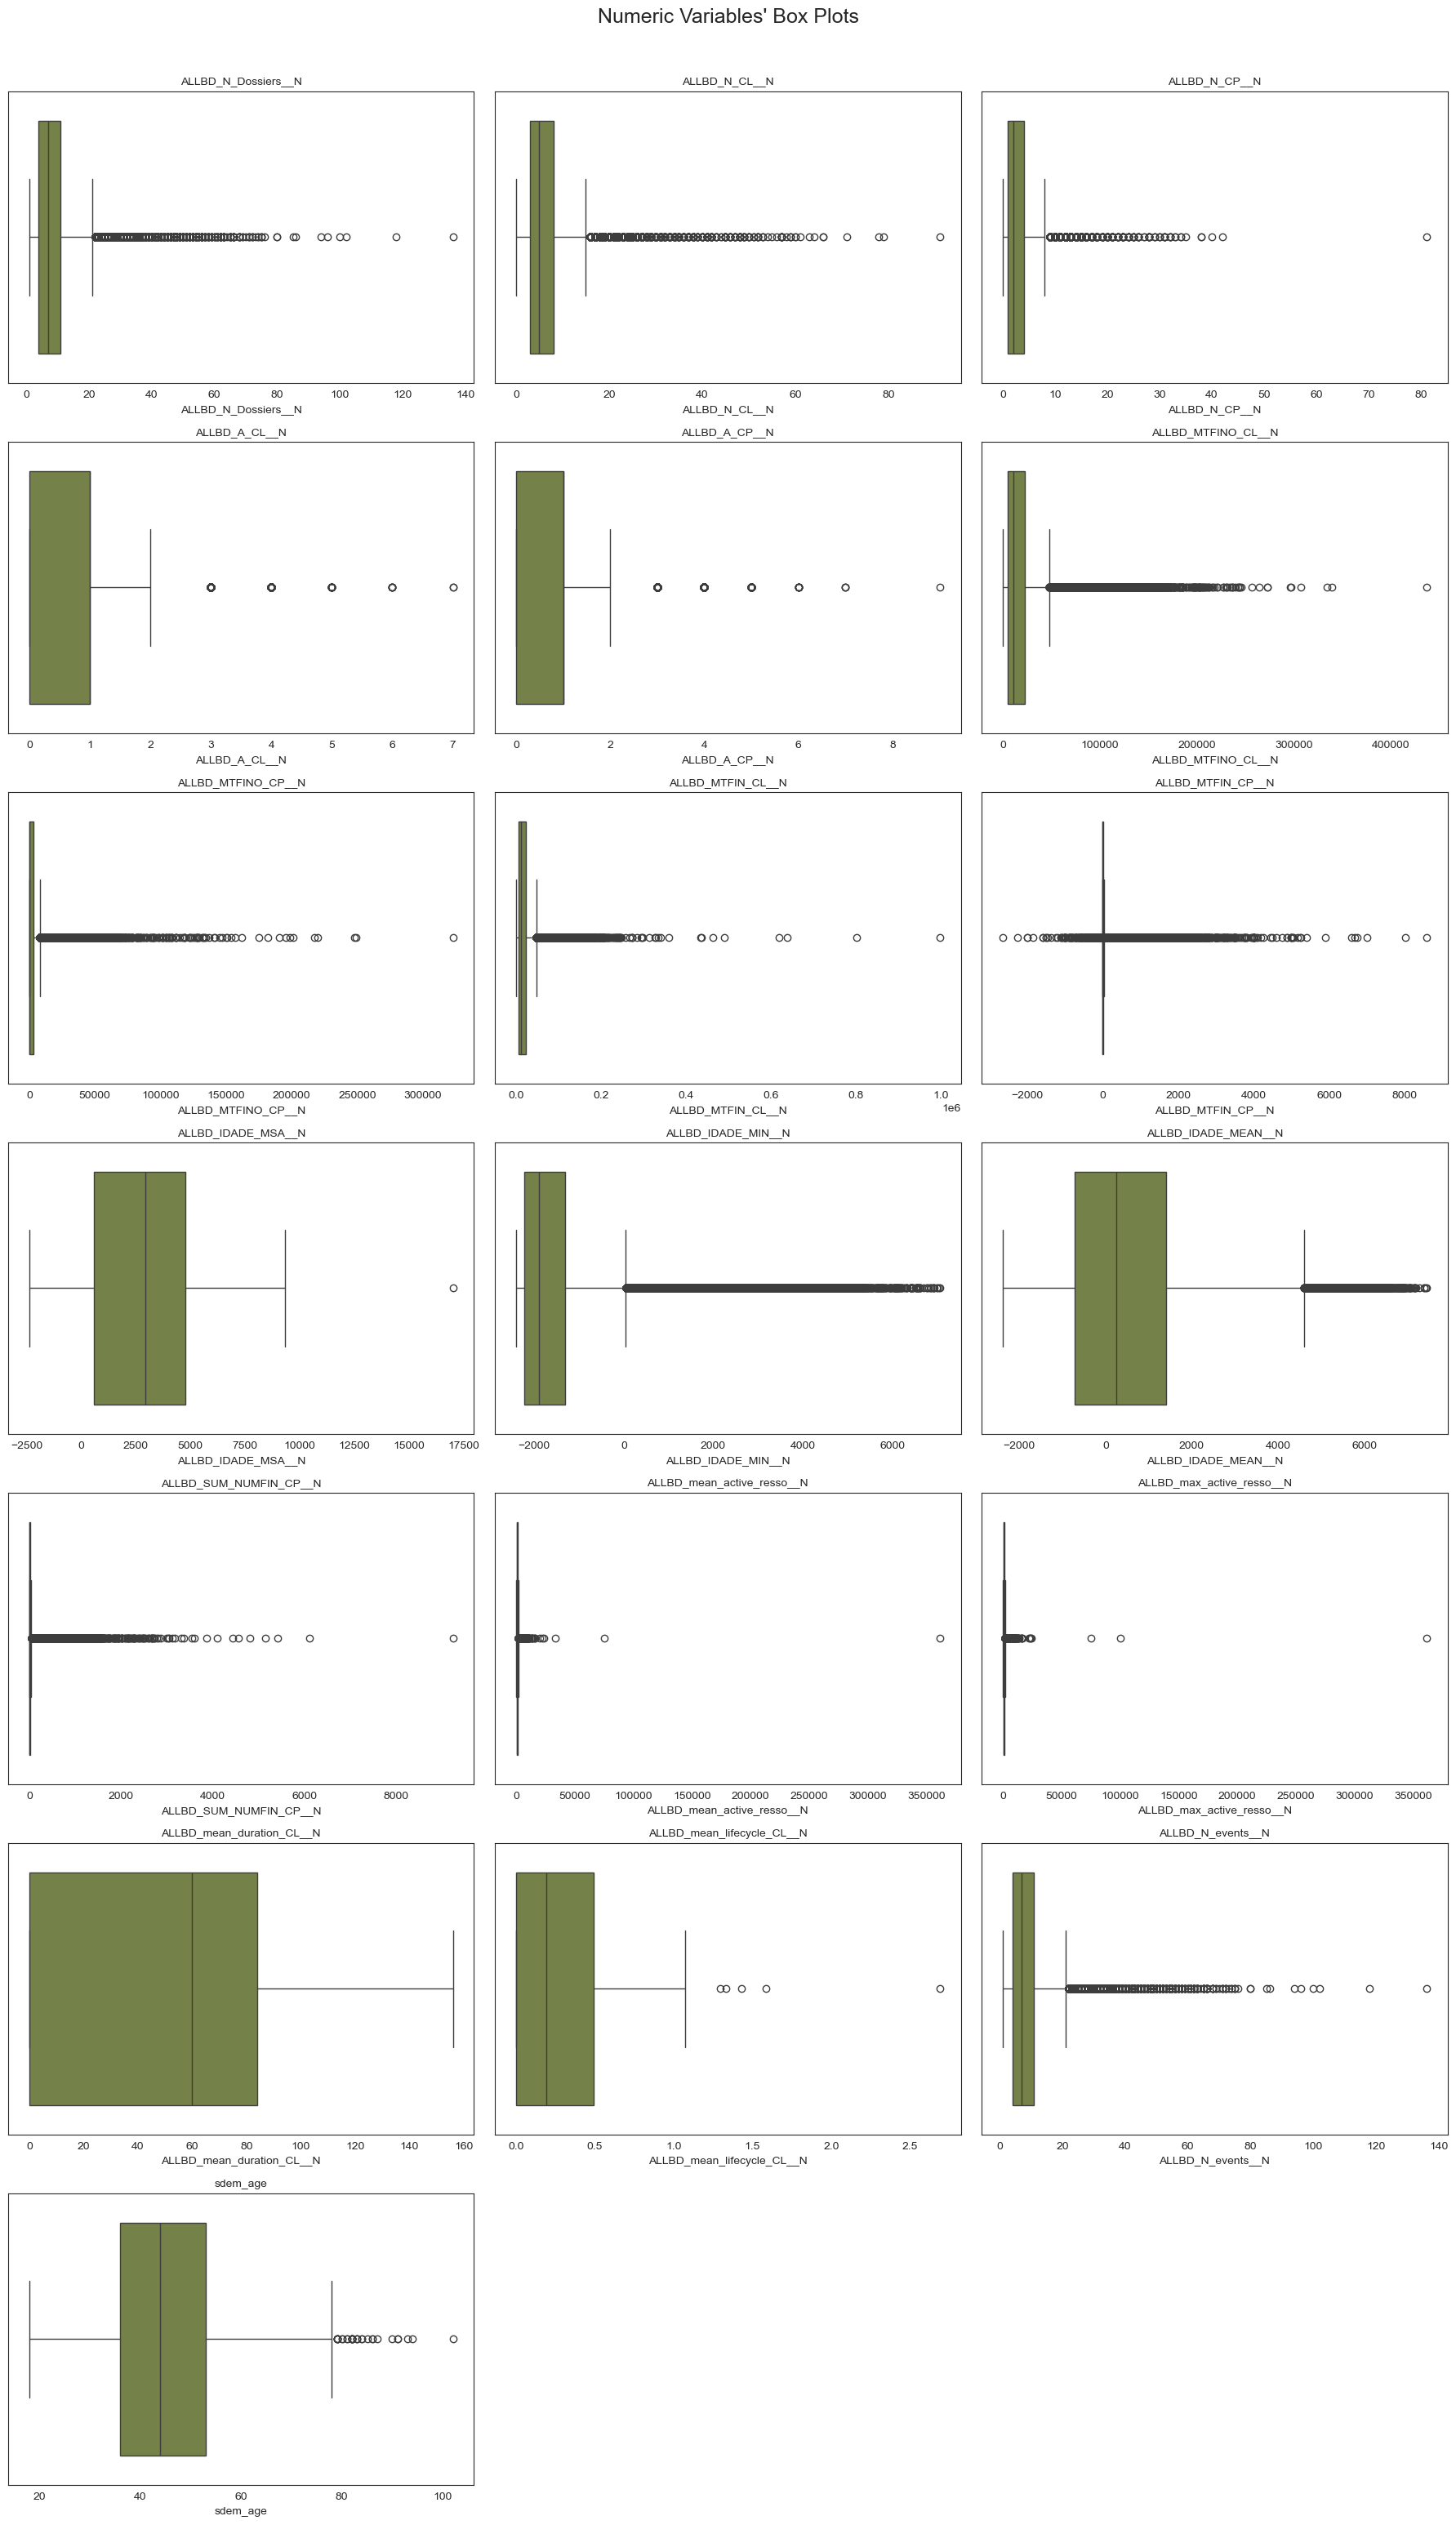

In [110]:
plot_multiple_boxplots(FAMA, num_cols)

In [111]:
#checking nº of observations where 'ALLBD_N_Dossiers__N'> 70
FAMA[FAMA['ALLBD_N_Dossiers__N'] > 70].count()

CONTRIB                       23
Date_Obs                      23
ALLBD_N_Dossiers__N           23
ALLBD_N_CL__N                 23
ALLBD_N_CP__N                 23
ALLBD_A_CL__N                 23
ALLBD_A_CP__N                 23
ALLBD_MTFINO_CL__N            23
ALLBD_MTFINO_CP__N            23
ALLBD_MTFIN_CL__N             23
ALLBD_MTFIN_CP__N             23
ALLBD_IDADE_MSA__N            23
ALLBD_IDADE_MIN__N            23
ALLBD_IDADE_MEAN__N           23
ALLBD_SUM_NUMFIN_CP__N        23
ALLBD_mean_active_resso__N    23
ALLBD_max_active_resso__N     23
ALLBD_mean_duration_CL__N     23
ALLBD_mean_lifecycle_CL__N    23
ALLBD_N_events__N             23
sdem_SITFAM                   23
sdem_HABITAT                  23
sdem_age                      23
dtype: int64

In [112]:
#checking nº of observations where 'ALLBD_N_CL__N'> 55
FAMA[FAMA['ALLBD_N_CL__N'] > 55].count()

CONTRIB                       24
Date_Obs                      24
ALLBD_N_Dossiers__N           24
ALLBD_N_CL__N                 24
ALLBD_N_CP__N                 24
ALLBD_A_CL__N                 24
ALLBD_A_CP__N                 24
ALLBD_MTFINO_CL__N            24
ALLBD_MTFINO_CP__N            24
ALLBD_MTFIN_CL__N             24
ALLBD_MTFIN_CP__N             24
ALLBD_IDADE_MSA__N            24
ALLBD_IDADE_MIN__N            24
ALLBD_IDADE_MEAN__N           24
ALLBD_SUM_NUMFIN_CP__N        24
ALLBD_mean_active_resso__N    24
ALLBD_max_active_resso__N     24
ALLBD_mean_duration_CL__N     24
ALLBD_mean_lifecycle_CL__N    24
ALLBD_N_events__N             24
sdem_SITFAM                   24
sdem_HABITAT                  24
sdem_age                      24
dtype: int64

In [113]:
#checking nº of observations where 'ALLBD_N_CP__N'> 30
FAMA[FAMA['ALLBD_N_CP__N'] > 30].count()

CONTRIB                       19
Date_Obs                      19
ALLBD_N_Dossiers__N           19
ALLBD_N_CL__N                 19
ALLBD_N_CP__N                 19
ALLBD_A_CL__N                 19
ALLBD_A_CP__N                 19
ALLBD_MTFINO_CL__N            19
ALLBD_MTFINO_CP__N            19
ALLBD_MTFIN_CL__N             19
ALLBD_MTFIN_CP__N             19
ALLBD_IDADE_MSA__N            19
ALLBD_IDADE_MIN__N            19
ALLBD_IDADE_MEAN__N           19
ALLBD_SUM_NUMFIN_CP__N        19
ALLBD_mean_active_resso__N    19
ALLBD_max_active_resso__N     19
ALLBD_mean_duration_CL__N     19
ALLBD_mean_lifecycle_CL__N    19
ALLBD_N_events__N             19
sdem_SITFAM                   19
sdem_HABITAT                  19
sdem_age                      19
dtype: int64

In [114]:
#checking nº of observations where 'ALLBD_A_CL__N'> 4
FAMA[FAMA['ALLBD_A_CL__N'] > 4].count()

CONTRIB                       35
Date_Obs                      35
ALLBD_N_Dossiers__N           35
ALLBD_N_CL__N                 35
ALLBD_N_CP__N                 35
ALLBD_A_CL__N                 35
ALLBD_A_CP__N                 35
ALLBD_MTFINO_CL__N            35
ALLBD_MTFINO_CP__N            35
ALLBD_MTFIN_CL__N             35
ALLBD_MTFIN_CP__N             35
ALLBD_IDADE_MSA__N            35
ALLBD_IDADE_MIN__N            35
ALLBD_IDADE_MEAN__N           35
ALLBD_SUM_NUMFIN_CP__N        35
ALLBD_mean_active_resso__N    35
ALLBD_max_active_resso__N     35
ALLBD_mean_duration_CL__N     35
ALLBD_mean_lifecycle_CL__N    35
ALLBD_N_events__N             35
sdem_SITFAM                   35
sdem_HABITAT                  35
sdem_age                      35
dtype: int64

In [115]:
#checking nº of observations where 'ALLBD_A_CP__N'> 5
FAMA[FAMA['ALLBD_A_CP__N'] > 5].count()

CONTRIB                       12
Date_Obs                      12
ALLBD_N_Dossiers__N           12
ALLBD_N_CL__N                 12
ALLBD_N_CP__N                 12
ALLBD_A_CL__N                 12
ALLBD_A_CP__N                 12
ALLBD_MTFINO_CL__N            12
ALLBD_MTFINO_CP__N            12
ALLBD_MTFIN_CL__N             12
ALLBD_MTFIN_CP__N             12
ALLBD_IDADE_MSA__N            12
ALLBD_IDADE_MIN__N            12
ALLBD_IDADE_MEAN__N           12
ALLBD_SUM_NUMFIN_CP__N        12
ALLBD_mean_active_resso__N    12
ALLBD_max_active_resso__N     12
ALLBD_mean_duration_CL__N     12
ALLBD_mean_lifecycle_CL__N    12
ALLBD_N_events__N             12
sdem_SITFAM                   12
sdem_HABITAT                  12
sdem_age                      12
dtype: int64

In [116]:
#checking nº of observations where 'ALLBD_MTFINO_CL__N'> 250000
FAMA[FAMA['ALLBD_MTFINO_CL__N'] > 250000].count()

CONTRIB                       10
Date_Obs                      10
ALLBD_N_Dossiers__N           10
ALLBD_N_CL__N                 10
ALLBD_N_CP__N                 10
ALLBD_A_CL__N                 10
ALLBD_A_CP__N                 10
ALLBD_MTFINO_CL__N            10
ALLBD_MTFINO_CP__N            10
ALLBD_MTFIN_CL__N             10
ALLBD_MTFIN_CP__N             10
ALLBD_IDADE_MSA__N            10
ALLBD_IDADE_MIN__N            10
ALLBD_IDADE_MEAN__N           10
ALLBD_SUM_NUMFIN_CP__N        10
ALLBD_mean_active_resso__N    10
ALLBD_max_active_resso__N     10
ALLBD_mean_duration_CL__N     10
ALLBD_mean_lifecycle_CL__N    10
ALLBD_N_events__N             10
sdem_SITFAM                   10
sdem_HABITAT                  10
sdem_age                      10
dtype: int64

In [117]:
#checking nº of observations where 'ALLBD_MTFINO_CP__N'> 150000
FAMA[FAMA['ALLBD_MTFINO_CP__N'] > 150000].count()

CONTRIB                       16
Date_Obs                      16
ALLBD_N_Dossiers__N           16
ALLBD_N_CL__N                 16
ALLBD_N_CP__N                 16
ALLBD_A_CL__N                 16
ALLBD_A_CP__N                 16
ALLBD_MTFINO_CL__N            16
ALLBD_MTFINO_CP__N            16
ALLBD_MTFIN_CL__N             16
ALLBD_MTFIN_CP__N             16
ALLBD_IDADE_MSA__N            16
ALLBD_IDADE_MIN__N            16
ALLBD_IDADE_MEAN__N           16
ALLBD_SUM_NUMFIN_CP__N        16
ALLBD_mean_active_resso__N    16
ALLBD_max_active_resso__N     16
ALLBD_mean_duration_CL__N     16
ALLBD_mean_lifecycle_CL__N    16
ALLBD_N_events__N             16
sdem_SITFAM                   16
sdem_HABITAT                  16
sdem_age                      16
dtype: int64

In [118]:
#checking nº of observations where 'ALLBD_MTFIN_CL__N'> 250000
FAMA[FAMA['ALLBD_MTFIN_CL__N'] > 250000].count()

CONTRIB                       23
Date_Obs                      23
ALLBD_N_Dossiers__N           23
ALLBD_N_CL__N                 23
ALLBD_N_CP__N                 23
ALLBD_A_CL__N                 23
ALLBD_A_CP__N                 23
ALLBD_MTFINO_CL__N            23
ALLBD_MTFINO_CP__N            23
ALLBD_MTFIN_CL__N             23
ALLBD_MTFIN_CP__N             23
ALLBD_IDADE_MSA__N            23
ALLBD_IDADE_MIN__N            23
ALLBD_IDADE_MEAN__N           23
ALLBD_SUM_NUMFIN_CP__N        23
ALLBD_mean_active_resso__N    23
ALLBD_max_active_resso__N     23
ALLBD_mean_duration_CL__N     23
ALLBD_mean_lifecycle_CL__N    23
ALLBD_N_events__N             23
sdem_SITFAM                   23
sdem_HABITAT                  23
sdem_age                      23
dtype: int64

In [119]:
#checking nº of observations where 'ALLBD_MTFIN_CP__N'> 4000
FAMA[FAMA['ALLBD_MTFIN_CP__N'] > 4000].count()

CONTRIB                       29
Date_Obs                      29
ALLBD_N_Dossiers__N           29
ALLBD_N_CL__N                 29
ALLBD_N_CP__N                 29
ALLBD_A_CL__N                 29
ALLBD_A_CP__N                 29
ALLBD_MTFINO_CL__N            29
ALLBD_MTFINO_CP__N            29
ALLBD_MTFIN_CL__N             29
ALLBD_MTFIN_CP__N             29
ALLBD_IDADE_MSA__N            29
ALLBD_IDADE_MIN__N            29
ALLBD_IDADE_MEAN__N           29
ALLBD_SUM_NUMFIN_CP__N        29
ALLBD_mean_active_resso__N    29
ALLBD_max_active_resso__N     29
ALLBD_mean_duration_CL__N     29
ALLBD_mean_lifecycle_CL__N    29
ALLBD_N_events__N             29
sdem_SITFAM                   29
sdem_HABITAT                  29
sdem_age                      29
dtype: int64

In [120]:
#checking nº of observations where 'ALLBD_IDADE_MSA__N'> 10000
FAMA[FAMA['ALLBD_IDADE_MSA__N'] > 10000].count()

CONTRIB                       1
Date_Obs                      1
ALLBD_N_Dossiers__N           1
ALLBD_N_CL__N                 1
ALLBD_N_CP__N                 1
ALLBD_A_CL__N                 1
ALLBD_A_CP__N                 1
ALLBD_MTFINO_CL__N            1
ALLBD_MTFINO_CP__N            1
ALLBD_MTFIN_CL__N             1
ALLBD_MTFIN_CP__N             1
ALLBD_IDADE_MSA__N            1
ALLBD_IDADE_MIN__N            1
ALLBD_IDADE_MEAN__N           1
ALLBD_SUM_NUMFIN_CP__N        1
ALLBD_mean_active_resso__N    1
ALLBD_max_active_resso__N     1
ALLBD_mean_duration_CL__N     1
ALLBD_mean_lifecycle_CL__N    1
ALLBD_N_events__N             1
sdem_SITFAM                   1
sdem_HABITAT                  1
sdem_age                      1
dtype: int64

In [121]:
#checking nº of observations where 'ALLBD_SUM_NUMFIN_CP__N'> 3000
FAMA[FAMA['ALLBD_SUM_NUMFIN_CP__N'] > 3000].count()

CONTRIB                       17
Date_Obs                      17
ALLBD_N_Dossiers__N           17
ALLBD_N_CL__N                 17
ALLBD_N_CP__N                 17
ALLBD_A_CL__N                 17
ALLBD_A_CP__N                 17
ALLBD_MTFINO_CL__N            17
ALLBD_MTFINO_CP__N            17
ALLBD_MTFIN_CL__N             17
ALLBD_MTFIN_CP__N             17
ALLBD_IDADE_MSA__N            17
ALLBD_IDADE_MIN__N            17
ALLBD_IDADE_MEAN__N           17
ALLBD_SUM_NUMFIN_CP__N        17
ALLBD_mean_active_resso__N    17
ALLBD_max_active_resso__N     17
ALLBD_mean_duration_CL__N     17
ALLBD_mean_lifecycle_CL__N    17
ALLBD_N_events__N             17
sdem_SITFAM                   17
sdem_HABITAT                  17
sdem_age                      17
dtype: int64

In [122]:
#checking nº of observations where 'ALLBD_mean_active_resso__N'> 10000
FAMA[FAMA['ALLBD_mean_active_resso__N'] > 10000].count()

CONTRIB                       24
Date_Obs                      24
ALLBD_N_Dossiers__N           24
ALLBD_N_CL__N                 24
ALLBD_N_CP__N                 24
ALLBD_A_CL__N                 24
ALLBD_A_CP__N                 24
ALLBD_MTFINO_CL__N            24
ALLBD_MTFINO_CP__N            24
ALLBD_MTFIN_CL__N             24
ALLBD_MTFIN_CP__N             24
ALLBD_IDADE_MSA__N            24
ALLBD_IDADE_MIN__N            24
ALLBD_IDADE_MEAN__N           24
ALLBD_SUM_NUMFIN_CP__N        24
ALLBD_mean_active_resso__N    24
ALLBD_max_active_resso__N     24
ALLBD_mean_duration_CL__N     24
ALLBD_mean_lifecycle_CL__N    24
ALLBD_N_events__N             24
sdem_SITFAM                   24
sdem_HABITAT                  24
sdem_age                      24
dtype: int64

In [123]:
#checking nº of observations where 'ALLBD_max_active_resso__N'> 15000
FAMA[FAMA['ALLBD_max_active_resso__N'] > 15000].count()

CONTRIB                       11
Date_Obs                      11
ALLBD_N_Dossiers__N           11
ALLBD_N_CL__N                 11
ALLBD_N_CP__N                 11
ALLBD_A_CL__N                 11
ALLBD_A_CP__N                 11
ALLBD_MTFINO_CL__N            11
ALLBD_MTFINO_CP__N            11
ALLBD_MTFIN_CL__N             11
ALLBD_MTFIN_CP__N             11
ALLBD_IDADE_MSA__N            11
ALLBD_IDADE_MIN__N            11
ALLBD_IDADE_MEAN__N           11
ALLBD_SUM_NUMFIN_CP__N        11
ALLBD_mean_active_resso__N    11
ALLBD_max_active_resso__N     11
ALLBD_mean_duration_CL__N     11
ALLBD_mean_lifecycle_CL__N    11
ALLBD_N_events__N             11
sdem_SITFAM                   11
sdem_HABITAT                  11
sdem_age                      11
dtype: int64

In [124]:
#checking nº of observations where 'ALLBD_mean_lifecycle_CL__N'> 1
FAMA[FAMA['ALLBD_mean_lifecycle_CL__N'] > 1].count()

CONTRIB                       16
Date_Obs                      16
ALLBD_N_Dossiers__N           16
ALLBD_N_CL__N                 16
ALLBD_N_CP__N                 16
ALLBD_A_CL__N                 16
ALLBD_A_CP__N                 16
ALLBD_MTFINO_CL__N            16
ALLBD_MTFINO_CP__N            16
ALLBD_MTFIN_CL__N             16
ALLBD_MTFIN_CP__N             16
ALLBD_IDADE_MSA__N            16
ALLBD_IDADE_MIN__N            16
ALLBD_IDADE_MEAN__N           16
ALLBD_SUM_NUMFIN_CP__N        16
ALLBD_mean_active_resso__N    16
ALLBD_max_active_resso__N     16
ALLBD_mean_duration_CL__N     16
ALLBD_mean_lifecycle_CL__N    16
ALLBD_N_events__N             16
sdem_SITFAM                   16
sdem_HABITAT                  16
sdem_age                      16
dtype: int64

In [125]:
#checking nº of observations where 'ALLBD_N_events__N'> 70
FAMA[FAMA['ALLBD_N_events__N'] > 70].count()

CONTRIB                       23
Date_Obs                      23
ALLBD_N_Dossiers__N           23
ALLBD_N_CL__N                 23
ALLBD_N_CP__N                 23
ALLBD_A_CL__N                 23
ALLBD_A_CP__N                 23
ALLBD_MTFINO_CL__N            23
ALLBD_MTFINO_CP__N            23
ALLBD_MTFIN_CL__N             23
ALLBD_MTFIN_CP__N             23
ALLBD_IDADE_MSA__N            23
ALLBD_IDADE_MIN__N            23
ALLBD_IDADE_MEAN__N           23
ALLBD_SUM_NUMFIN_CP__N        23
ALLBD_mean_active_resso__N    23
ALLBD_max_active_resso__N     23
ALLBD_mean_duration_CL__N     23
ALLBD_mean_lifecycle_CL__N    23
ALLBD_N_events__N             23
sdem_SITFAM                   23
sdem_HABITAT                  23
sdem_age                      23
dtype: int64

In [126]:
#checking nº of observations where 'sdem_age'> 85
FAMA[FAMA['sdem_age'] > 85].count()

CONTRIB                       9
Date_Obs                      9
ALLBD_N_Dossiers__N           9
ALLBD_N_CL__N                 9
ALLBD_N_CP__N                 9
ALLBD_A_CL__N                 9
ALLBD_A_CP__N                 9
ALLBD_MTFINO_CL__N            9
ALLBD_MTFINO_CP__N            9
ALLBD_MTFIN_CL__N             9
ALLBD_MTFIN_CP__N             9
ALLBD_IDADE_MSA__N            9
ALLBD_IDADE_MIN__N            9
ALLBD_IDADE_MEAN__N           9
ALLBD_SUM_NUMFIN_CP__N        9
ALLBD_mean_active_resso__N    9
ALLBD_max_active_resso__N     9
ALLBD_mean_duration_CL__N     9
ALLBD_mean_lifecycle_CL__N    9
ALLBD_N_events__N             9
sdem_SITFAM                   9
sdem_HABITAT                  9
sdem_age                      9
dtype: int64

### 3.6. Checking Distribution

#### 3.6.1. Numerical Variables

In [127]:
#settinh the data frame
df= pd.DataFrame(FAMA[num_cols])

In [128]:
def plot_numeric_histograms(data, numeric_cols=None, n_samples=200_000, plots_per_fig=6,
                            bins=60, color='#798a40', title_prefix="Histogram of"):

    sns.set_style("white")
    
    #sampling data for performance
    sample = data.sample(n=min(n_samples, len(data)), random_state=42)
    
    #determining columns to plot
    if numeric_cols is None:
        numeric_cols = sample.select_dtypes(include=[np.number]).columns
    
    n_figs = ceil(len(numeric_cols) / plots_per_fig)
    
    #looping through figures
    for f in range(n_figs):
        start = f * plots_per_fig
        end = start + plots_per_fig
        subset_cols = numeric_cols[start:end]
        
        #creating subplots
        n_rows = 2
        n_cols = 3
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 8), facecolor='white')
        axes = axes.ravel()
        
        #ploting each histogram
        for ax, col in zip(axes, subset_cols):
            sns.histplot(sample[col].dropna(), bins=bins, kde=False, ax=ax, color=color)
            ax.set_title(f"{title_prefix} {col}", fontsize=10)
            ax.set_ylabel("Frequency")
            sns.despine(ax=ax)
        
        #removing empty subplots if last figure has fewer than plots_per_fig
        for j in range(len(subset_cols), len(axes)):
            fig.delaxes(axes[j])
        
        plt.tight_layout()
        plt.show()

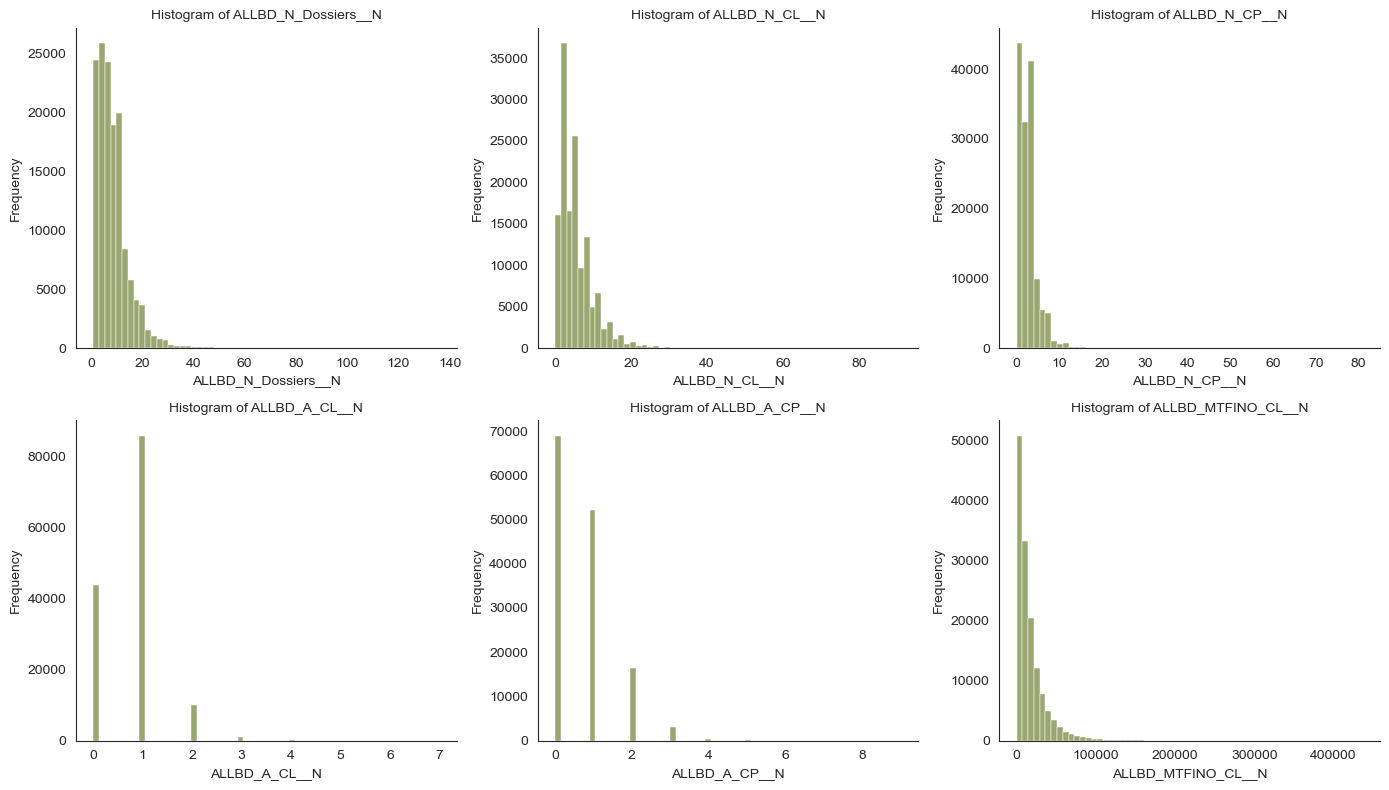

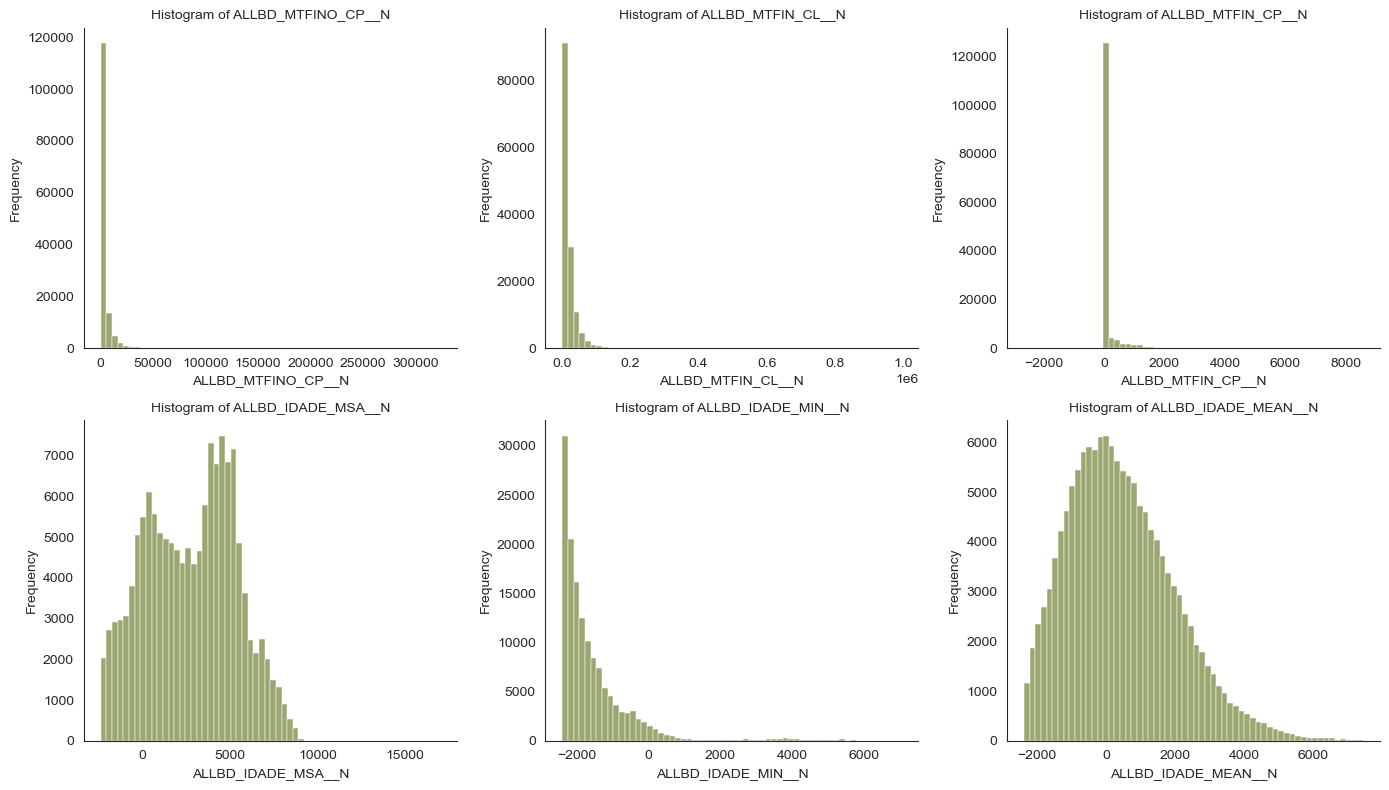

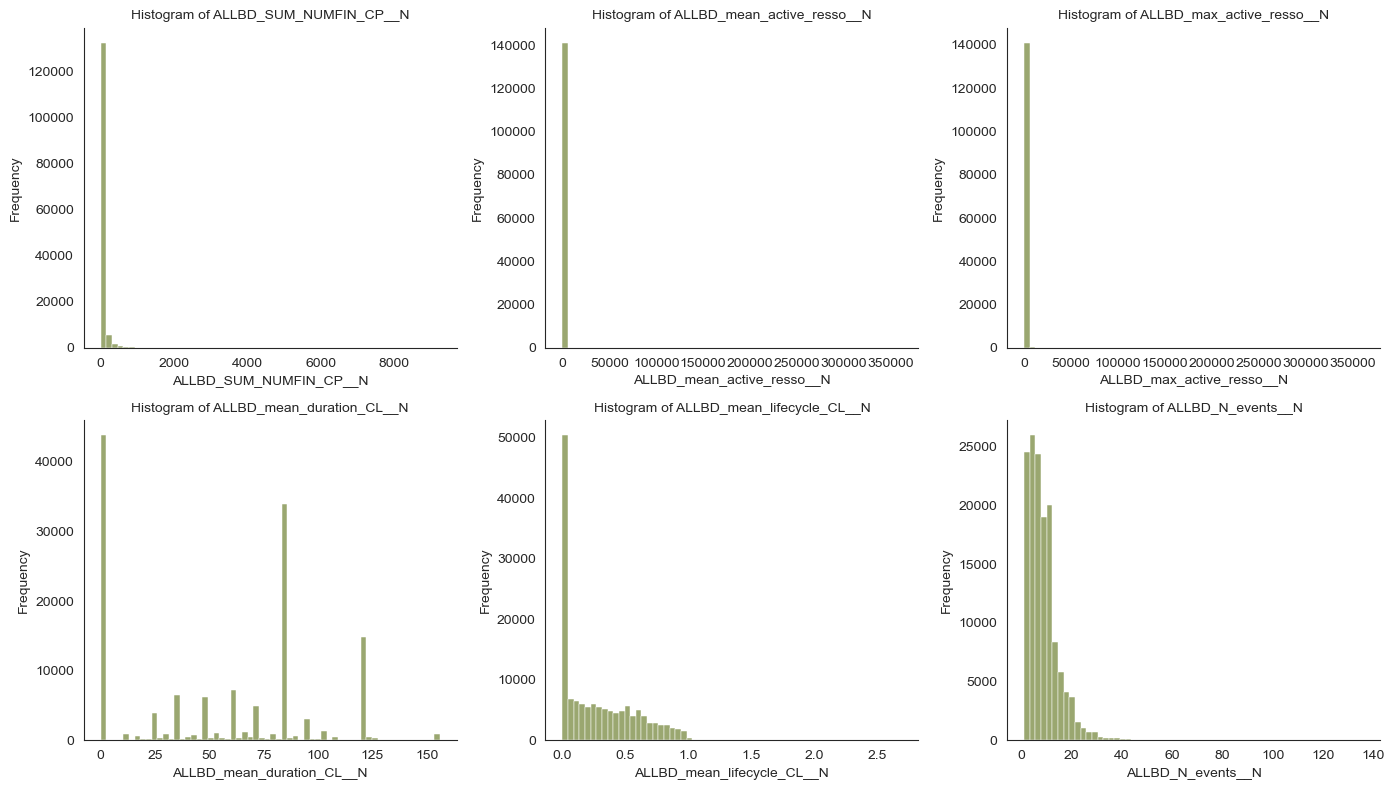

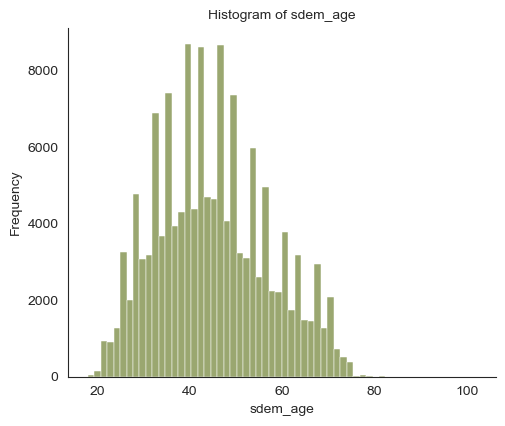

In [129]:
plot_numeric_histograms(FAMA, num_cols)

#### 3.6.2. Categorical Variables

In [130]:
non_numerical_features= ['sdem_SITFAM', 'sdem_HABITAT']

C:\Users\alano\AppData\Local\Temp\ipykernel_16168\3890668660.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


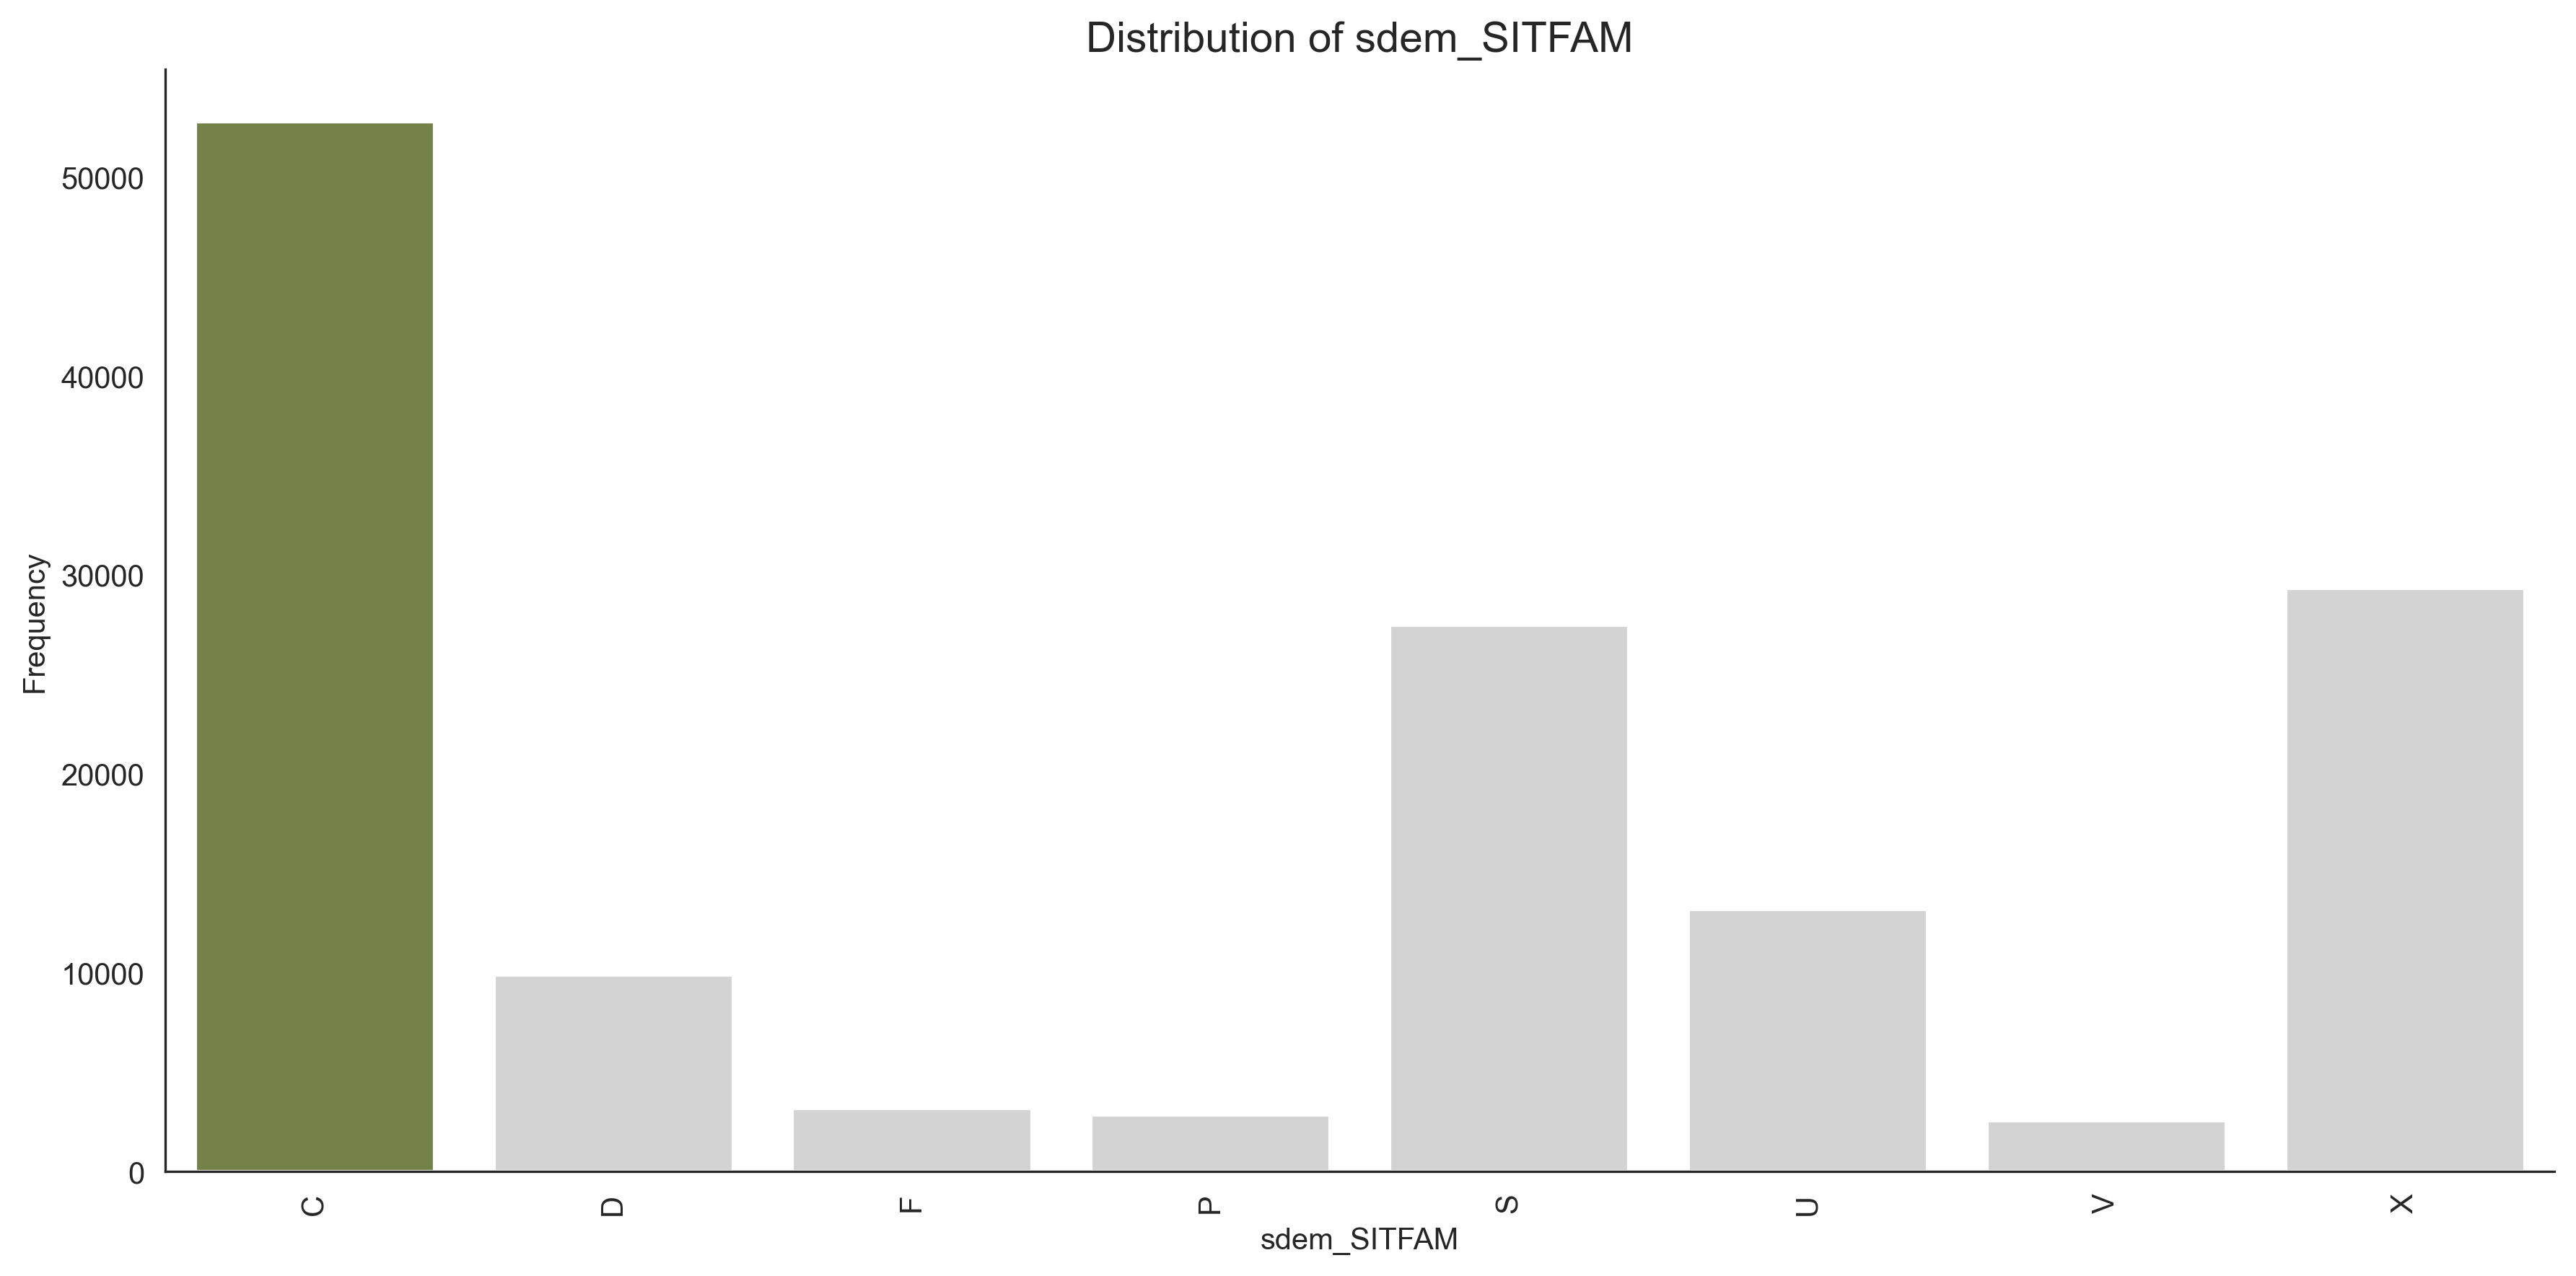

C:\Users\alano\AppData\Local\Temp\ipykernel_16168\3890668660.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


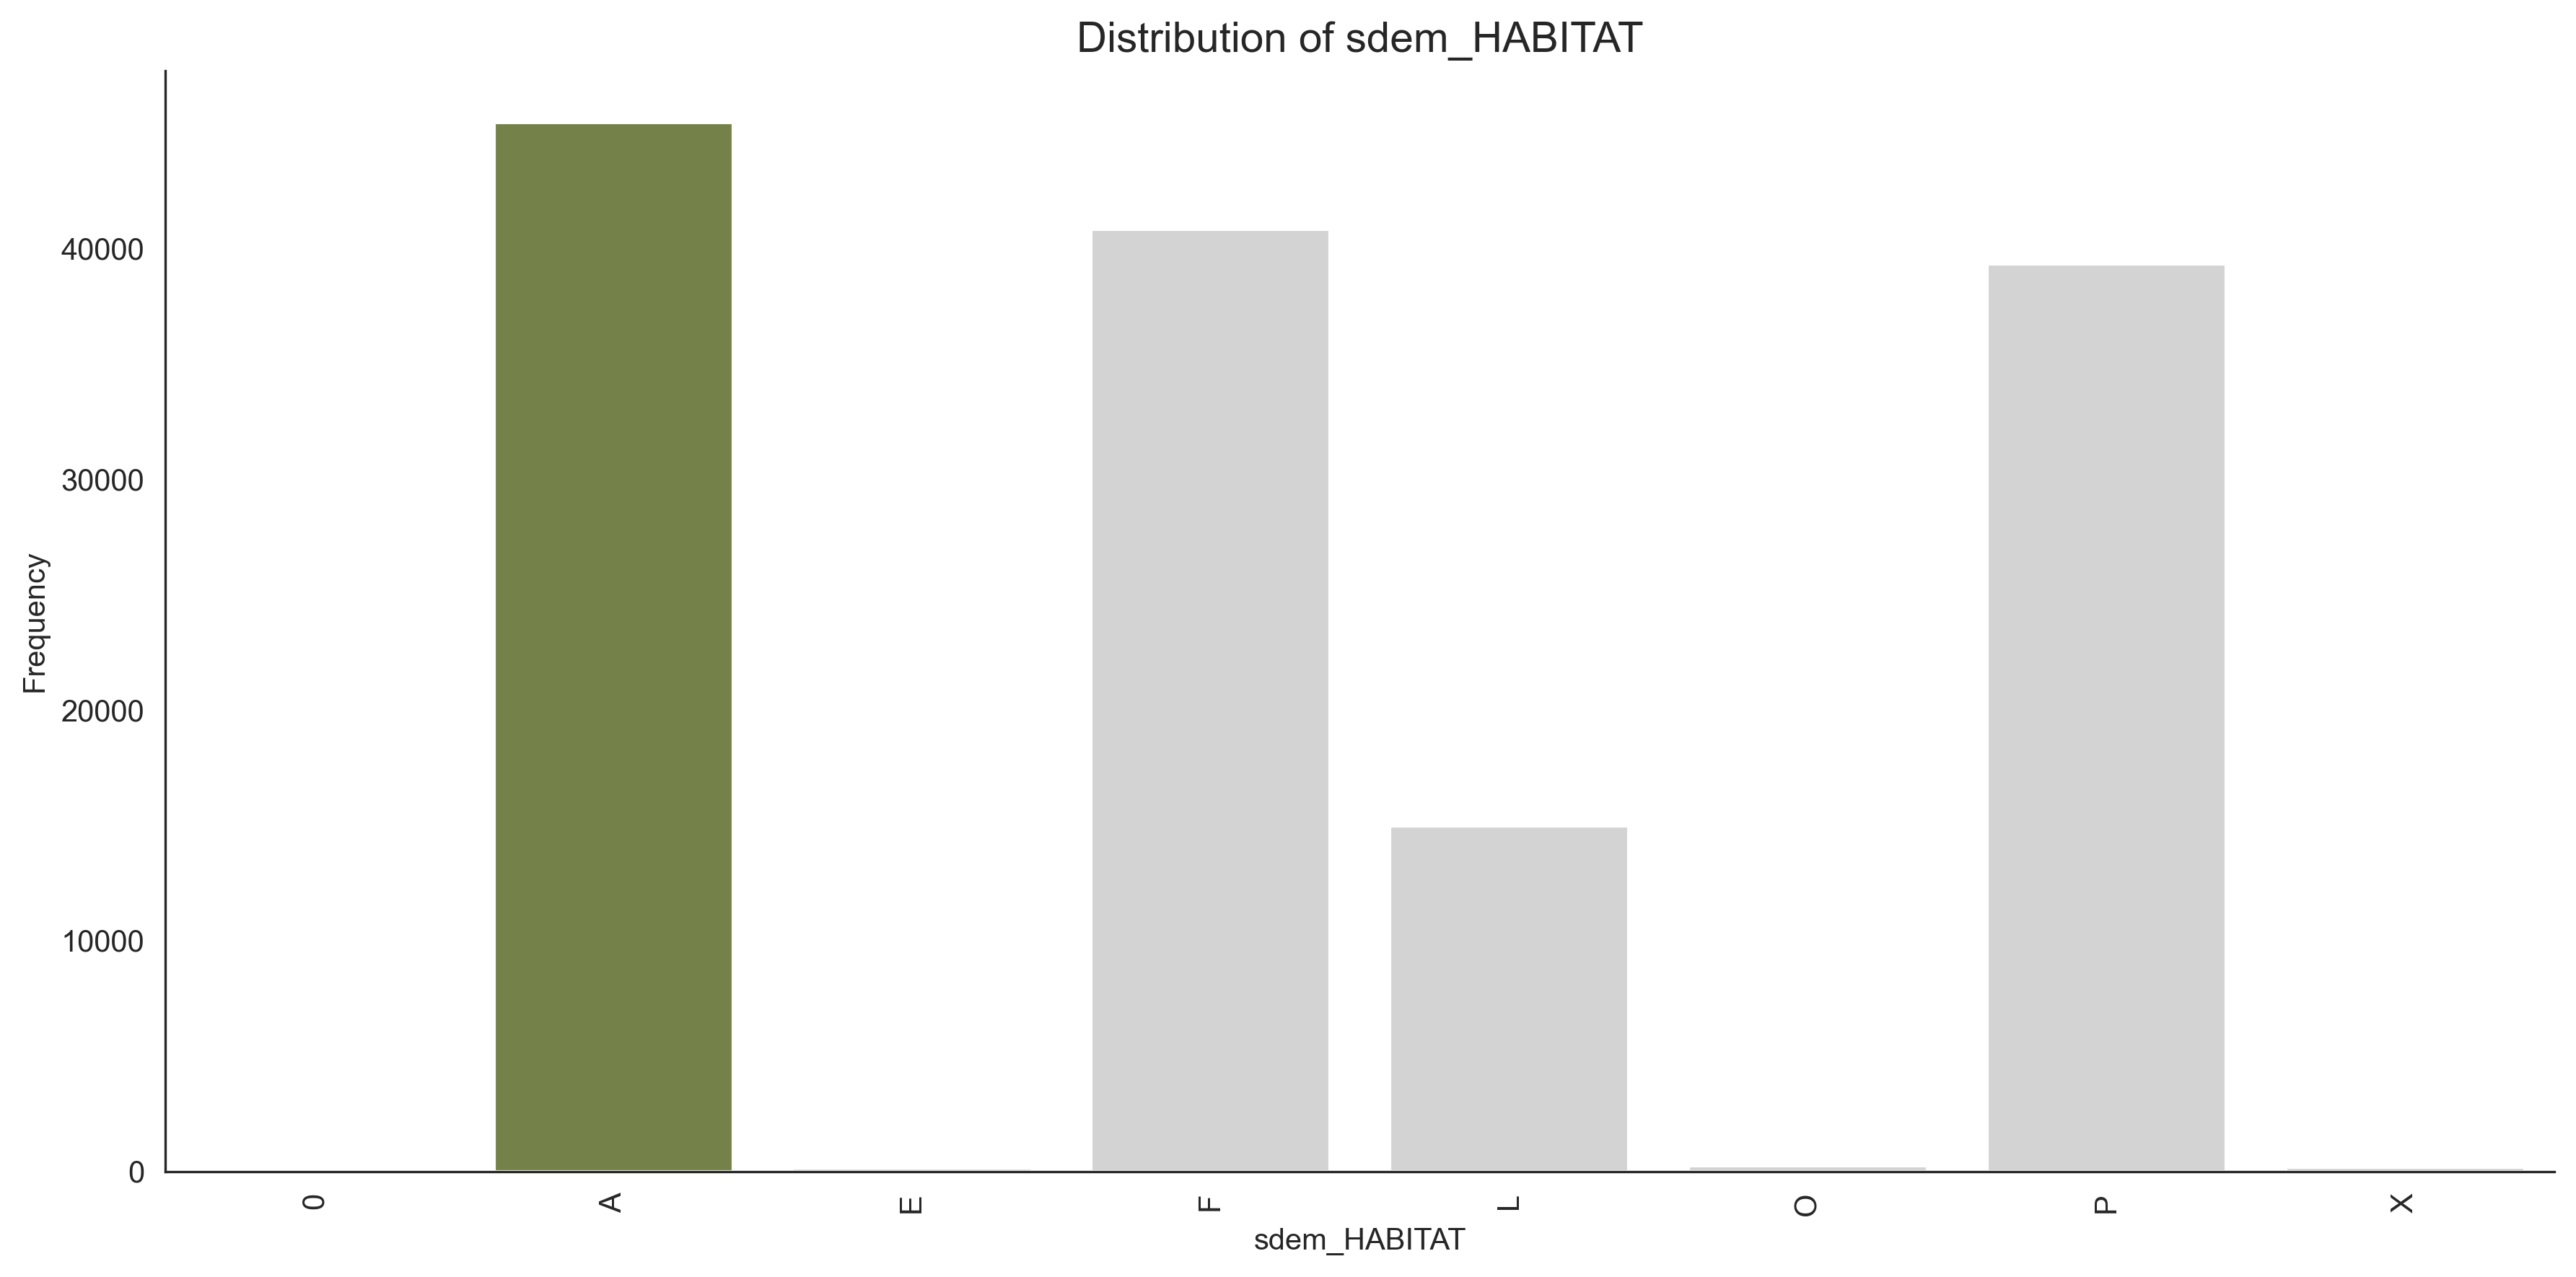

In [131]:
def plot_categorical_highlight(data, column, highlight_color="#798a40", default_color="lightgray"):

    #counting observations per category
    counts = data[column].value_counts().sort_index()

    #finding category with highest observations
    max_category = counts.idxmax()
    palette = [highlight_color if cat == max_category else default_color for cat in counts.index]

    #setting style and figure
    sns.set_style("white")
    plt.figure(dpi=300, figsize=(12,6))
    plt.gcf().patch.set_facecolor('white')  # background

    #ploting bar chart
    sns.barplot(
        x=counts.index,
        y=counts.values,
        palette=palette
    )

    plt.xticks(rotation=90)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}", fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.show()

# -----------------------------
# Example usage
# -----------------------------
for col in non_numerical_features:
    plot_categorical_highlight(FAMA, col)


### 3.7. Checking Correlation between variables

In [132]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = FAMA[num_cols].corr(method ='spearman')
cor_spearman

,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_age
ALLBD_N_Dossiers__N,1.000000,0.927566,0.731157,0.108140,0.246939,0.388763,0.284660,0.392554,0.192713,0.486802,-0.252399,0.315369,0.276960,0.166793,0.183376,0.098130,0.021250,0.999999,0.107667
ALLBD_N_CL__N,0.927566,1.000000,0.452514,0.134069,0.105994,0.448910,0.168801,0.452658,0.100483,0.444684,-0.234501,0.288707,0.163949,0.133789,0.146695,0.121406,0.035402,0.927565,0.111628
ALLBD_N_CP__N,0.731157,0.452514,1.000000,0.022706,0.420731,0.134530,0.396886,0.137201,0.293239,0.394368,-0.189690,0.258184,0.386518,0.164473,0.182269,0.018513,-0.010357,0.731158,0.068914
ALLBD_A_CL__N,0.108140,0.134069,0.022706,1.000000,0.067870,0.308200,0.028831,0.305528,0.046033,-0.046302,-0.274658,-0.162982,0.033178,0.399688,0.423781,0.746659,0.750407,0.108142,-0.015952
ALLBD_A_CP__N,0.246939,0.105994,0.420731,0.067870,1.000000,-0.004449,0.831273,-0.004615,0.669278,0.049498,-0.194734,-0.057555,0.810063,0.330669,0.370518,0.007268,0.030222,0.246944,0.013055
ALLBD_MTFINO_CL__N,0.388763,0.448910,0.134530,0.308200,-0.004449,1.000000,0.018045,0.998125,-0.020906,0.219766,-0.014698,0.157703,0.004661,0.223295,0.241692,0.455095,0.184296,0.388761,0.162105
ALLBD_MTFINO_CP__N,0.284660,0.168801,0.396886,0.028831,0.831273,0.018045,1.000000,0.019218,0.696048,0.119279,-0.142322,0.033532,0.966993,0.273915,0.313260,-0.008823,0.000644,0.284665,0.047066
ALLBD_MTFIN_CL__N,0.392554,0.452658,0.137201,0.305528,-0.004615,0.998125,0.019218,1.000000,-0.021329,0.229486,-0.012624,0.166521,0.005734,0.222905,0.241318,0.452091,0.182433,0.392553,0.167999
ALLBD_MTFIN_CP__N,0.192713,0.100483,0.293239,0.046033,0.669278,-0.020906,0.696048,-0.021329,1.000000,-0.000997,-0.250088,-0.104876,0.688639,0.250848,0.273812,-0.007455,-0.016425,0.192715,-0.043044
ALLBD_IDADE_MSA__N,0.486802,0.444684,0.394368,-0.046302,0.049498,0.219766,0.119279,0.229486,-0.000997,1.000000,0.122483,0.859910,0.104160,0.075105,0.085475,-0.004586,-0.007312,0.486804,0.477206


In [133]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap=sns.light_palette("#798a40", as_cmap=True), #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

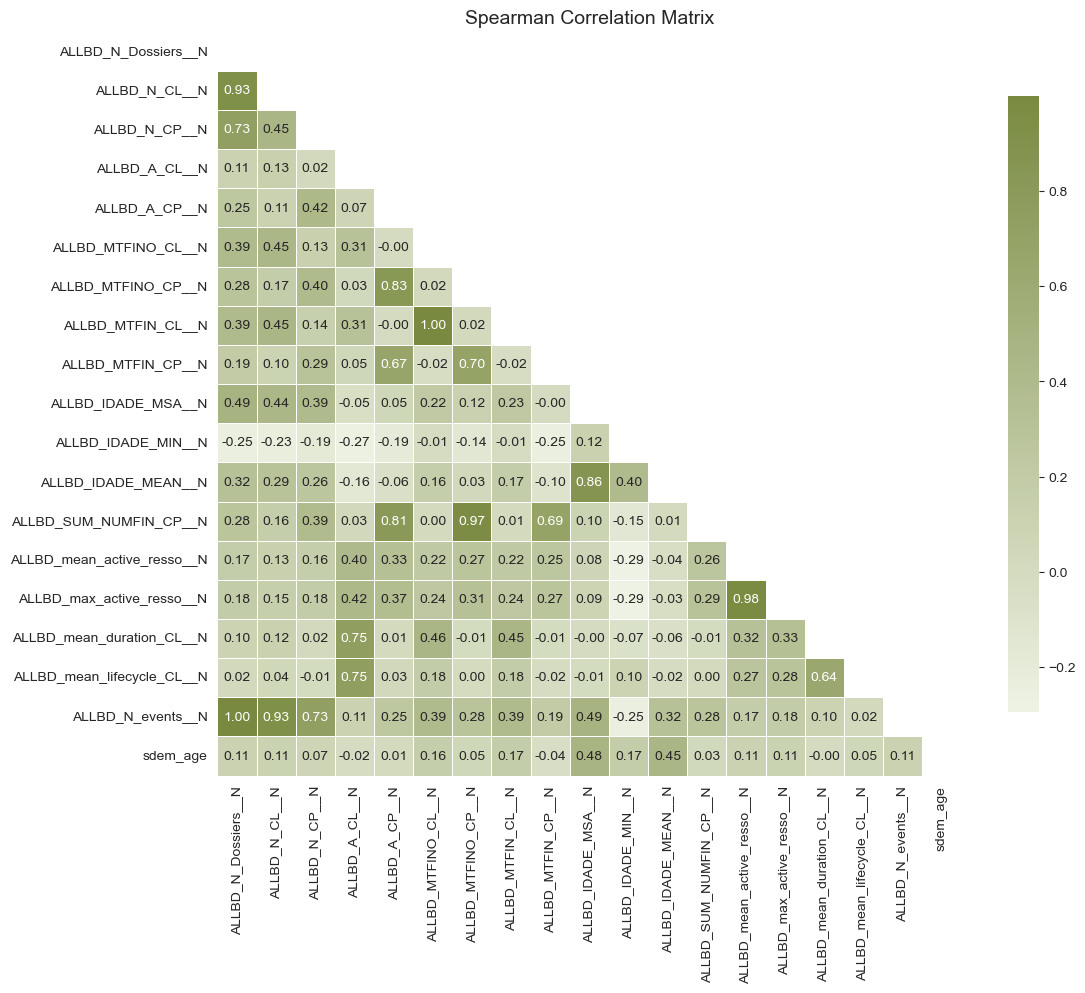

In [134]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

**Redundant Variables**:
- *ALLBD_N_CL__N* vs *ALLBD_N_Dossiers__N* (0.93)
- *ALLBD_MTFINO_CP_N* vs *ALL_A_CP_N* (0.83)
- *ALLBD_MTFIN_CL_N* vs *ALLBD_MTFINO_CL_N* (1.00)
- *ALLBD_IDADE_MEAN_N* vs *ALLBD_IDADE_MSA_N* (0.86)
- *ALL_SUM_NUMFIN_CP_N* vs *ALLBD_A_CP_N* (0.81)
- *ALL_SUM_NUMFIN_CP_N* vs *ALLBD_MTFINO_CP_N* (0.97)
- *ALLBD_max_active_resso_N* vs *ALLBD_mean_active_resso_N* (0.98)
- *ALLBD_N_Dossiers__N* vs *ALLBD_N_events__N* (1.00)
- *ALLBD_N_events__N* vs *ALLBD_N_CL__N* (0.93)

## 4. Data Preparation

### 4.1. Changing Datatypes

In [135]:
#setting a maximum number for each variable that needs outliers treated
FAMA['ALLBD_N_Dossiers__N'] = FAMA['ALLBD_N_Dossiers__N'].round().astype('Int32')
FAMA['ALLBD_N_CL__N'] = FAMA['ALLBD_N_CL__N'].round().astype('Int32')
FAMA['ALLBD_N_CP__N'] = FAMA['ALLBD_N_CP__N'].round().astype('Int32')
FAMA['ALLBD_A_CL__N'] = FAMA['ALLBD_A_CL__N'].round().astype('Int32')
FAMA['ALLBD_A_CP__N'] = FAMA['ALLBD_A_CP__N'].round().astype('Int32')
FAMA['ALLBD_IDADE_MSA__N'] = FAMA['ALLBD_IDADE_MSA__N'].round().astype('Int32')
FAMA['ALLBD_IDADE_MIN__N'] = FAMA['ALLBD_IDADE_MIN__N'].round().astype('Int32')
FAMA['ALLBD_SUM_NUMFIN_CP__N'] = FAMA['ALLBD_SUM_NUMFIN_CP__N'].round().astype('Int32')
FAMA['ALLBD_N_events__N'] = FAMA['ALLBD_N_events__N'].round().astype('Int32')
FAMA['sdem_age'] = FAMA['sdem_age'].round().astype('Int32')

### 4.2. Handling Incoherencies

In [136]:
#replacing the value 'P' with 'Other'
FAMA["sdem_SITFAM"] = FAMA["sdem_SITFAM"].replace('F', 'X')

### 4.3. Handling Outliers

In [137]:

FAMA['ALLBD_N_Dossiers__N'] = FAMA['ALLBD_N_Dossiers__N'].clip(upper=70)
FAMA['ALLBD_N_CL__N'] = FAMA['ALLBD_N_CL__N'].clip(upper=55)
FAMA['ALLBD_N_CP__N'] = FAMA['ALLBD_N_CP__N'].clip(upper=30)
FAMA['ALLBD_A_CL__N'] = FAMA['ALLBD_A_CL__N'].clip(upper=4)
FAMA['ALLBD_A_CP__N'] = FAMA['ALLBD_A_CP__N'].clip(upper=5)
FAMA['ALLBD_MTFINO_CL__N'] = FAMA['ALLBD_MTFINO_CL__N'].clip(upper=250000)
FAMA['ALLBD_MTFINO_CP__N'] = FAMA['ALLBD_MTFINO_CP__N'].clip(upper=150000)
FAMA['ALLBD_MTFIN_CL__N'] = FAMA['ALLBD_MTFIN_CL__N'].clip(upper=250000)
FAMA['ALLBD_MTFIN_CP__N'] = FAMA['ALLBD_MTFIN_CP__N'].clip(upper=4000)
FAMA['ALLBD_IDADE_MSA__N'] = FAMA['ALLBD_IDADE_MSA__N'].clip(upper=10000)
FAMA['ALLBD_SUM_NUMFIN_CP__N'] = FAMA['ALLBD_SUM_NUMFIN_CP__N'].clip(upper=3000)
FAMA['ALLBD_mean_active_resso__N'] = FAMA['ALLBD_mean_active_resso__N'].clip(upper=10000)
FAMA['ALLBD_max_active_resso__N'] = FAMA['ALLBD_max_active_resso__N'].clip(upper=15000)
FAMA['ALLBD_mean_lifecycle_CL__N'] = FAMA['ALLBD_mean_lifecycle_CL__N'].clip(upper=1)
FAMA['ALLBD_N_events__N'] = FAMA['ALLBD_N_events__N'].clip(upper=70)
FAMA['sdem_age'] = FAMA['sdem_age'].clip(upper=85)

### 4.4. Feature Engineering

In [138]:
#creating 'active_credit_ratio'

FAMA["active_credit_ratio"] = (
    FAMA["ALLBD_A_CL__N"] + FAMA["ALLBD_A_CP__N"]
) / (
    FAMA["ALLBD_N_CL__N"] + FAMA["ALLBD_N_CP__N"] + 1
)

In [139]:
#removing the columns considered irrelevant
drop=['Date_Obs', 'ALLBD_N_Dossiers__N', 'ALLBD_N_CL__N', 
      'ALLBD_N_CP__N', 'ALLBD_A_CL__N', 'ALLBD_A_CP__N', 
      'ALLBD_MTFINO_CL__N', 'ALLBD_MTFINO_CP__N', 
      'ALLBD_MTFIN_CL__N', 'ALLBD_MTFIN_CP__N', 
      'ALLBD_IDADE_MSA__N', 'ALLBD_IDADE_MIN__N',
      'ALLBD_IDADE_MEAN__N', 'ALLBD_SUM_NUMFIN_CP__N', 
      'ALLBD_max_active_resso__N', 'ALLBD_mean_active_resso__N']
FAMA= FAMA.drop(columns=drop, errors='ignore')

- We have decided to drop these variables due to their amount of incoherencies and the redundance between some of them. 

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# BDOSS Dataset
       
</div>

**METADATA**
- *DOSSIER*: Dossier Number.
- *POLE*: Business unit (D - D & A; N - NCP; P - Direct).
- *TYPEPROD*: Product Type (CL - Classic; CP - Permanent Account).
- *PRODALP*: Product Type (AUR, AX7, B2K, BM7, etc).
- *BICONTRATO*: Co-signataries
- *POS*: Dossier classification (SOL – client settles on the contract‑termination date; SAN – client settles before that date).
- *OBS_DATE*: Observation Date.
- *DCREAT*: Dossier Creation Date.
- *DATFIN*: Last financing date.
- *D1FIN*: First financing date.
- *DPOS*: Dossier position date.
- *DURDEG*: Number of regularizations (instalments).
- *RANGPRO*: Number of regularizations payed.
- *RANGCLI*: Maximum number of monthly payment delays.
- *MTFINO*: Amount financed from dossier opening.
- *MTFIN*: Fiananced amount in dossier.
- *MENSALIDADE*: Monthly instalment.
- *MENSALIDADE_CORR*: Current Monthly instalment.
- *CRD*: Capital Amount still due.
- *SREC*: Outstanding Balance.
- *ACTIVIDADE_GLOBAL*: Dossier Global activity (Active; Ex-Active; Inactive).
- *RN*: How many times in the last 12 months a payment was not made in due time. 
- *RD*: Whenever a payment is not due in time, it takes more or less time to reciver, this isthe accumulated number of months that a payment took to be collected. 
- *RISK*: Chain with risk positions in last 24 months.
- *RISKA*: Dossier risk position on the last month.
- *AGFIN*: Financing agency.
- *PAGAMENTO*: Selected payment option for installments.
- *RESSO*: Wage of the contract’s primary holder.
- *CSP*: Socio‑professional code (10 – Merchants; 15 – Service Providers; 20 – Managing Partners/Partners; 30 – Private Directors – Senior Management; 31 – Private Department Heads – Middle Management; 40 – Public Directors – Senior Management; 41 – Public Department Heads – Middle Management; 60 – Office Employees – Commerce; 70 – Public Employees; 74 – Military/Police; 80 – Workers; 81 – Driver‑Security; 86 – Cleaning Staff; 90 – Retired Private‑Sector; 91 – Retired Public‑Sector; 92 – Unemployed/No Profession; 96 – Fixed‑term/Temporary Contractor; 99 – Indeterminate; 25 – Pension Income;
32 – Health Professional; 33 – Nurse; 34 – Doctor; 35 – Teacher).
- *DCSP*: Date of the socio‑professional code.
- *NATIO*: Nationality (C – European Union; D – Other; P – Portuguese; X – Unknown).
- *PTT*: Postal code. 
- *NBENF*: Number of dependents. 
- *MODCONTACTO*: Contact mode (A – Credscore; C – Mail; E – Outbound calls;
H – Homebanking; K – Click-to-call; M – Email; Q – Telematics; S – SMS; T – Telephone; V – Agency visit; W – Web telematics; X – Cetelem Center).

## 3. Data exploration and understanding

### 3.1. Data Overview

In [140]:
#overview the dataset
BDOSS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658187 entries, 0 to 2658186
Data columns (total 35 columns):
 #   Column             Dtype         
---  ------             -----         
 0   CONTRIB            object        
 1   DOSSIER            object        
 2   POLE               object        
 3   TYPEPROD           object        
 4   PRODALP            object        
 5   BICONTRATO         float64       
 6   POS                object        
 7   OBS_DATE           datetime64[ns]
 8   DCREAT             datetime64[ns]
 9   DATFIN             datetime64[ns]
 10  D1FIN              datetime64[ns]
 11  DPOS               datetime64[ns]
 12  DURDEG             float64       
 13  RANGPRO            float64       
 14  RANGCLI            float64       
 15  MTFINO             float64       
 16  MTFIN              float64       
 17  MENSALIDADE        float64       
 18  MENSALIDADE_CORR   float64       
 19  CRD                float64       
 20  SREC               float

In [141]:
#first 20 rows
pd.set_option('display.max_columns', None)
BDOSS.head(20)

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,P,CL,EP,0.0,ENC,2024-01-31,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.0,69.0,69.0,20000.00,20000.00,347.447280,NaN,13208.455,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,1113.258,80.0,1988.0,P,2845,1.0,A
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,P,CL,EP,0.0,SAN,2024-01-31,2019-01-28,2019-02-04,2019-02-04,2022-12-28,72.0,34.0,34.0,2500.00,2500.00,56.017772,NaN,0.000,0.000,NaN,1.0,1.0,000000000000210210000110,0.0,120.0,N,838.186,91.0,1990.0,P,2855,0.0,A
2,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,P,CL,EP,0.0,ENC,2024-01-31,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84.0,52.0,52.0,5000.00,5000.00,100.073575,NaN,2665.191,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,1314.144,80.0,2013.0,P,2635,2.0,W
3,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,446d96905d26356fb4f1d3e1e6da3868b8106b09a558e6...,P,CL,EPF,0.0,ENC,2024-01-31,2023-01-09,2023-01-13,2023-01-13,2023-01-13,60.0,13.0,37.0,6000.00,6000.00,162.097525,NaN,5893.092,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,117.0,P,1031.650,80.0,1989.0,P,5090,0.0,A
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,N,CL,EXT,0.0,ENC,2024-01-31,2021-02-10,2021-02-17,2021-02-17,2024-01-31,84.0,32.0,32.0,20500.00,20500.00,463.755537,NaN,17844.618,-463.756,NaN,2.0,4.0,000000000000000002112122,0.0,119.0,P,1113.258,80.0,2019.0,P,2835,0.0,A
5,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6...,cd128e1f3c6d6bc9dd2414eeb60f44241977a35fd94885...,P,CL,EP,0.0,ENC,2024-01-31,2023-09-11,2023-09-11,2023-09-11,2023-09-11,48.0,5.0,121.0,4080.00,4080.00,131.155715,NaN,4405.797,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,117.0,P,877.293,80.0,2001.0,P,4475,1.0,A
6,0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a9...,e23f2618173f6215644610542a97a3ab5b070dd7dfe75e...,P,CL,EP,0.0,ENC,2024-01-31,2019-06-14,2019-06-28,2019-06-28,2019-06-28,72.0,55.0,55.0,5000.00,5000.00,102.689443,NaN,1652.349,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,1788.652,35.0,1995.0,P,4425,2.0,W
7,000607d1adce7aa9ac87274d1a2ffa84e240188de0872f...,a23e77794a2b9ab78303d8c540bd7f73ac3e3fce788fca...,P,CL,EP,0.0,SOL,2024-01-31,2018-07-31,2018-08-17,2018-08-17,2023-09-01,60.0,60.0,60.0,5000.00,5000.00,128.983684,NaN,0.000,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,912.411,60.0,2000.0,P,9680,2.0,A
8,00063f4ff357806252119717d819d2f5acb3bc68cf56a7...,f6e8282c6f58a133de8ab643d544e4c198cf7bbb7780c7...,P,CL,EPF,0.0,ENC,2024-01-31,2023-05-02,2023-05-29,2023-05-29,2023-05-29,48.0,8.0,8.0,3600.00,3600.00,107.301365,NaN,3649.072,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,119.0,P,399.118,90.0,NaN,P,4300,0.0,A
9,00077493ea436b16cc56485f7eda759a71c54a06c21df9...,72d448bf78c4096aedfdb041d226df7682d97f97a341cf...,P,CL,EP,0.0,ENC,2024-01-31,2023-06-18,2023-06-27,2023-06-27,2023-06-27,84.0,7.0,86.0,23000.00,23000.00,433.596405,NaN,26317.677,0.000,NaN,0.0,12.0,000000000000000000000000,0.0,118.0,P,1945.660,80.0,NaN,P,2605,1.0,W


In [142]:
#descriptive statistics for numerical data
BDOSS.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
CONTRIB,2658187,148729,364aad4f1733591b129753f295cca317a449f207c209bd...,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOSSIER,2658187,185592,f8908577ee5bab0f764f1f007f439370b0511585b89d96...,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POLE,2658187,2,P,2615205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TYPEPROD,2658187,1,CL,2658187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRODALP,2658187,4,EP,1912612,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BICONTRATO,2658187.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
POS,2658187,4,ENC,2214397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OBS_DATE,2658187,NaN,NaN,NaN,2024-12-31 12:04:59.079635456,2024-01-31 00:00:00,2024-06-30 00:00:00,2024-12-31 00:00:00,2025-06-30 00:00:00,2025-11-30 00:00:00,NaN
DCREAT,2658187,NaN,NaN,NaN,2022-03-23 09:42:27.446511104,1996-06-14 00:00:00,2020-11-24 00:00:00,2022-10-20 00:00:00,2024-01-31 00:00:00,2025-12-02 00:00:00,NaN
DATFIN,2658187,NaN,NaN,NaN,2022-04-01 11:27:02.187001088,1996-06-17 00:00:00,2020-12-02 00:00:00,2022-10-28 00:00:00,2024-02-07 00:00:00,2025-12-02 00:00:00,NaN


### 3.2. Checking Duplicates

In [143]:
#checking duplicated rows
BDOSS.duplicated().sum()

np.int64(0)

### 3.3. Checking Missing Values

In [144]:
#checking rows that have missing values
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]

RANGCLI                    1
MENSALIDADE_CORR     2658187
ACTIVIDADE_GLOBAL    2658187
DCSP                  293663
NATIO                      1
NBENF                    736
MODCONTACTO            59544
dtype: int64

In [145]:
#checking number of missing values in each column as a percentage
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]/len(BDOSS) * 100

RANGCLI                0.000038
MENSALIDADE_CORR     100.000000
ACTIVIDADE_GLOBAL    100.000000
DCSP                  11.047492
NATIO                  0.000038
NBENF                  0.027688
MODCONTACTO            2.240023
dtype: float64

### 3.4. Checking Outliers

In [146]:
#setting numerical and categorical variables
num_cols_DB = BDOSS.select_dtypes(include=['number']).columns
obj_cols_DB = BDOSS.select_dtypes(include=['object']).columns

print("Numerical:", len(num_cols_DB))
print("Categorical:", len(obj_cols_DB))

Numerical: 19
Categorical: 11


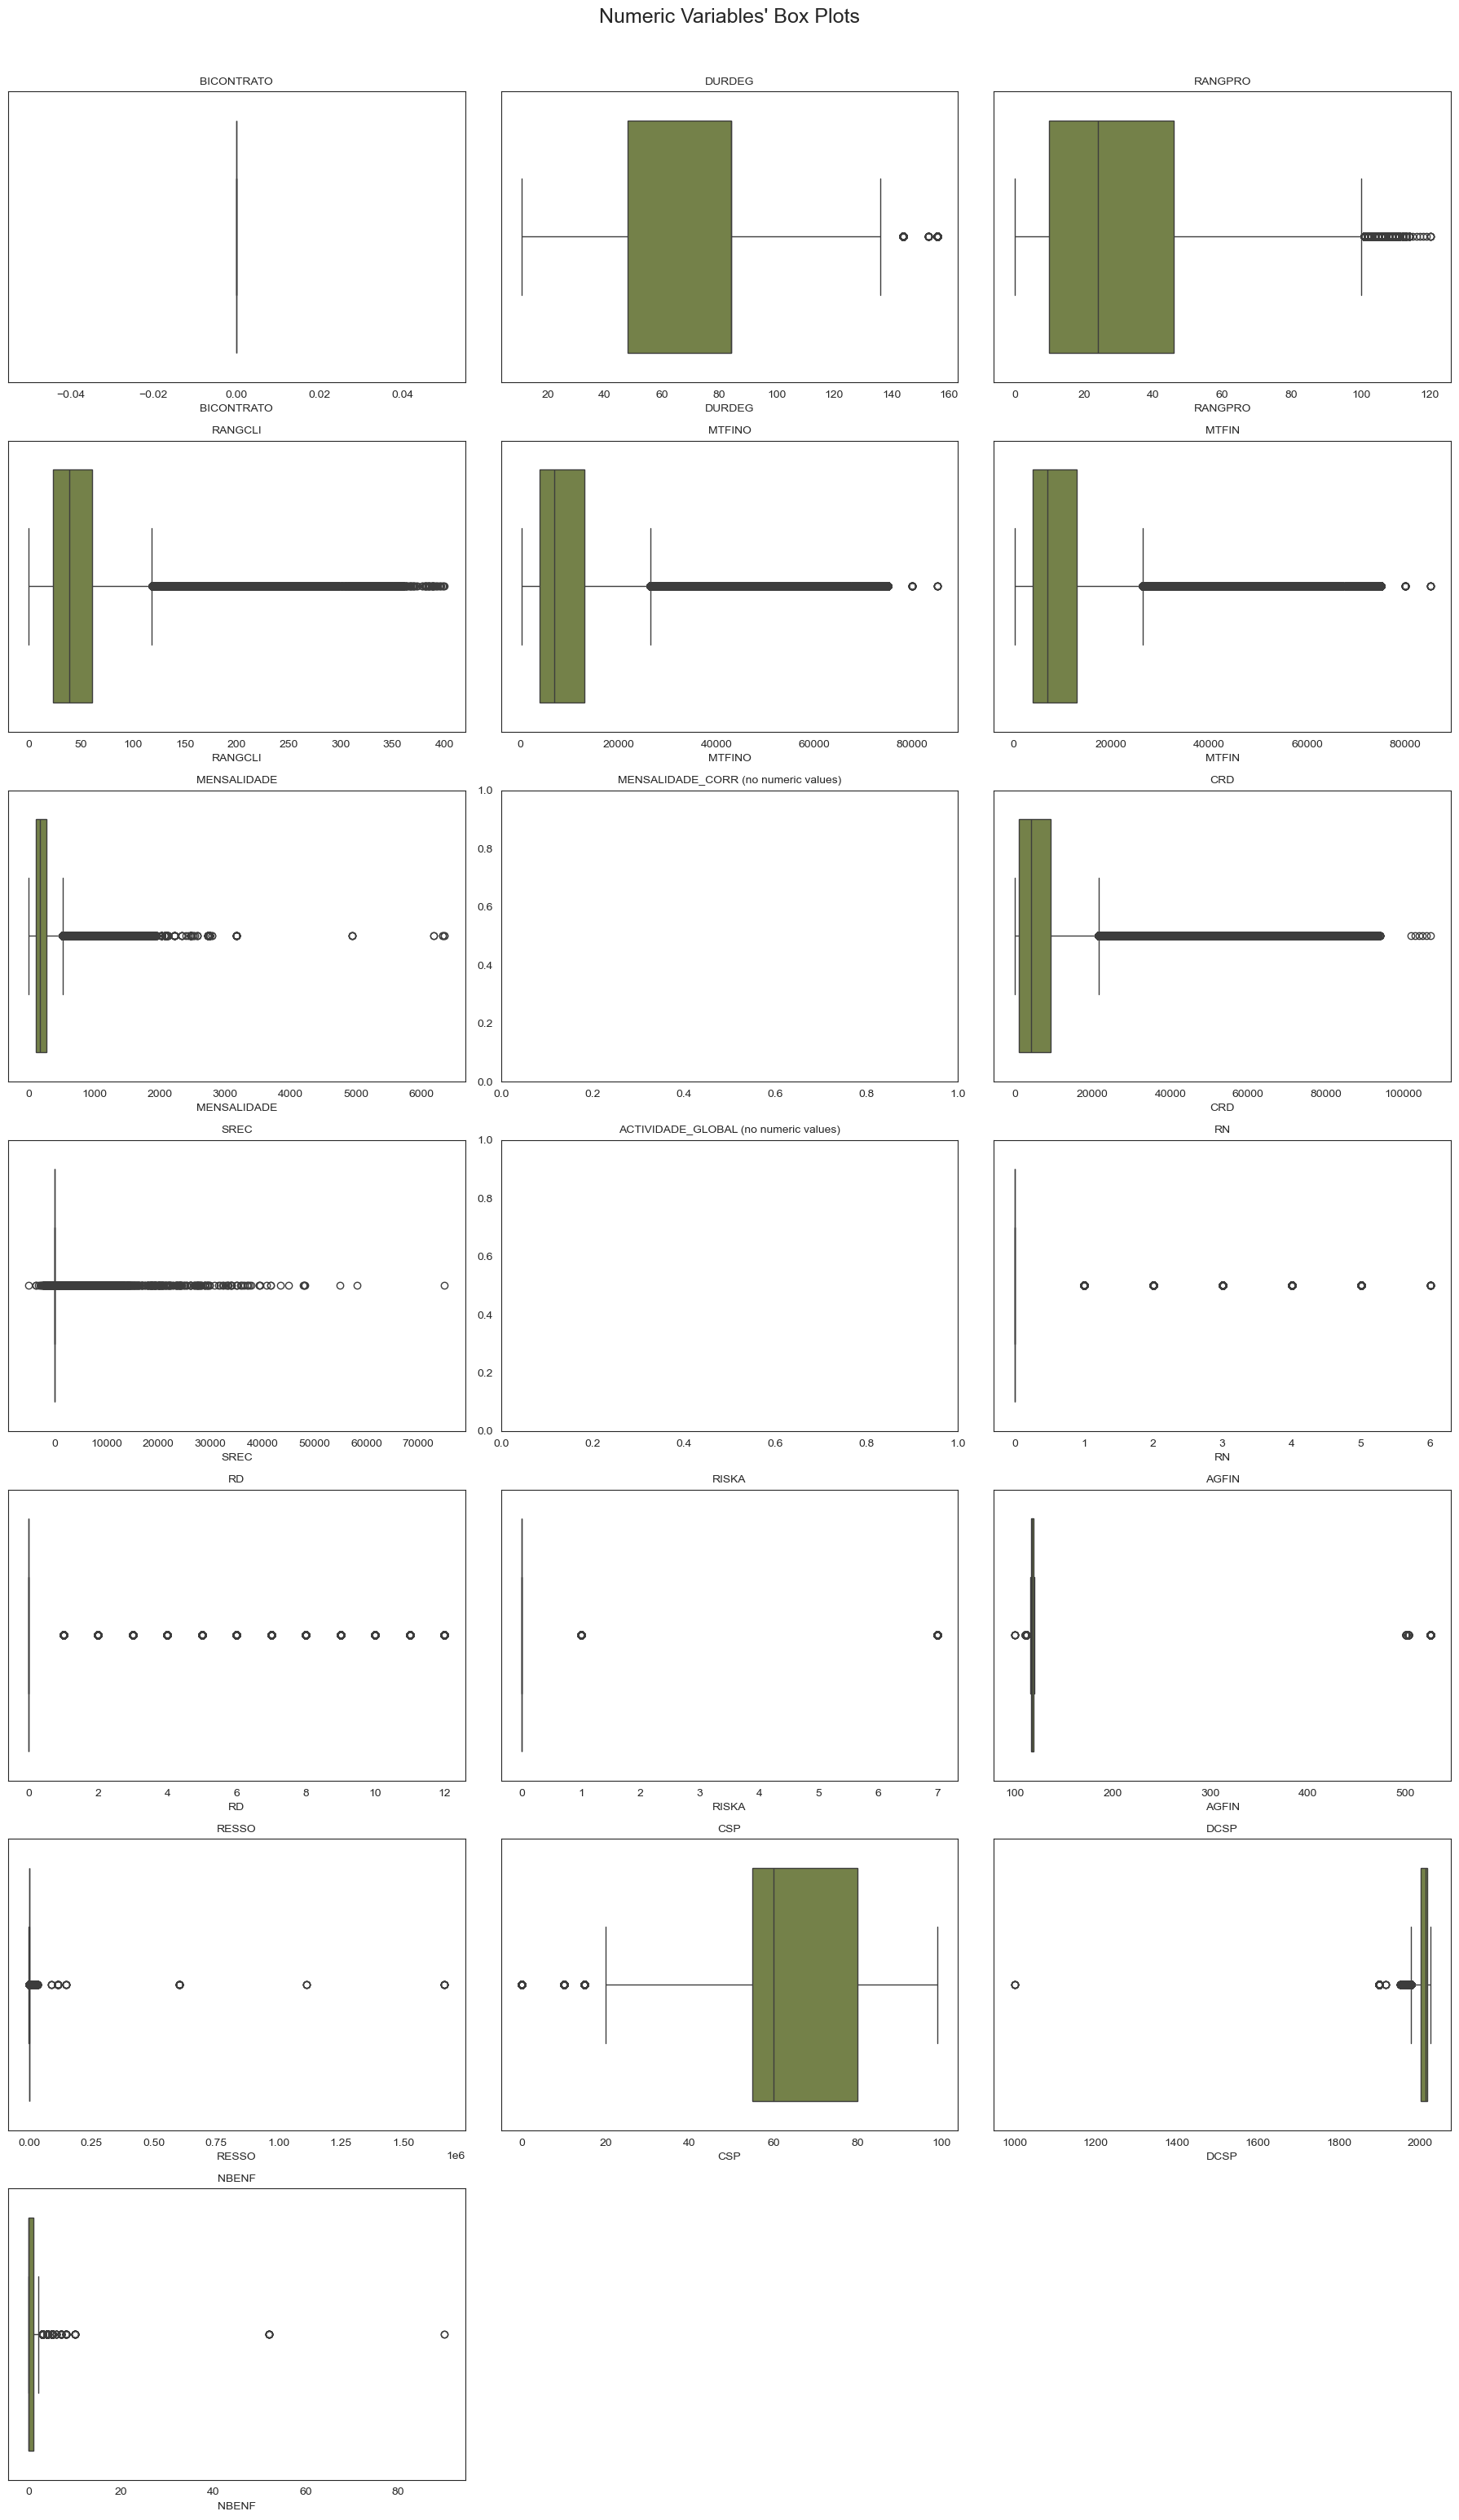

In [147]:
plot_multiple_boxplots(BDOSS, num_cols_DB)

In [148]:
#checking nº of observations where 'MTFINO'> 80000
BDOSS[BDOSS['MTFINO'] > 80000].count()

CONTRIB              6
DOSSIER              6
POLE                 6
TYPEPROD             6
PRODALP              6
BICONTRATO           6
POS                  6
OBS_DATE             6
DCREAT               6
DATFIN               6
D1FIN                6
DPOS                 6
DURDEG               6
RANGPRO              6
RANGCLI              6
MTFINO               6
MTFIN                6
MENSALIDADE          6
MENSALIDADE_CORR     0
CRD                  6
SREC                 6
ACTIVIDADE_GLOBAL    0
RN                   6
RD                   6
RISK                 6
RISKA                6
AGFIN                6
PAGAMENTO            6
RESSO                6
CSP                  6
DCSP                 6
NATIO                6
PTT                  6
NBENF                6
MODCONTACTO          6
dtype: int64

In [149]:
#checking nº of observations where 'MTFIN'> 80000
BDOSS[BDOSS['MTFIN'] > 80000].count()

CONTRIB              6
DOSSIER              6
POLE                 6
TYPEPROD             6
PRODALP              6
BICONTRATO           6
POS                  6
OBS_DATE             6
DCREAT               6
DATFIN               6
D1FIN                6
DPOS                 6
DURDEG               6
RANGPRO              6
RANGCLI              6
MTFINO               6
MTFIN                6
MENSALIDADE          6
MENSALIDADE_CORR     0
CRD                  6
SREC                 6
ACTIVIDADE_GLOBAL    0
RN                   6
RD                   6
RISK                 6
RISKA                6
AGFIN                6
PAGAMENTO            6
RESSO                6
CSP                  6
DCSP                 6
NATIO                6
PTT                  6
NBENF                6
MODCONTACTO          6
dtype: int64

In [150]:
#checking nº of observations where 'MENSALIDADE'> 4000
BDOSS[BDOSS['MENSALIDADE'] > 4000].count()

CONTRIB              10
DOSSIER              10
POLE                 10
TYPEPROD             10
PRODALP              10
BICONTRATO           10
POS                  10
OBS_DATE             10
DCREAT               10
DATFIN               10
D1FIN                10
DPOS                 10
DURDEG               10
RANGPRO              10
RANGCLI              10
MTFINO               10
MTFIN                10
MENSALIDADE          10
MENSALIDADE_CORR      0
CRD                  10
SREC                 10
ACTIVIDADE_GLOBAL     0
RN                   10
RD                   10
RISK                 10
RISKA                10
AGFIN                10
PAGAMENTO            10
RESSO                10
CSP                  10
DCSP                 10
NATIO                10
PTT                  10
NBENF                10
MODCONTACTO          10
dtype: int64

In [151]:
#checking nº of observations where 'CRD'> 100000
BDOSS[BDOSS['CRD'] > 100000].count()

CONTRIB              6
DOSSIER              6
POLE                 6
TYPEPROD             6
PRODALP              6
BICONTRATO           6
POS                  6
OBS_DATE             6
DCREAT               6
DATFIN               6
D1FIN                6
DPOS                 6
DURDEG               6
RANGPRO              6
RANGCLI              6
MTFINO               6
MTFIN                6
MENSALIDADE          6
MENSALIDADE_CORR     0
CRD                  6
SREC                 6
ACTIVIDADE_GLOBAL    0
RN                   6
RD                   6
RISK                 6
RISKA                6
AGFIN                6
PAGAMENTO            6
RESSO                6
CSP                  6
DCSP                 6
NATIO                6
PTT                  6
NBENF                6
MODCONTACTO          6
dtype: int64

In [152]:
#checking nº of observations where 'SREC'> 40000
BDOSS[BDOSS['SREC'] > 40000].count()

CONTRIB              12
DOSSIER              12
POLE                 12
TYPEPROD             12
PRODALP              12
BICONTRATO           12
POS                  12
OBS_DATE             12
DCREAT               12
DATFIN               12
D1FIN                12
DPOS                 12
DURDEG               12
RANGPRO              12
RANGCLI              12
MTFINO               12
MTFIN                12
MENSALIDADE          12
MENSALIDADE_CORR      0
CRD                  12
SREC                 12
ACTIVIDADE_GLOBAL     0
RN                   12
RD                   12
RISK                 12
RISKA                12
AGFIN                12
PAGAMENTO            12
RESSO                12
CSP                  12
DCSP                 10
NATIO                12
PTT                  12
NBENF                12
MODCONTACTO          12
dtype: int64

In [153]:
#checking nº of observations where 'RESSO'> 700000
BDOSS[BDOSS['RESSO'] > 700000].count()

CONTRIB              12
DOSSIER              12
POLE                 12
TYPEPROD             12
PRODALP              12
BICONTRATO           12
POS                  12
OBS_DATE             12
DCREAT               12
DATFIN               12
D1FIN                12
DPOS                 12
DURDEG               12
RANGPRO              12
RANGCLI              12
MTFINO               12
MTFIN                12
MENSALIDADE          12
MENSALIDADE_CORR      0
CRD                  12
SREC                 12
ACTIVIDADE_GLOBAL     0
RN                   12
RD                   12
RISK                 12
RISKA                12
AGFIN                12
PAGAMENTO            12
RESSO                12
CSP                  12
DCSP                  8
NATIO                12
PTT                  12
NBENF                12
MODCONTACTO          12
dtype: int64

In [154]:
#checking nº of observations where 'NBENF'> 10
BDOSS[BDOSS['NBENF'] > 10].count()

CONTRIB              10
DOSSIER              10
POLE                 10
TYPEPROD             10
PRODALP              10
BICONTRATO           10
POS                  10
OBS_DATE             10
DCREAT               10
DATFIN               10
D1FIN                10
DPOS                 10
DURDEG               10
RANGPRO              10
RANGCLI              10
MTFINO               10
MTFIN                10
MENSALIDADE          10
MENSALIDADE_CORR      0
CRD                  10
SREC                 10
ACTIVIDADE_GLOBAL     0
RN                   10
RD                   10
RISK                 10
RISKA                10
AGFIN                10
PAGAMENTO            10
RESSO                10
CSP                  10
DCSP                 10
NATIO                10
PTT                  10
NBENF                10
MODCONTACTO          10
dtype: int64

### 3.5. Checking Distributions

#### 3.5.1. Numerical Variables

In [155]:
df= pd.DataFrame(BDOSS[num_cols_DB])

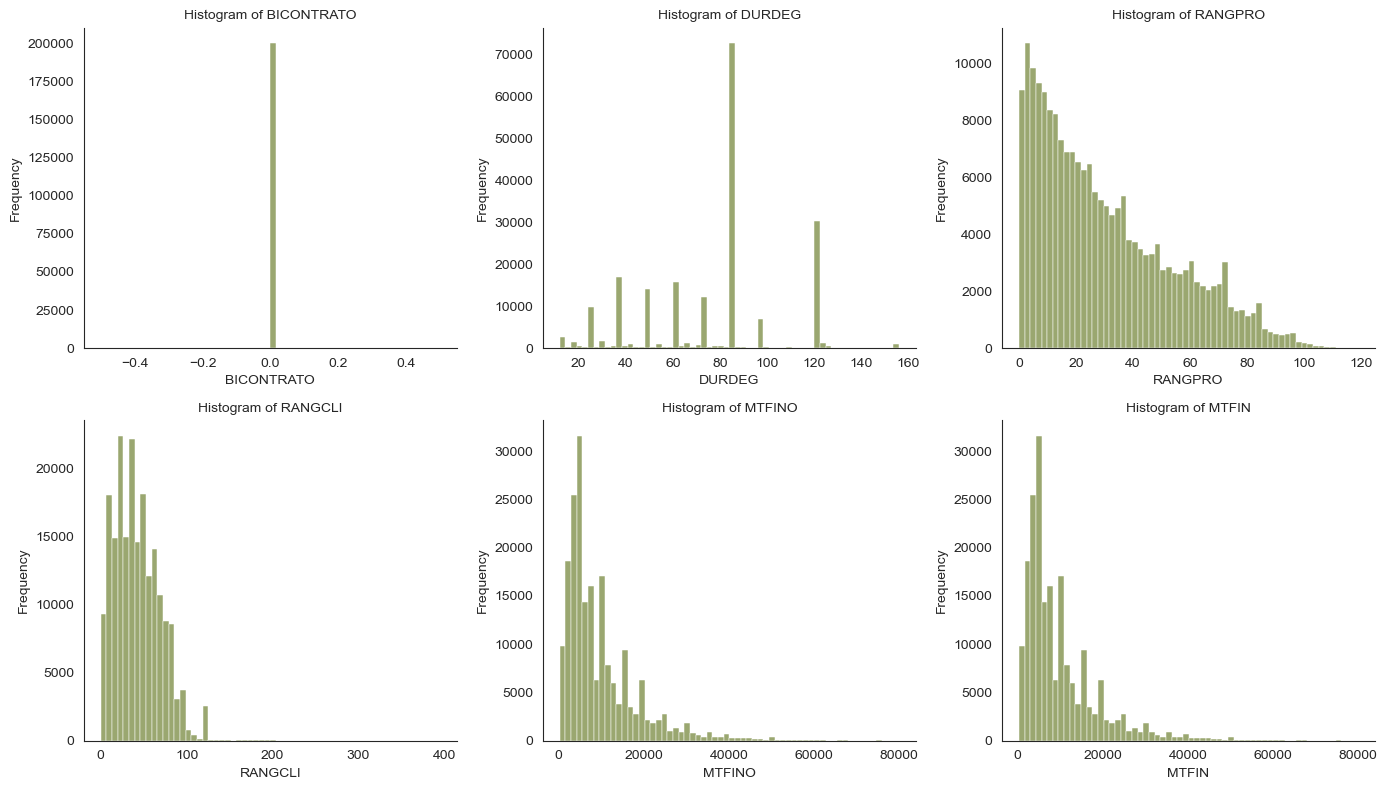

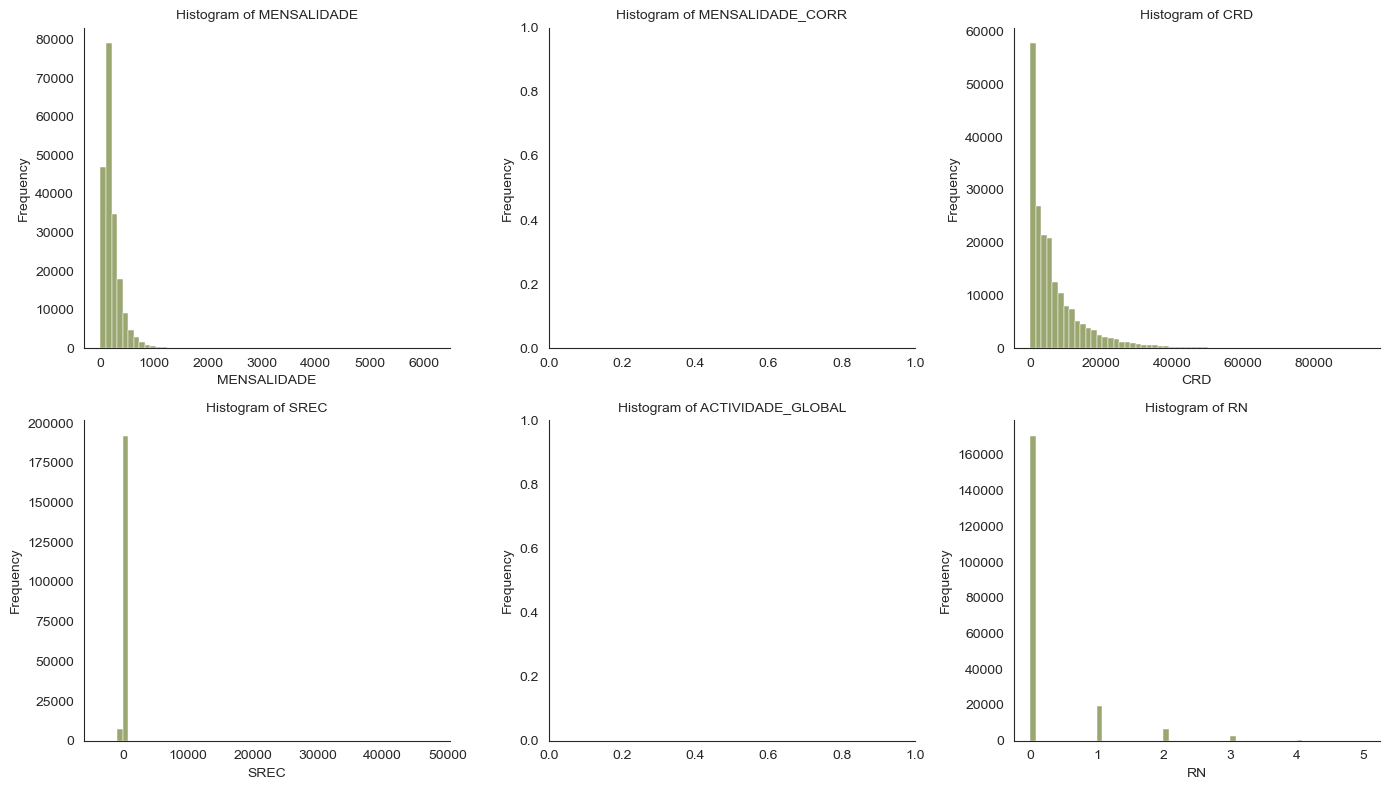

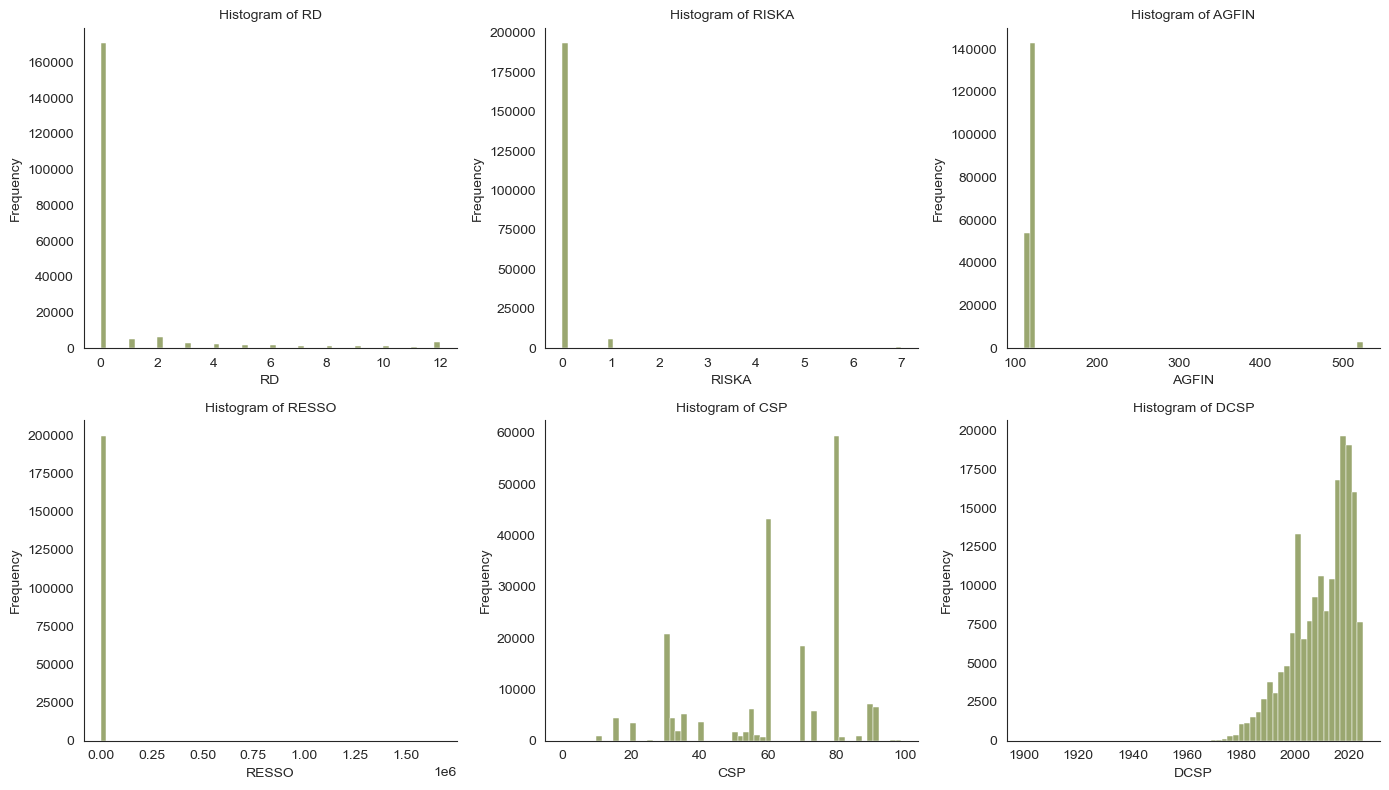

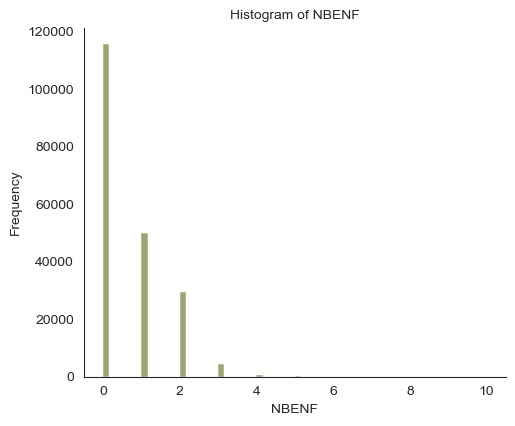

In [156]:
plot_numeric_histograms(BDOSS, num_cols_DB)

#### 3.5.2. Categorical Variables

In [157]:
#setting numerical and categorical variables
num_cols_DB = BDOSS.select_dtypes(include=['number']).columns
obj_cols_DB = BDOSS.select_dtypes(include=['object']).columns

print("Numerical:", len(num_cols_DB))
print("Categorical:", len(obj_cols_DB))

Numerical: 19
Categorical: 11


In [158]:
BDOSS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658187 entries, 0 to 2658186
Data columns (total 35 columns):
 #   Column             Dtype         
---  ------             -----         
 0   CONTRIB            object        
 1   DOSSIER            object        
 2   POLE               object        
 3   TYPEPROD           object        
 4   PRODALP            object        
 5   BICONTRATO         float64       
 6   POS                object        
 7   OBS_DATE           datetime64[ns]
 8   DCREAT             datetime64[ns]
 9   DATFIN             datetime64[ns]
 10  D1FIN              datetime64[ns]
 11  DPOS               datetime64[ns]
 12  DURDEG             float64       
 13  RANGPRO            float64       
 14  RANGCLI            float64       
 15  MTFINO             float64       
 16  MTFIN              float64       
 17  MENSALIDADE        float64       
 18  MENSALIDADE_CORR   float64       
 19  CRD                float64       
 20  SREC               float

In [159]:
non_numerical_features= ['MODCONTACTO', 'NATIO', 'DCSP', 'CSP', 'PAGAMENTO', 'POLE', 'TYPEPROD', 'PRODALP']

C:\Users\alano\AppData\Local\Temp\ipykernel_16168\1061526881.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


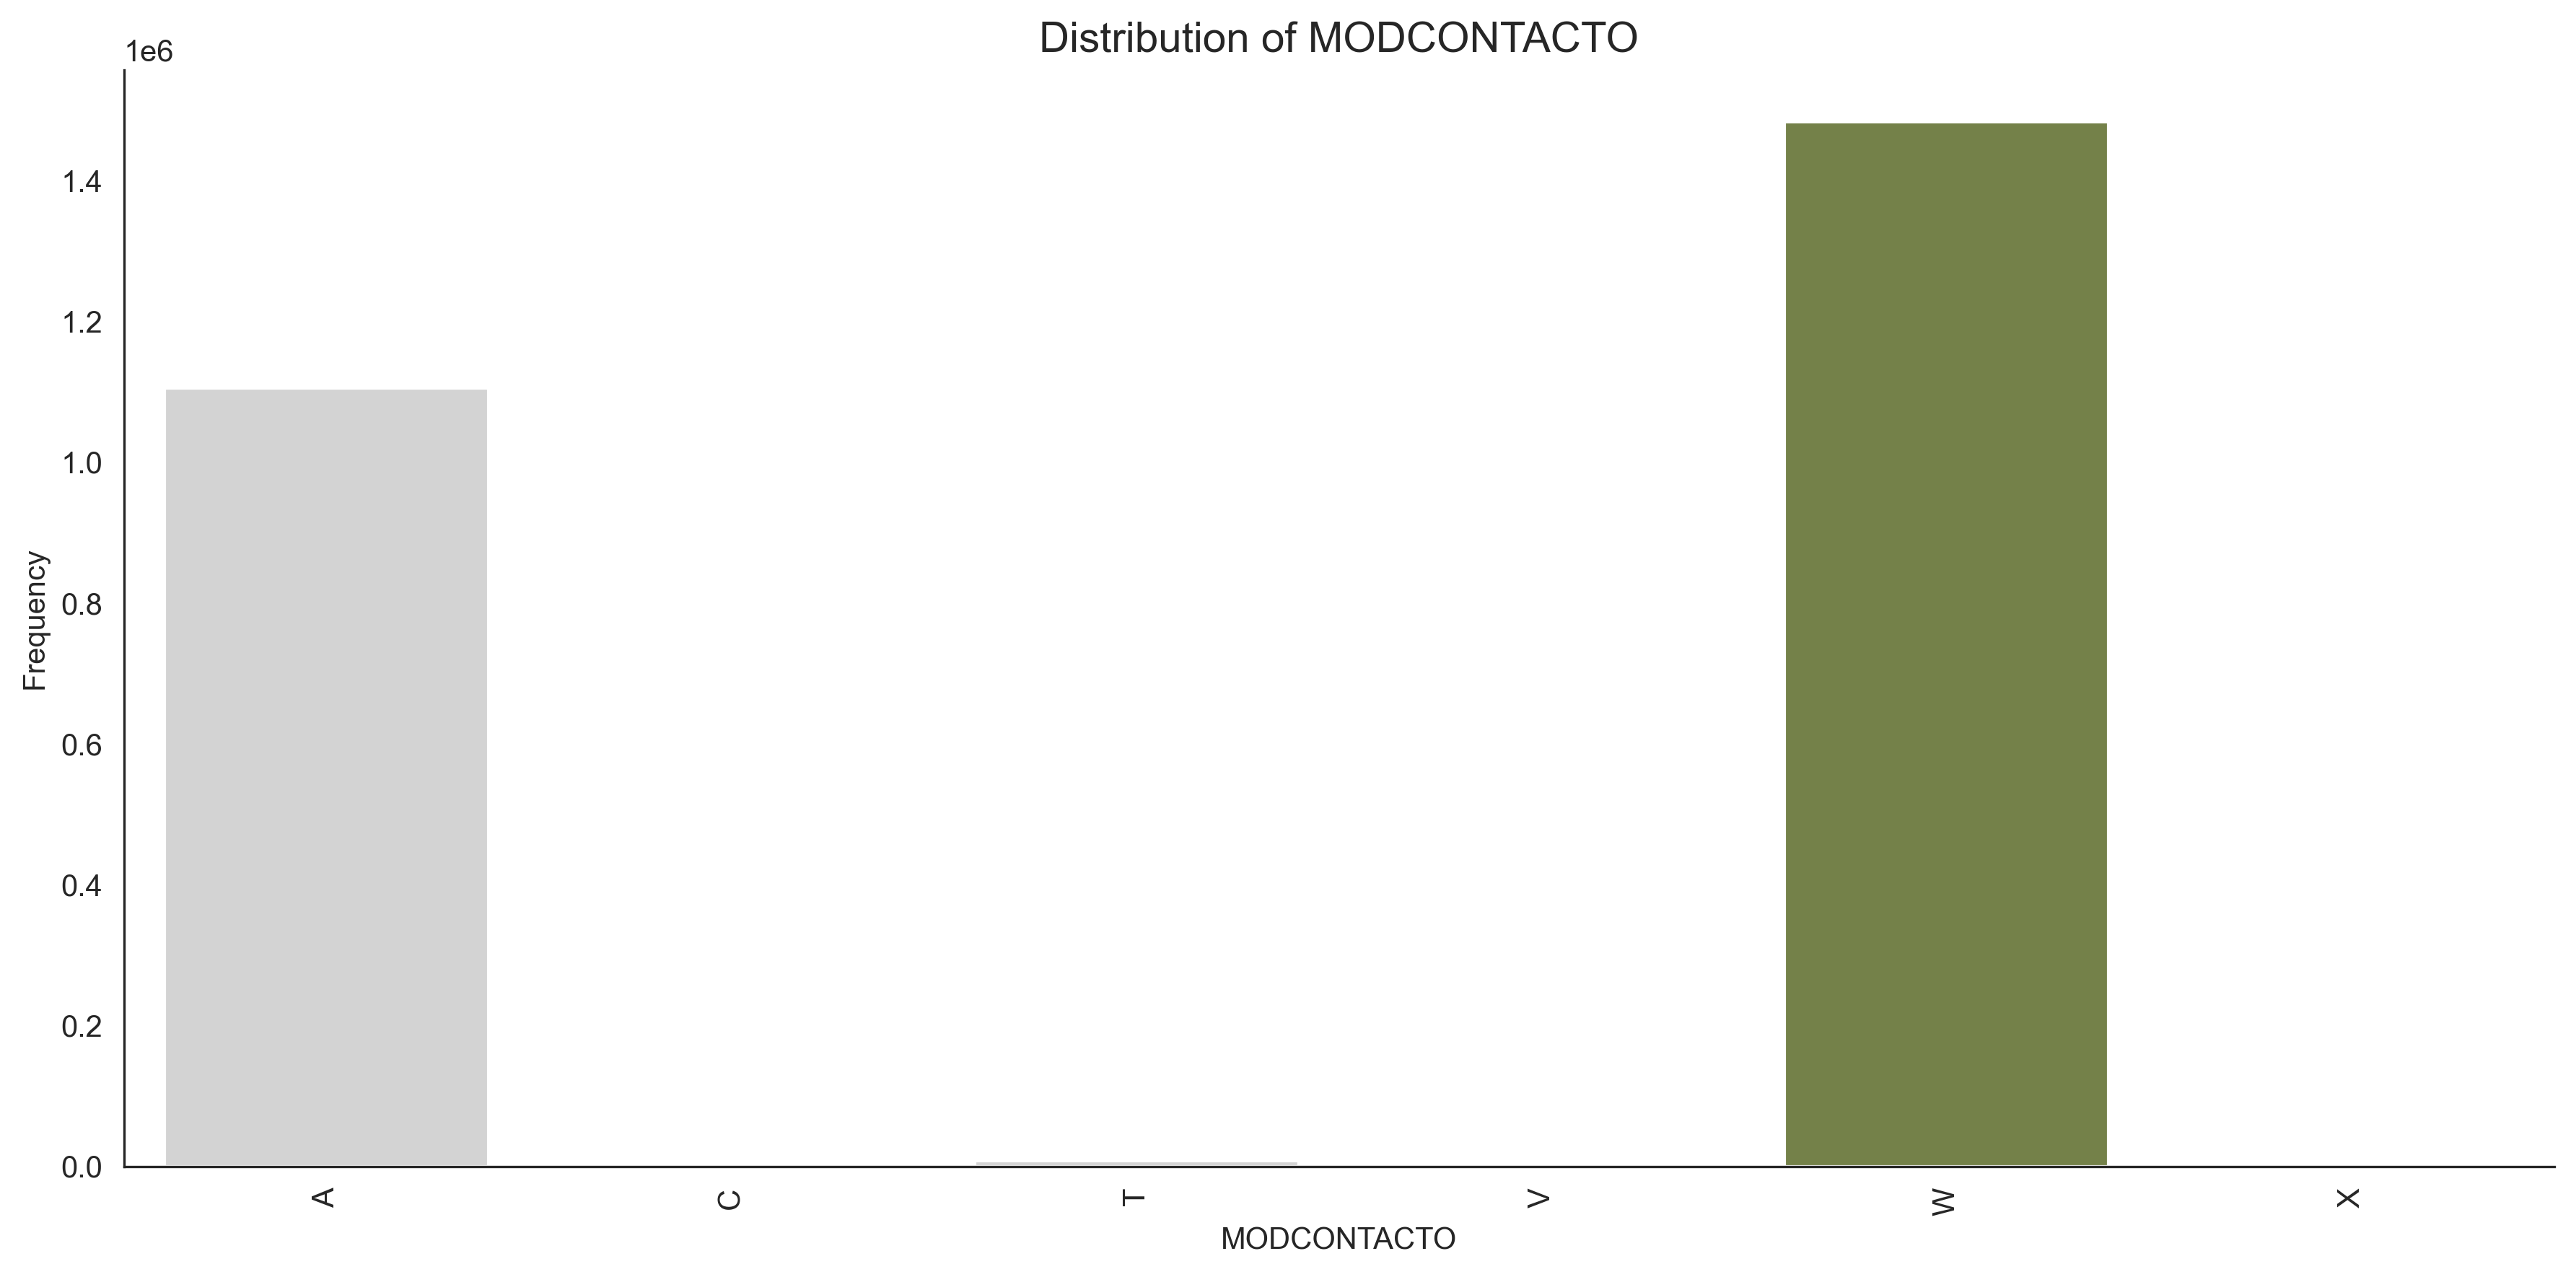

C:\Users\alano\AppData\Local\Temp\ipykernel_16168\1061526881.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


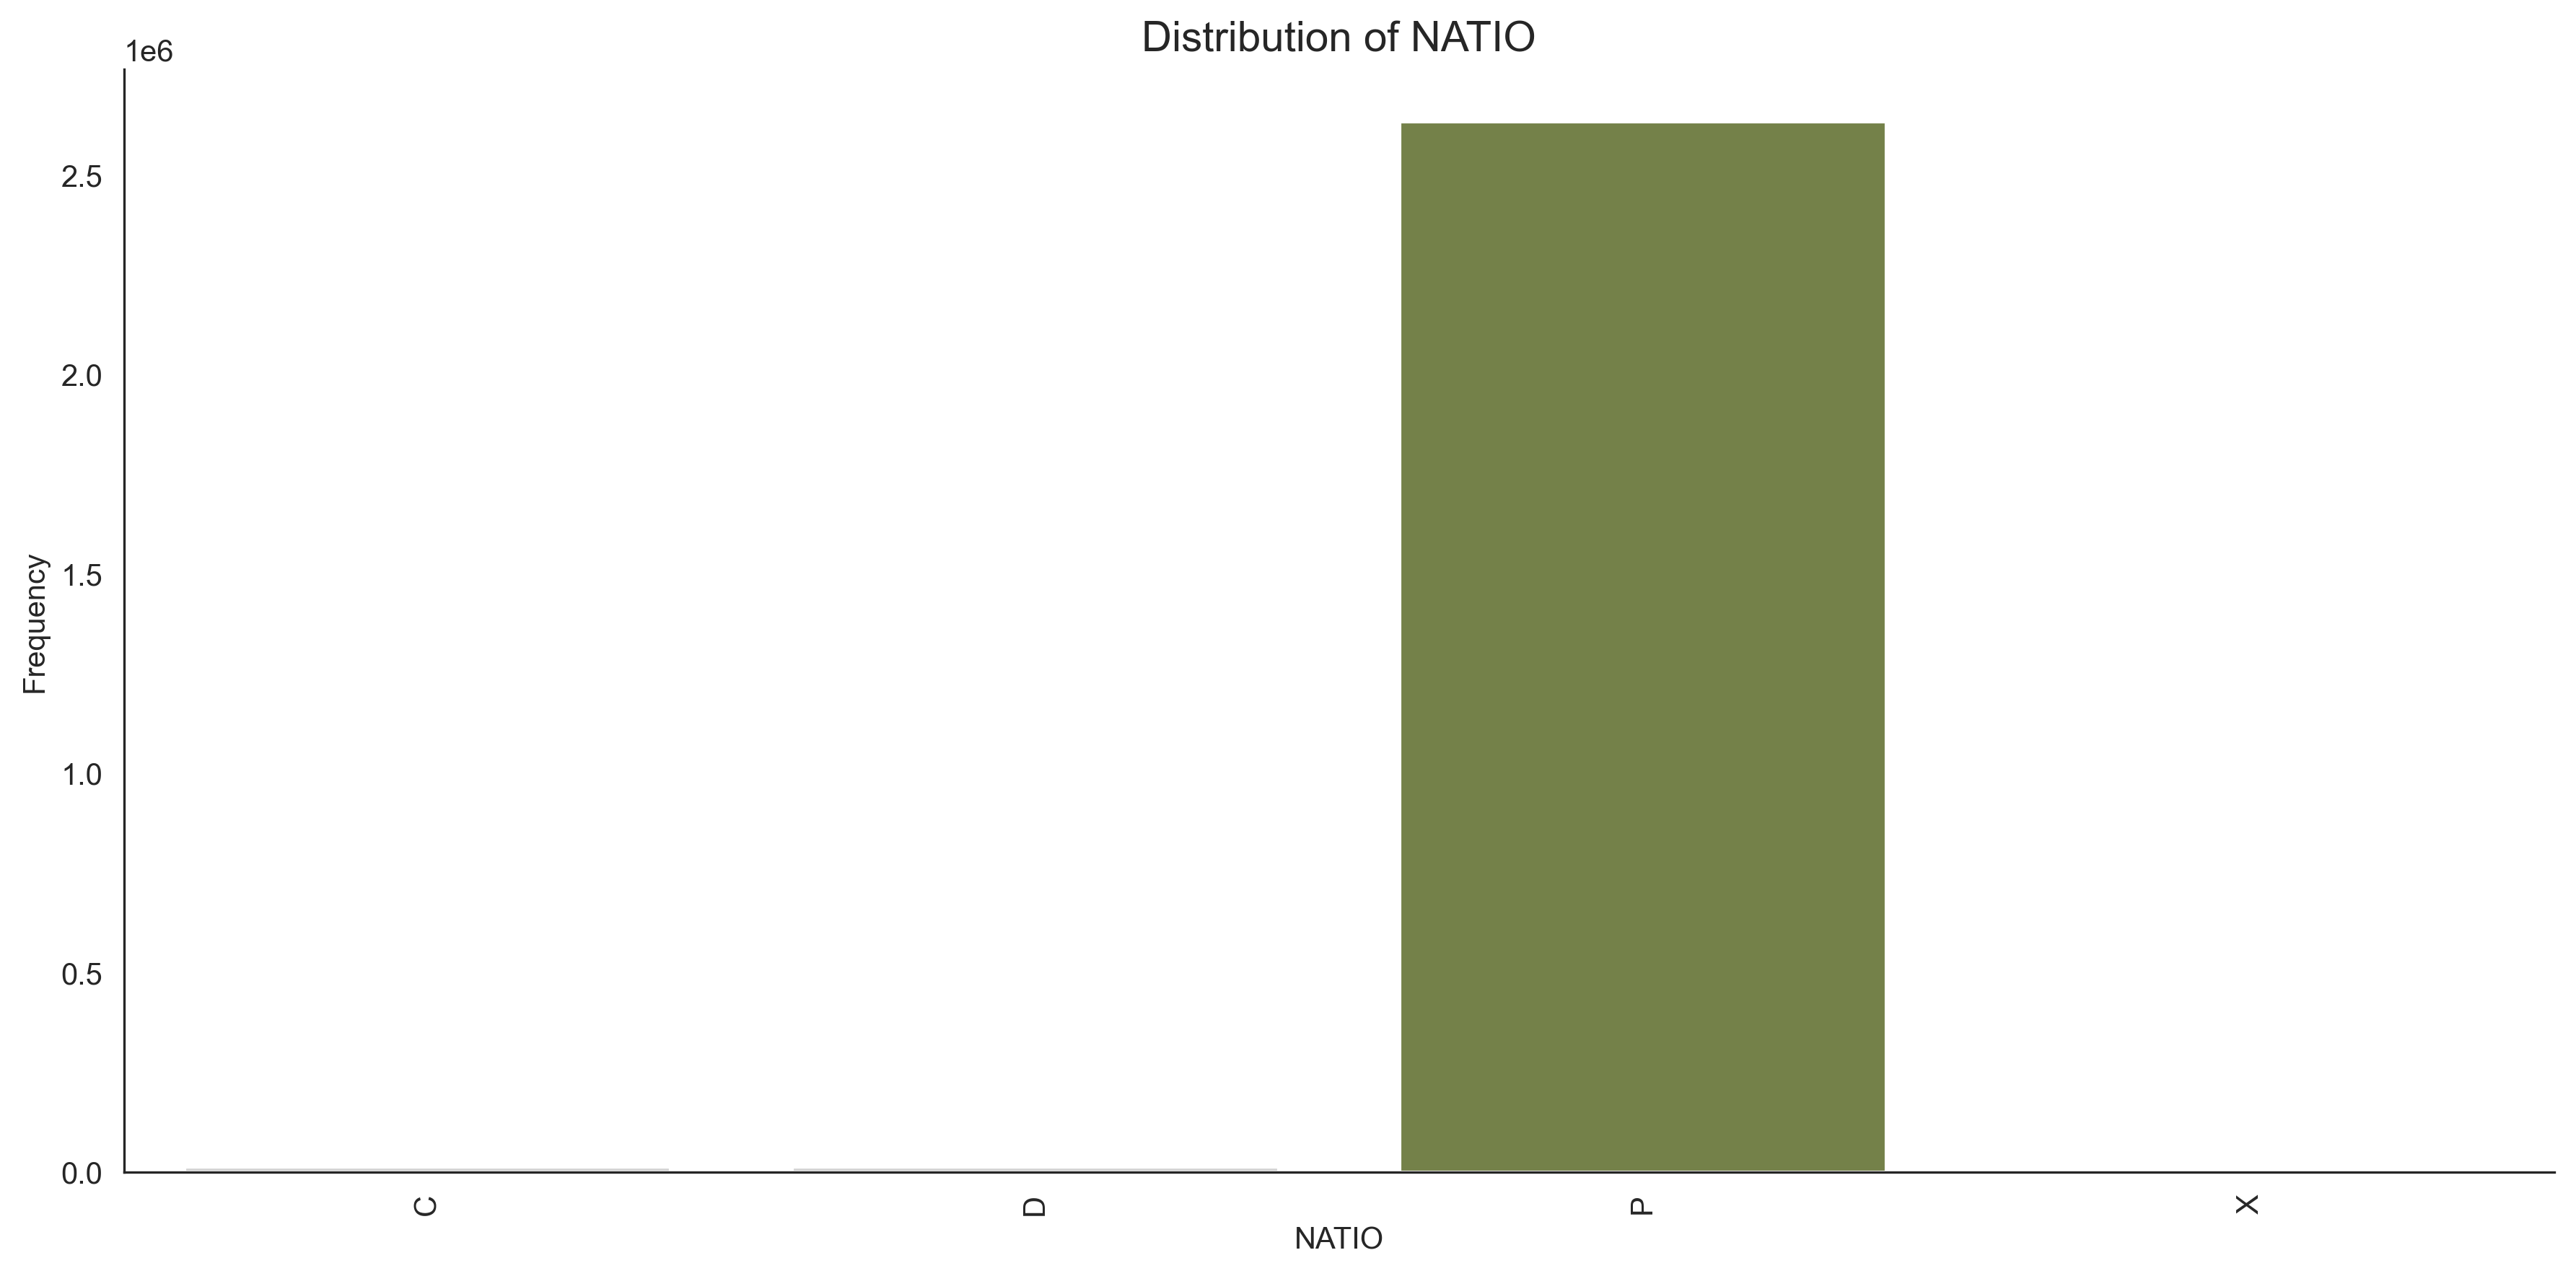

C:\Users\alano\AppData\Local\Temp\ipykernel_16168\1061526881.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


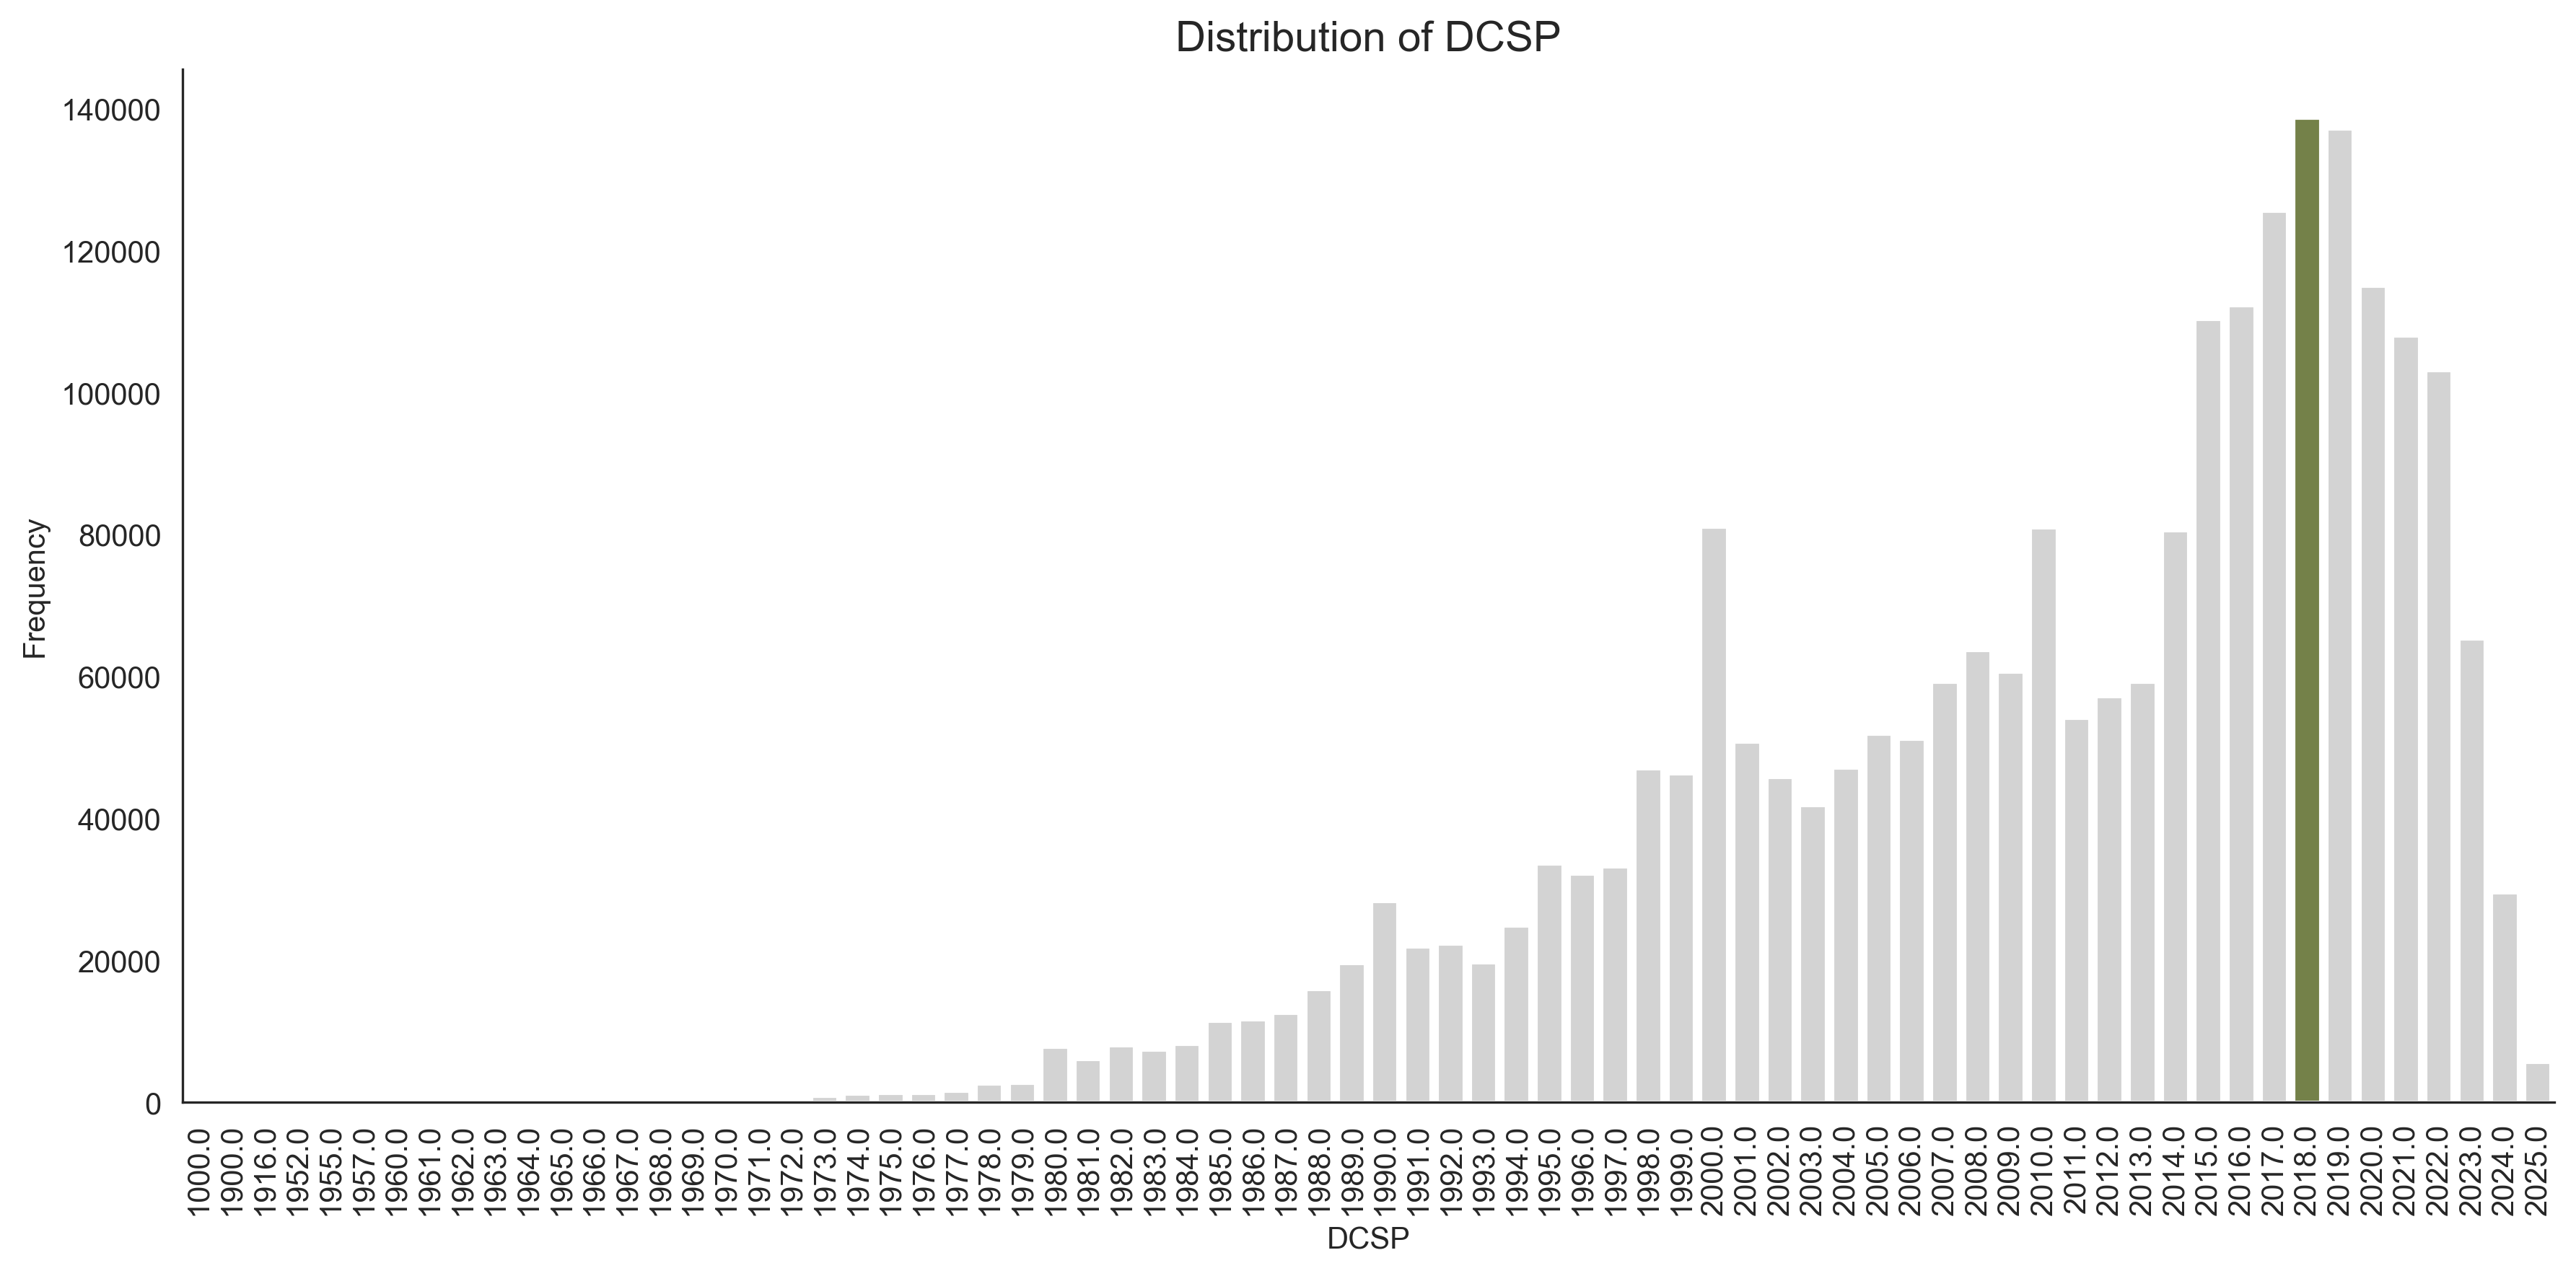

C:\Users\alano\AppData\Local\Temp\ipykernel_16168\1061526881.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


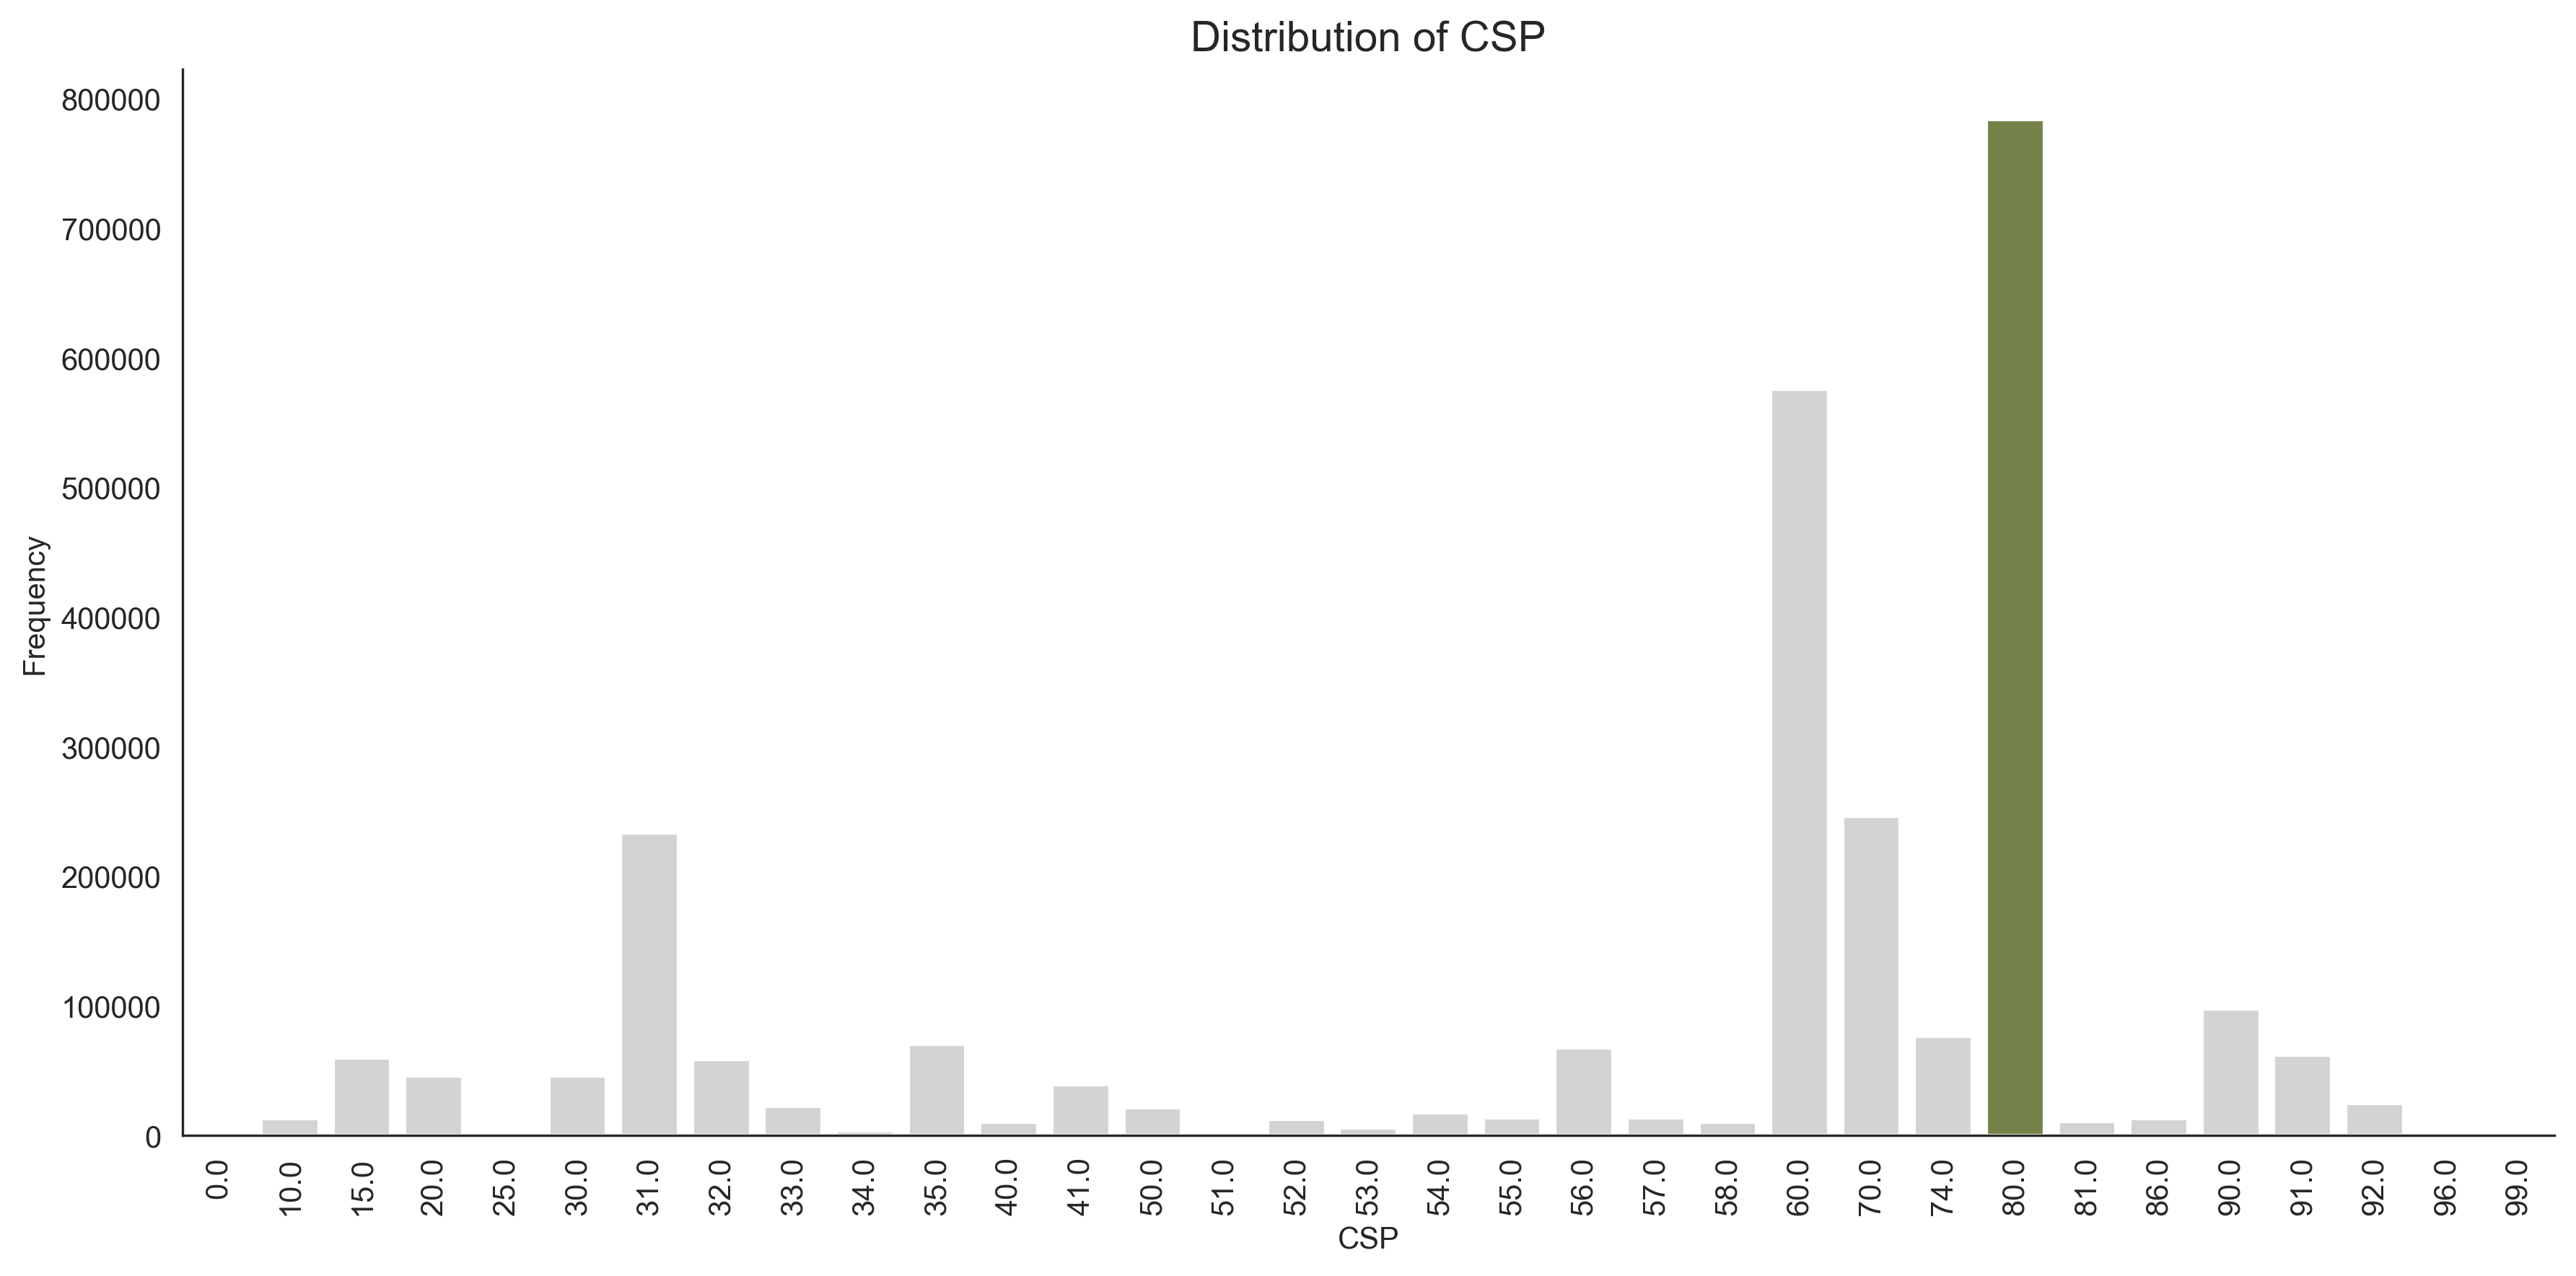

C:\Users\alano\AppData\Local\Temp\ipykernel_16168\1061526881.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


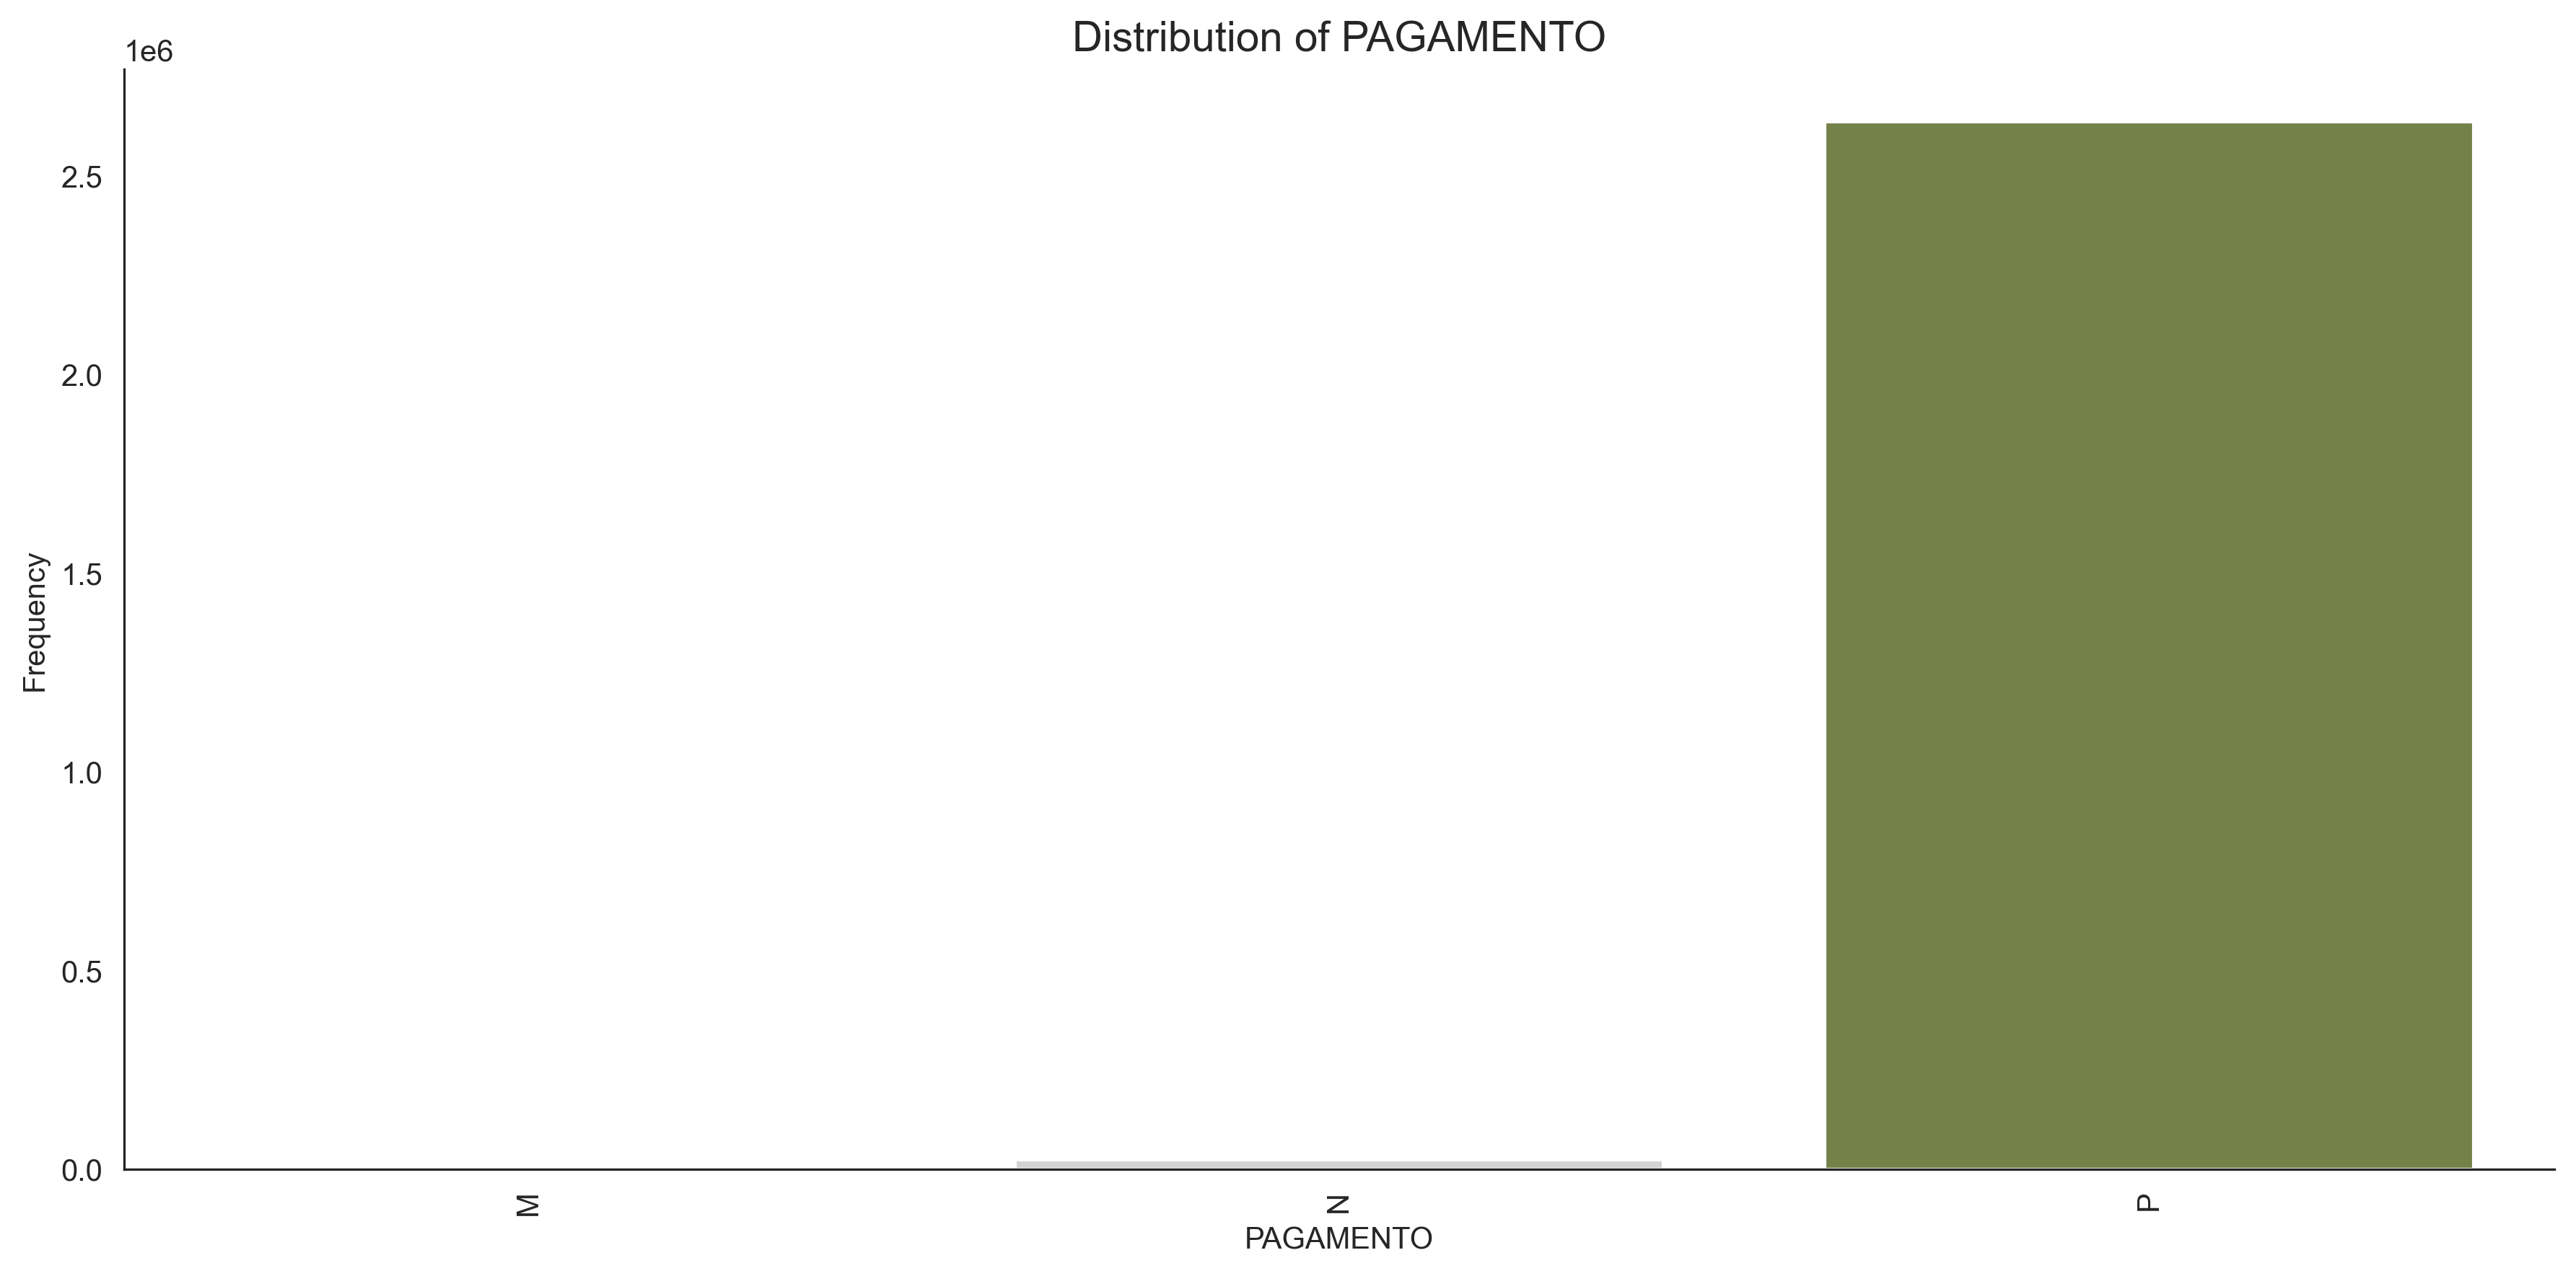

C:\Users\alano\AppData\Local\Temp\ipykernel_16168\1061526881.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


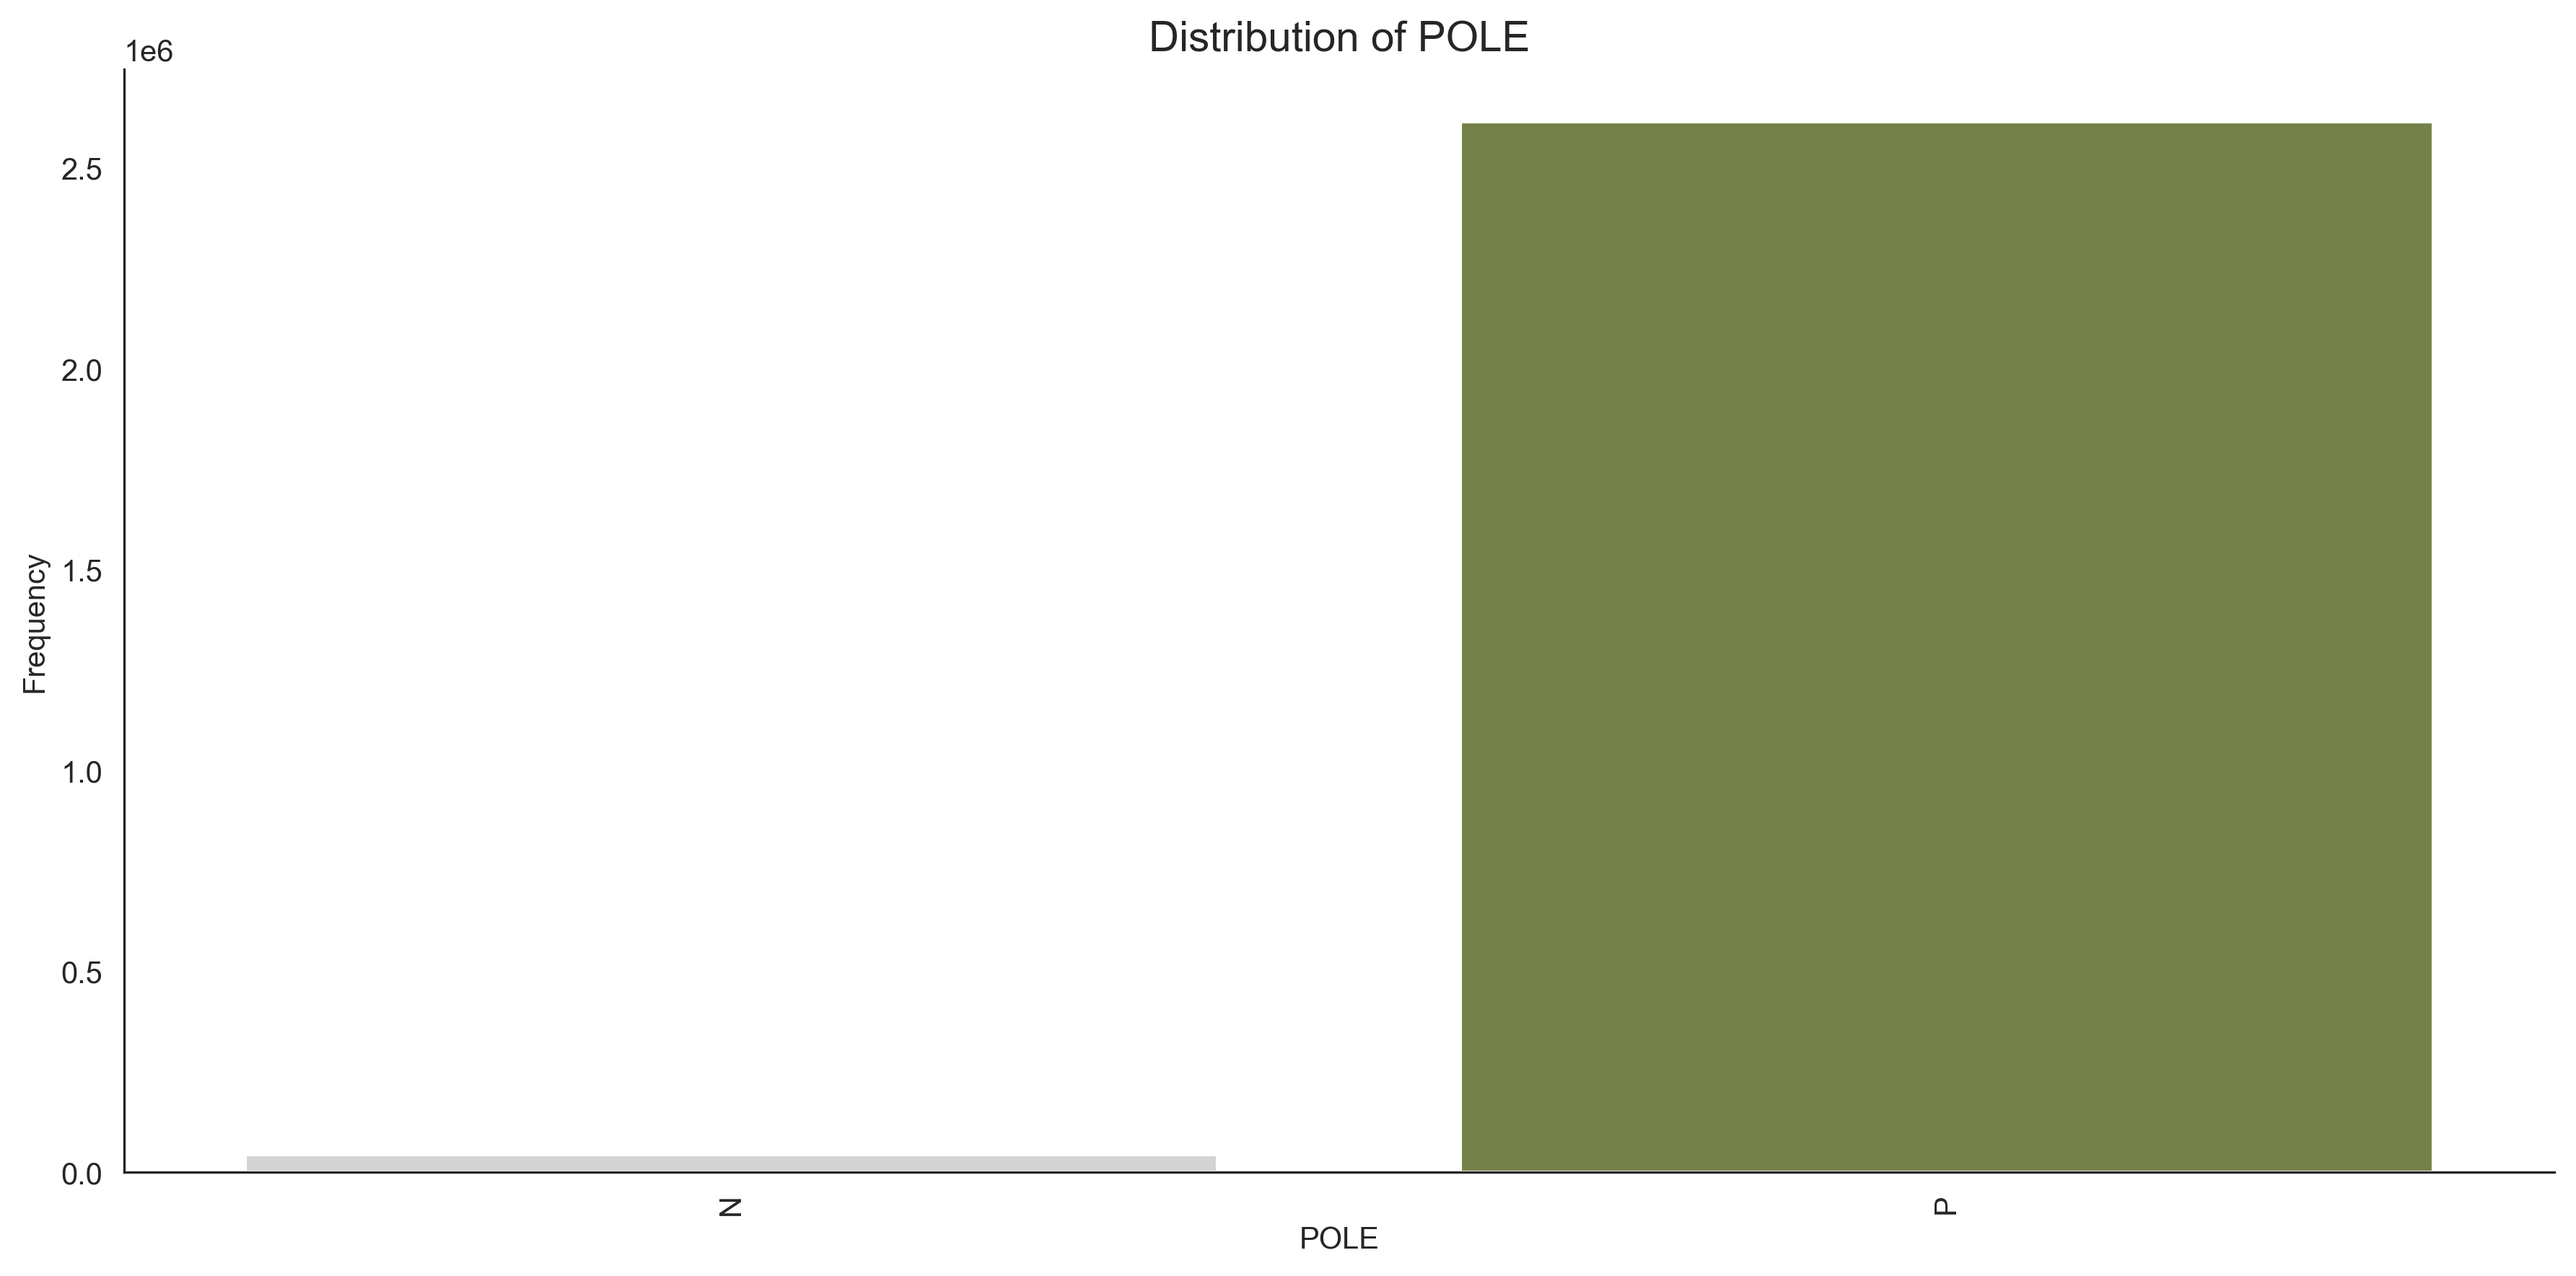

C:\Users\alano\AppData\Local\Temp\ipykernel_16168\1061526881.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


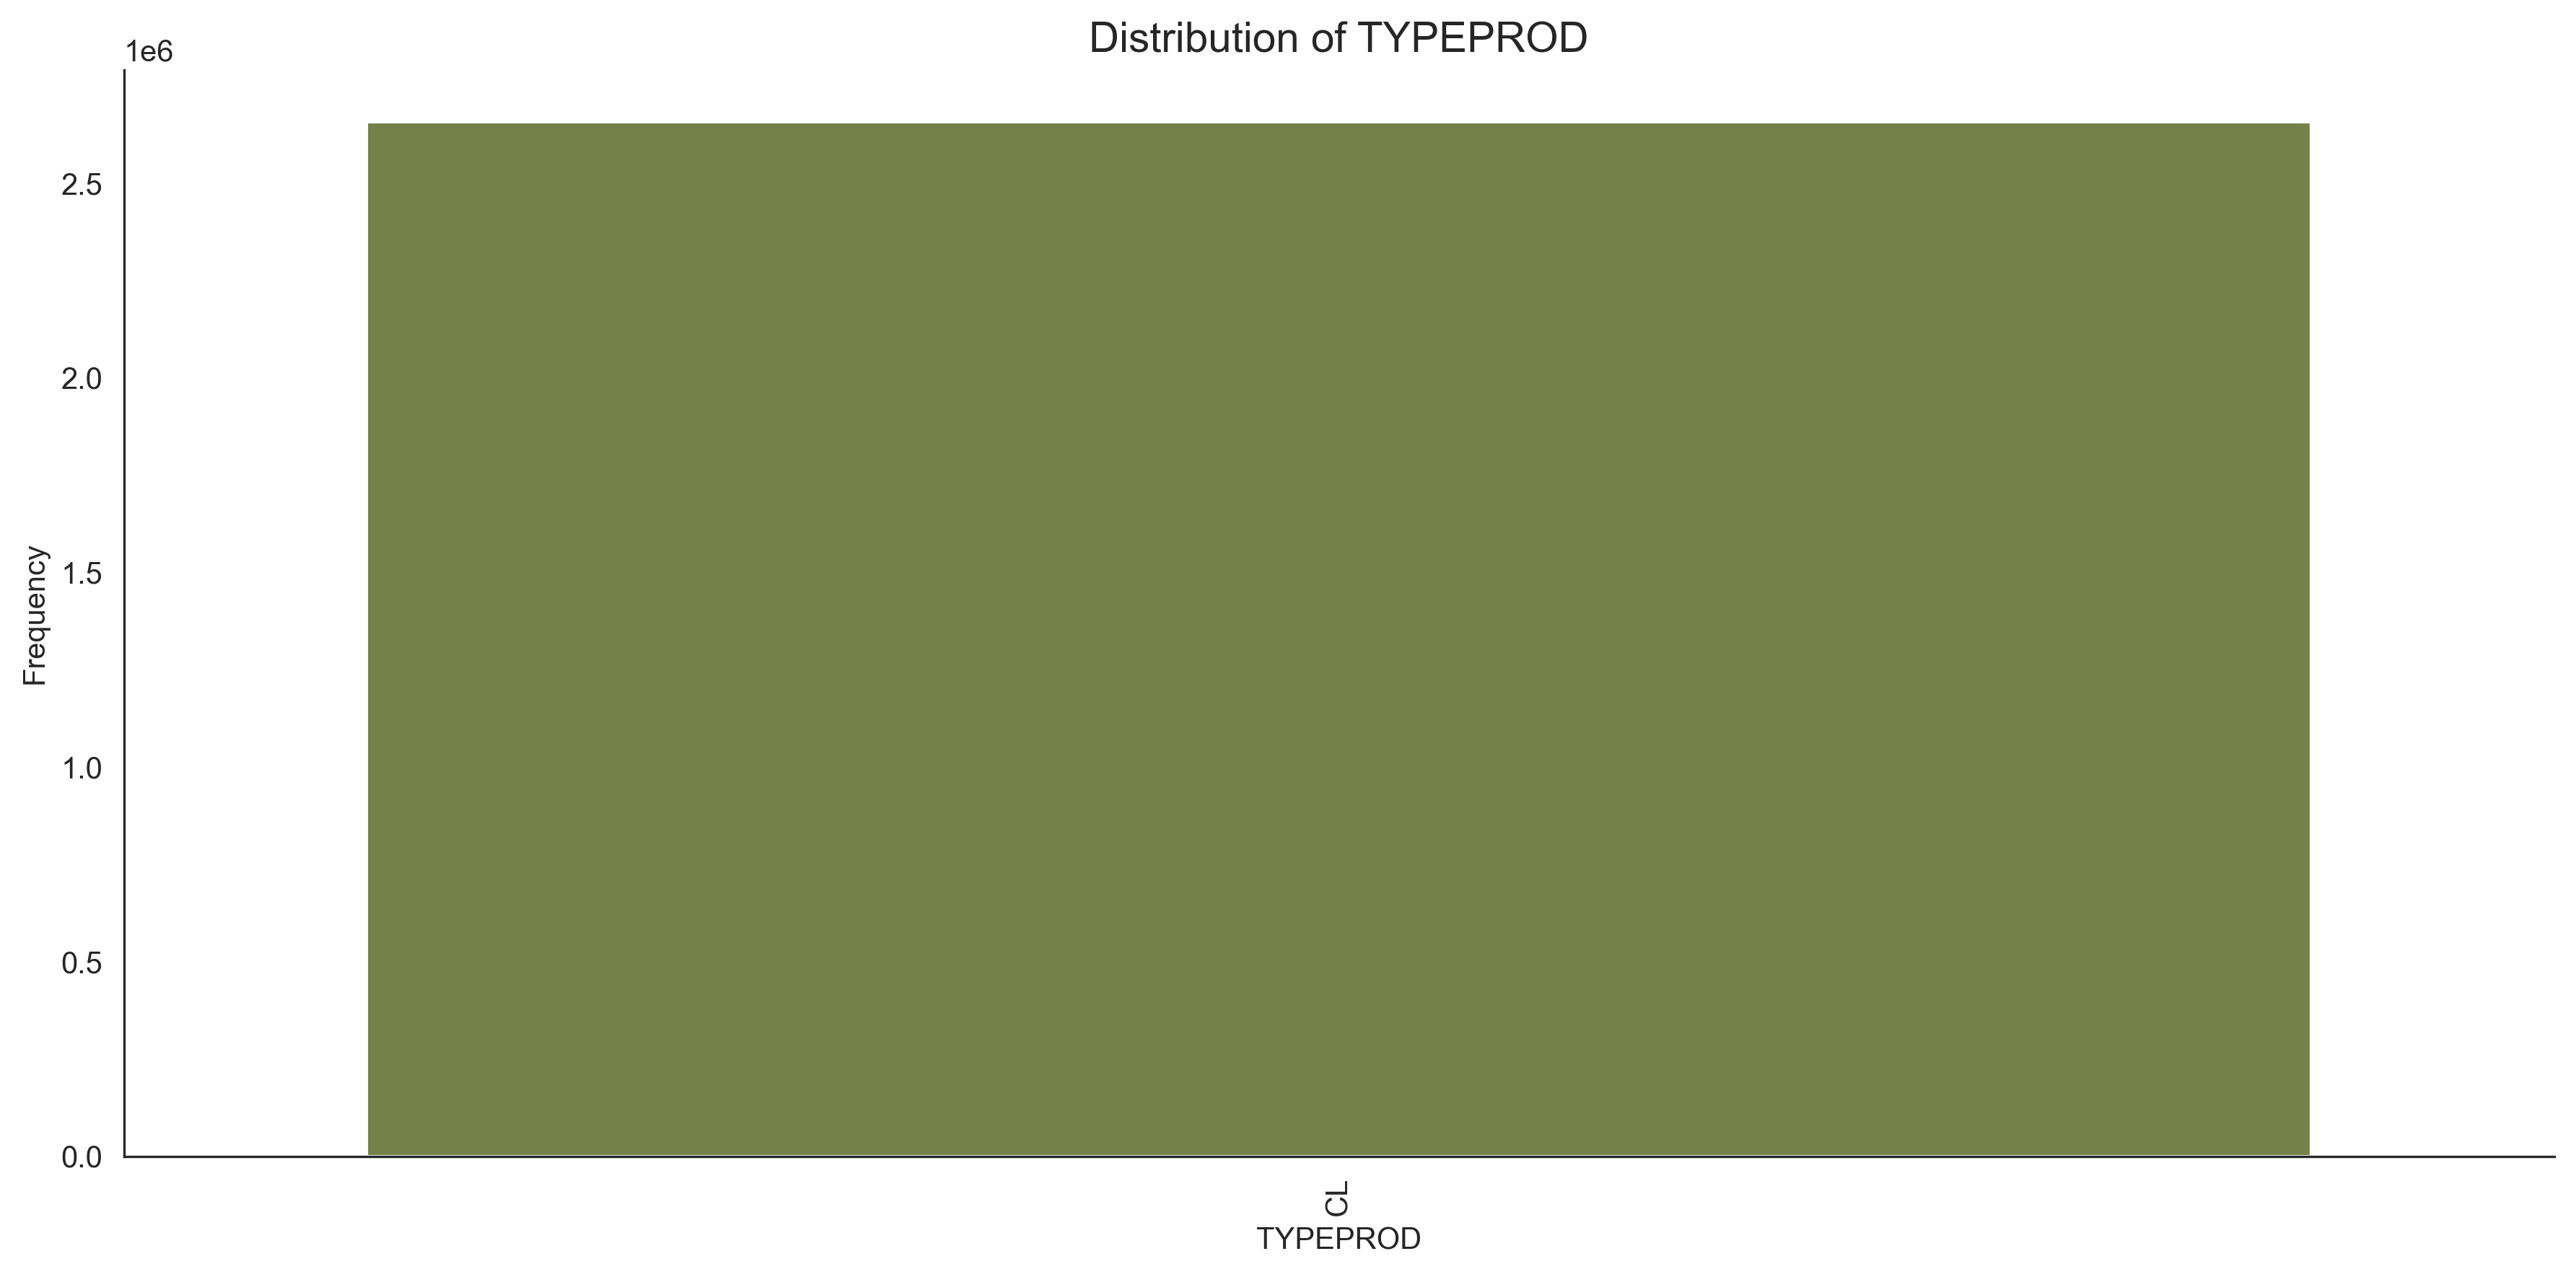

C:\Users\alano\AppData\Local\Temp\ipykernel_16168\1061526881.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


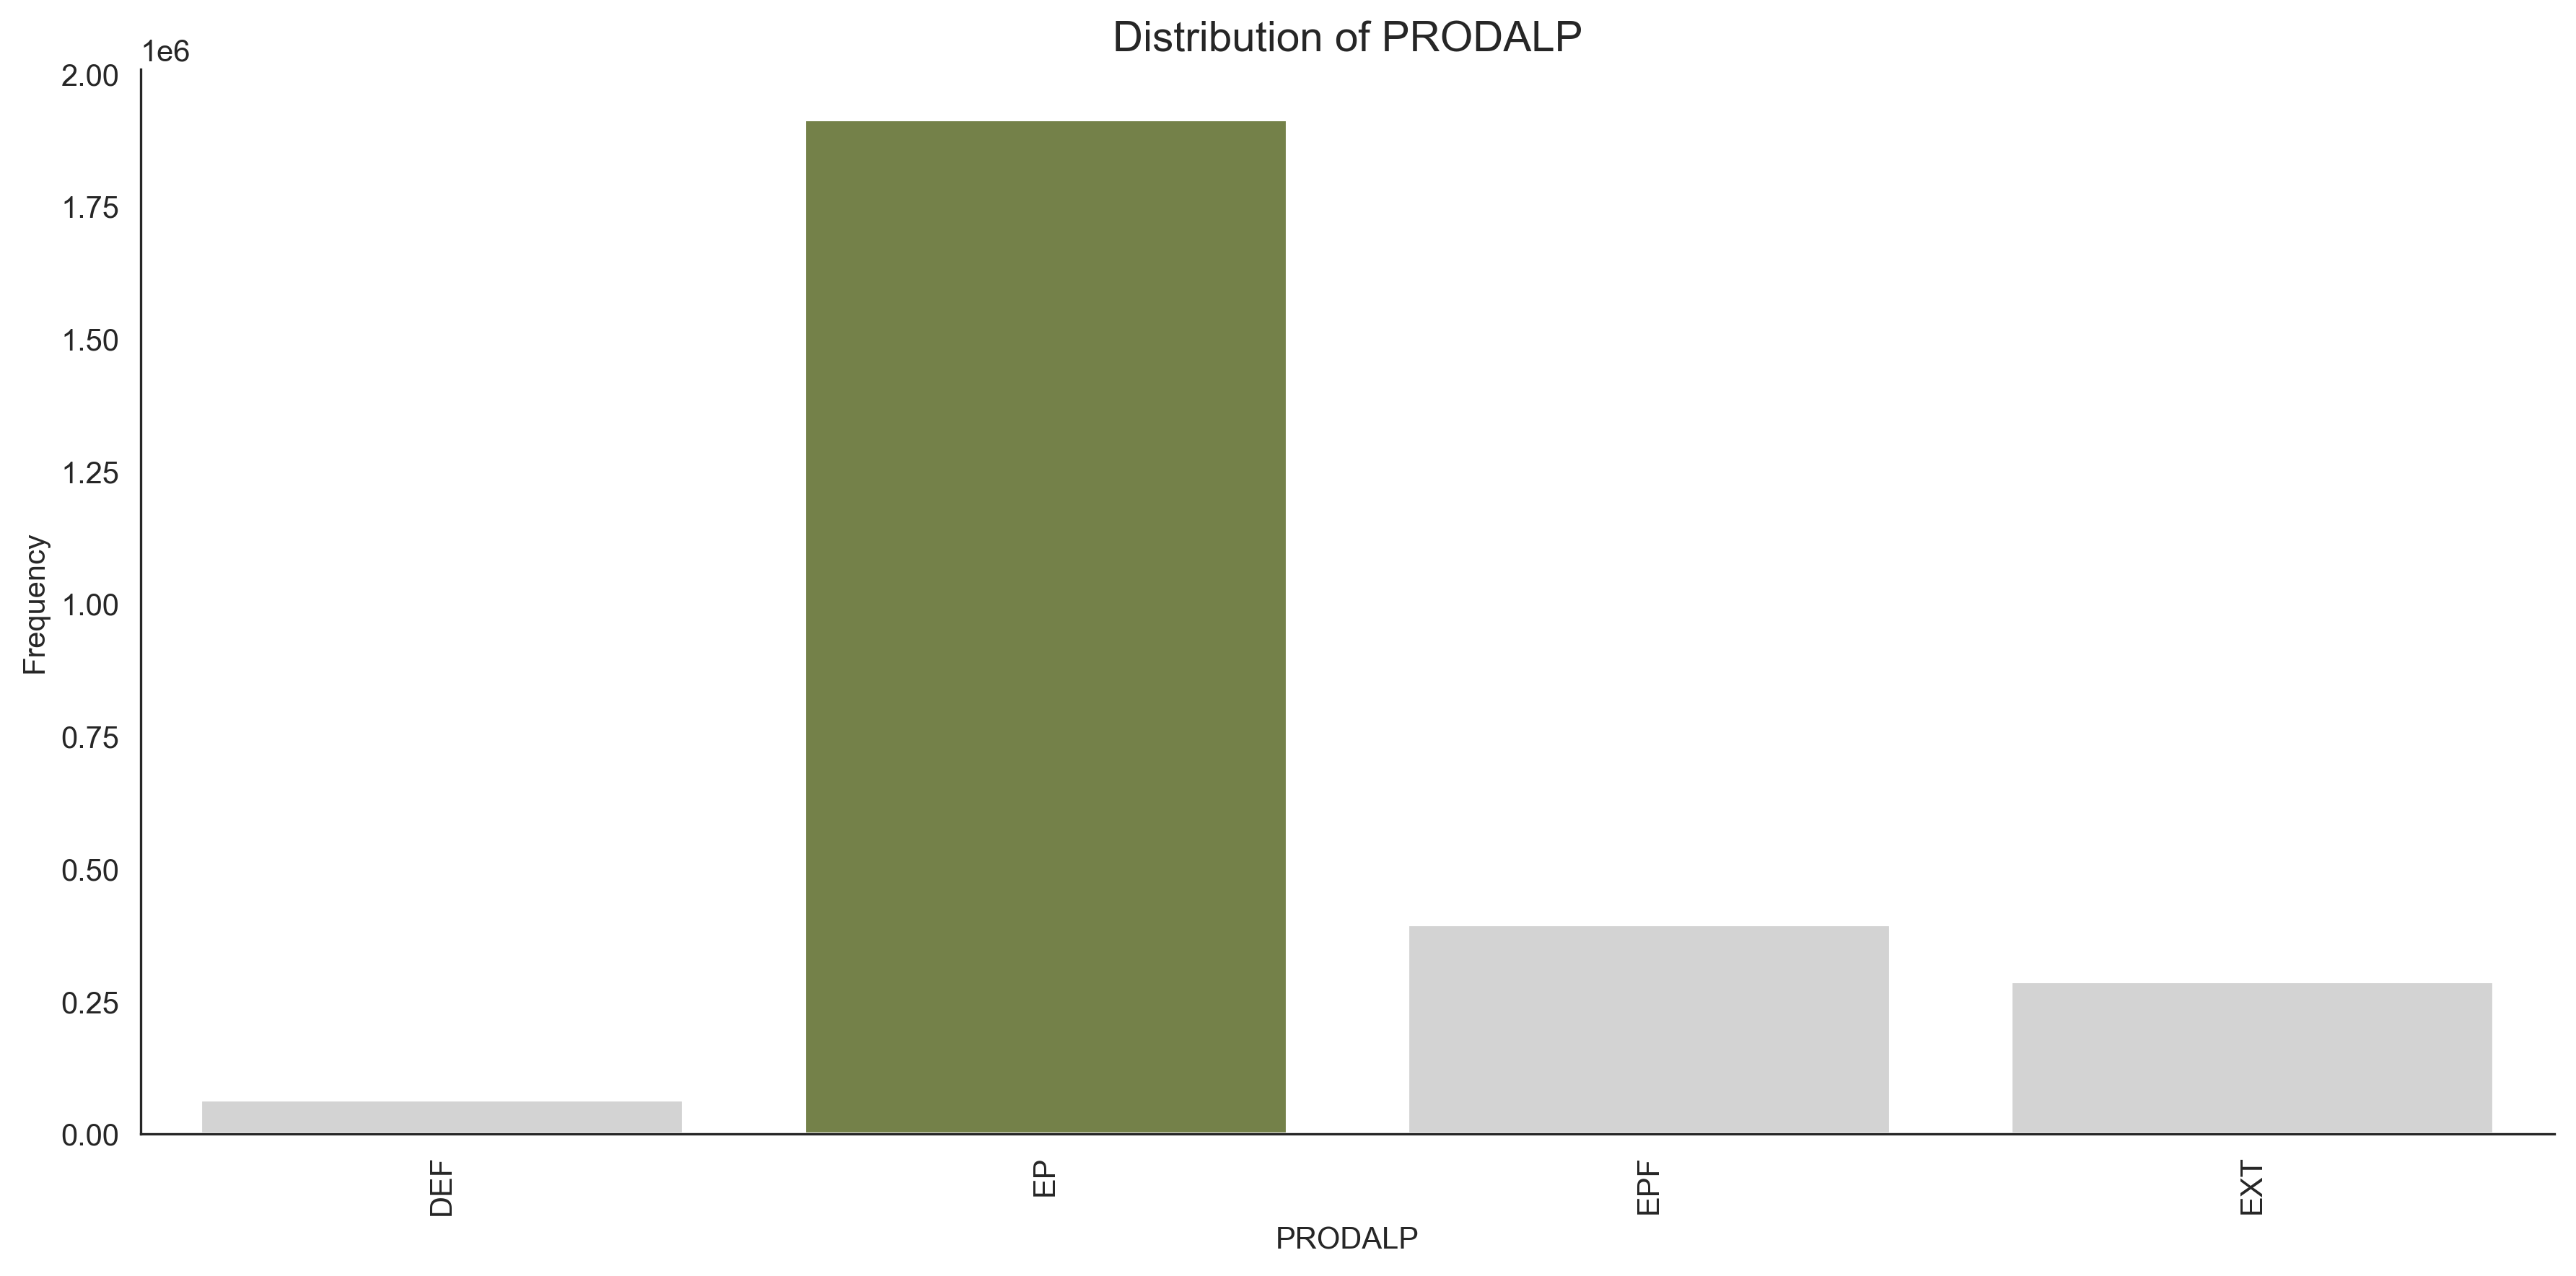

In [160]:
def plot_categorical_highlight(data, column, highlight_color="#798a40", default_color="lightgray"):

    #counting observations per category
    counts = data[column].value_counts().sort_index()

    #finding category with highest observations
    max_category = counts.idxmax()
    palette = [highlight_color if cat == max_category else default_color for cat in counts.index]

    #setting style and figure
    sns.set_style("white")
    plt.figure(dpi=300, figsize=(12,6))
    plt.gcf().patch.set_facecolor('white')  # background

    #ploting bar chart
    sns.barplot(
        x=counts.index,
        y=counts.values,
        palette=palette
    )

    plt.xticks(rotation=90)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}", fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.show()

# -----------------------------
# Example usage
# -----------------------------
for col in non_numerical_features:
    plot_categorical_highlight(BDOSS, col)

### 3.6. Checking Correlation between variables

In [161]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = BDOSS[num_cols_DB].corr(method ='spearman')
cor_spearman

,BICONTRATO,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISKA,AGFIN,RESSO,CSP,DCSP,NBENF
BICONTRATO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DURDEG,NaN,1.000000,0.364130,0.306403,0.678258,0.678291,0.341605,NaN,0.510962,-0.063407,NaN,0.032983,0.030945,0.020154,-0.011308,-0.003946,0.020566,-0.104580,0.073626
RANGPRO,NaN,0.364130,1.000000,0.629326,0.268217,0.268225,0.096455,NaN,-0.123273,-0.046085,NaN,0.030191,0.031083,0.025452,0.025405,-0.085924,0.055227,-0.250384,0.042637
RANGCLI,NaN,0.306403,0.629326,1.000000,0.246725,0.246774,0.119923,NaN,-0.021387,-0.032302,NaN,0.042116,0.041237,-0.003847,-0.142835,0.024162,0.037726,-0.307816,0.034233
MTFINO,NaN,0.678258,0.268217,0.246725,1.000000,0.999978,0.875974,NaN,0.654177,-0.075268,NaN,-0.005928,-0.004466,0.003301,-0.065762,0.113562,-0.033091,-0.121003,0.049988
MTFIN,NaN,0.678291,0.268225,0.246774,0.999978,1.000000,0.875981,NaN,0.654203,-0.075264,NaN,-0.005887,-0.004433,0.003296,-0.065711,0.113531,-0.033048,-0.120966,0.049993
MENSALIDADE,NaN,0.341605,0.096455,0.119923,0.875974,0.875981,1.000000,NaN,0.575626,-0.067251,NaN,-0.018618,-0.015734,0.000704,-0.064483,0.138536,-0.044722,-0.082188,0.017147
MENSALIDADE_CORR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CRD,NaN,0.510962,-0.123273,-0.021387,0.654177,0.654203,0.575626,NaN,1.000000,-0.114531,NaN,-0.048013,-0.046455,0.034666,-0.044136,0.096028,-0.043185,0.018859,0.026285
SREC,NaN,-0.063407,-0.046085,-0.032302,-0.075268,-0.075264,-0.067251,NaN,-0.114531,1.000000,NaN,-0.058779,-0.055721,-0.078877,-0.002627,0.010513,-0.026158,0.008712,0.021880


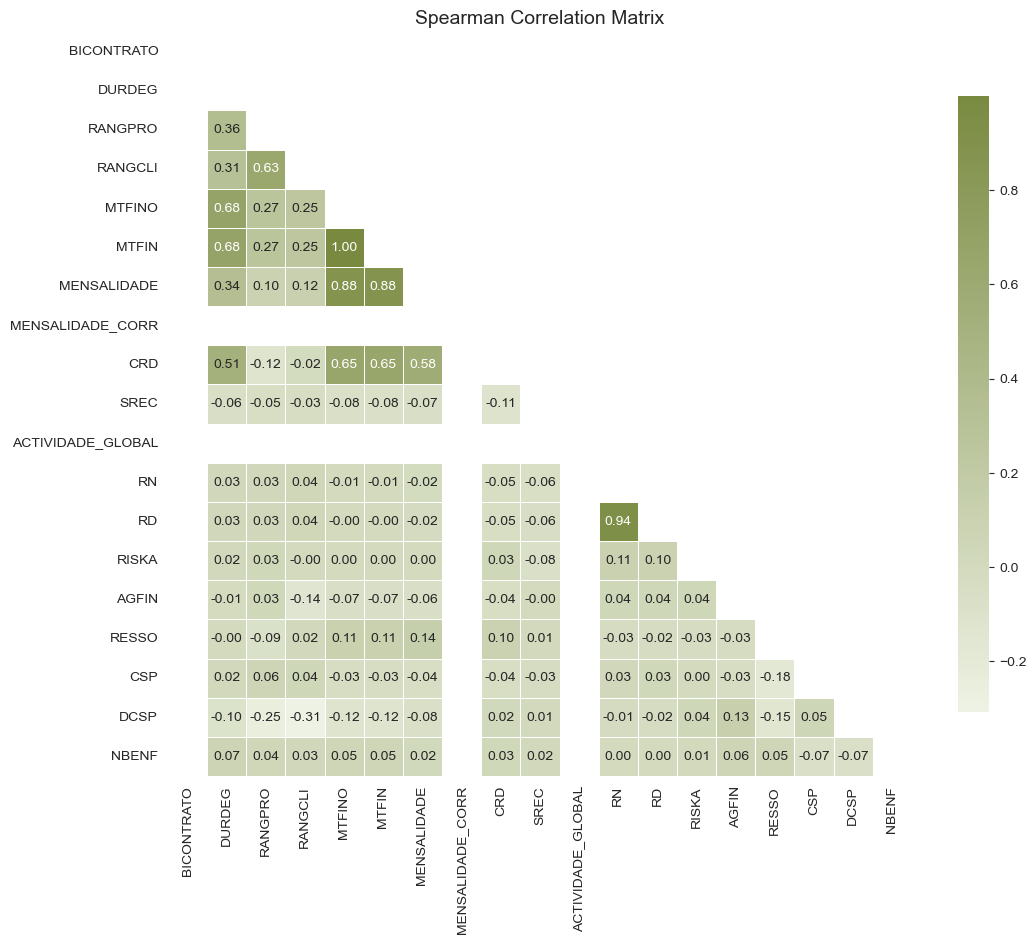

In [162]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

**Redundant Variables**:
- *MTFIN* vs *MTFINO* (1.00)
- *RN* vs *RD* (0.94)
- *MENSALIDADE* vs *MTFIN* AND *MTFINO* (0.88)

### 2.4. Checking Incoherencies

**- Constant Features**

In [163]:
#checking unique values
BDOSS['MENSALIDADE_CORR'].unique()

array([nan])

In [164]:
#checking unique values
BDOSS['ACTIVIDADE_GLOBAL'].unique()

array([nan])

In [165]:
#checking unique values
BDOSS['TYPEPROD'].unique()

array(['CL'], dtype=object)

In [166]:
#checking unique values
BDOSS['BICONTRATO'].unique()

array([0.])

**- more data analysis**

In [167]:
#checking nº of values 
BDOSS['RISK'].value_counts()

RISK
000000000000000000000000    2327930
444444444444444444444444      23863
000000000000000000000001      16652
000000000000000000000010       7487
000000000000000000000100       6278
                             ...   
010000100001000111122010          1
000000100000000010101010          1
012222222122221221111221          1
000001122222221221122100          1
000110210110000000211221          1
Name: count, Length: 77475, dtype: int64

In [168]:
#checking nº of values 
BDOSS['RISKA'].value_counts()

RISKA
0.0    2571156
1.0      79077
7.0       7954
Name: count, dtype: int64

In [169]:
#checking nº of values 
BDOSS['NBENF'].value_counts() 

NBENF
0.0     1538648
1.0      664154
2.0      385790
3.0       59785
4.0        7713
5.0        1288
8.0          23
7.0          23
10.0         11
52.0          8
6.0           6
90.0          2
Name: count, dtype: int64

In [170]:
#checking nº of values 
BDOSS['AGFIN'].value_counts()

AGFIN
118.0    1229325
117.0     720161
120.0     518201
119.0     146805
525.0      39560
112.0       3963
111.0         66
500.0         48
503.0         46
116.0          6
100.0          6
Name: count, dtype: int64

In [171]:
#checking unique values
BDOSS['POS'].unique()

array(['ENC', 'SAN', 'SOL', 'RBT'], dtype=object)

Meanings of POS's unique values:
- ENC: Normal state;
- SAN: Client settles before date;
- SOL: Client settles on contract termination date;
- RBT: Same as SAN (business wise).

Since RBT is the same as SAN, we will update our dataset so that every RBT turns into SAN.

In [172]:
#checking nº of values 
BDOSS['RN'].value_counts()

RN
0.0    2270299
1.0     257370
2.0      88703
3.0      34114
4.0       6707
5.0        970
6.0         24
Name: count, dtype: int64

RN is a red flag feature, the higher it's value, the higher the chance a client will churn.

In [173]:
#checking nº of values 
BDOSS['POLE'].value_counts()

POLE
P    2615205
N      42982
Name: count, dtype: int64

Not specified in MetaData, however, we were told that:
- P: Direct business;
- N: Sales for business partners.

**- PRODALP**

In [174]:
#checking nº of values 
BDOSS['PRODALP'].value_counts()

PRODALP
EP     1912612
EPF     394887
EXT     287176
DEF      63512
Name: count, dtype: int64

None of these unique values appear in our MetaData. However, we were told that:
- EP - most used when the clients want to churn; 
- EXT, EPF, DEF: Personal loans.

**- CSP**

In [175]:
#checking unique values
BDOSS['CSP'].unique()

array([80., 91., 35., 60., 90., 54., 70., 31., 74., 20., 58., 15., 41.,
       10., 50., 33., 56., 55., 86., 32., 30., 92., 57., 52., 53., 34.,
       40., 81., 99.,  0., 96., 25., 51.])

The values 54, 58, 50, 56, 55, 57, 52, 53, 0 and 51 also don't appear in our MetaData.

In [176]:
#checking the values that do not appear in the metadata
missing = [54, 58, 50, 56, 55, 57, 52, 53, 0, 51]
result = 0
for num in BDOSS['CSP']:
    if num in missing:
        result = result + 1
print(result)

161453


In [177]:
#checking their percentage 
result / len(BDOSS['CSP']) * 100

6.073801429320059

These values correspond to around 6% of our data

**- RISK AND RISKA**

In [178]:
#checking the obervations where the 'RISKA' does not correspond to the last number of 'RISK'
BDOSS[BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,N,CL,EXT,0.0,ENC,2024-01-31,2021-02-10,2021-02-17,2021-02-17,2024-01-31,84.0,32.0,32.0,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,NaN,2.0,4.0,000000000000000002112122,0.0,119.0,P,1113.258,80.0,2019.0,P,2835,0.0,A
53,00245abdde6b5be044bd121c4618fdcc43e90f9f0ef5bc...,64f6c53b0b8e111e029da5ea073196dbd89ae6025fd9a7...,P,CL,EP,0.0,SAN,2024-01-31,2022-12-29,2023-01-05,2023-01-05,2023-12-11,22.0,11.0,11.0,2500.0,2500.0,147.925036,NaN,0.000,0.000,NaN,1.0,3.0,000000000000020000101011,0.0,118.0,P,1451.493,80.0,2021.0,D,8125,2.0,W
57,0026b5f0de9828ec21d97c586dc791fb0671a0224617d1...,2b075e5032a850f4290d1b23e68320cd36cffb93f7dcc8...,P,CL,EP,0.0,SAN,2024-01-31,2022-02-02,2022-02-03,2022-02-03,2023-06-05,60.0,16.0,37.0,2500.0,2500.0,61.538164,NaN,0.000,0.000,NaN,3.0,9.0,000000002110122200122001,0.0,118.0,P,2009.717,10.0,2018.0,P,3090,2.0,W
72,002ddf74dace98336bfd869bdf44deab63ab07753122d6...,2a0c6243fee831fa936fc507b331b614dc6ad6b53910d6...,P,CL,EP,0.0,SOL,2024-01-31,2014-01-09,2014-01-22,2014-01-09,2022-10-04,84.0,81.0,81.0,5000.0,5000.0,118.518615,NaN,0.000,0.000,NaN,3.0,5.0,221111222112012212220111,0.0,119.0,P,1231.996,70.0,2009.0,P,7580,0.0,T
122,004cc9fa8892482a26231071d03ecb17c5a8779b683804...,56ca44ed01b953656bd0b46454b894de6b39d882e52279...,P,CL,EXT,0.0,ENC,2024-01-31,2023-04-26,2023-05-08,2023-05-05,2024-01-23,84.0,9.0,9.0,10343.0,10343.0,233.912421,NaN,11549.523,0.000,NaN,0.0,0.0,000000000000000000010110,1.0,118.0,P,2523.423,35.0,2009.0,P,2775,2.0,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2658123,ffddc57160d56f6899d2daa5e1a1720b5903a6e665354f...,c56d1af3fdeeceb79806b8dd25b0495f25f225b5428e88...,P,CL,EPF,0.0,ENC,2025-11-30,2022-01-09,2022-02-16,2022-02-16,2024-09-09,84.0,45.0,45.0,5000.0,5000.0,107.643659,NaN,3307.841,0.000,NaN,0.0,0.0,000010000000000000000000,1.0,118.0,P,313.084,52.0,NaN,P,2415,0.0,W
2658149,ffec38e28088b6290ec9ed851675f19b0182cecd14a105...,7bcb4d654fd5736dcc83846e861dfb7b2fab4b21bf7180...,P,CL,EPF,0.0,ENC,2025-11-30,2022-10-06,2022-10-14,2022-10-14,2025-11-28,84.0,38.0,38.0,11000.0,11000.0,244.084787,NaN,8467.150,0.000,NaN,0.0,0.0,000000000010001000000101,0.0,117.0,P,861.102,80.0,2000.0,P,3720,0.0,A
2658180,fffa9b9225bff7296ad890805ea9ccf9a105663acb1a97...,9638a80107e20c8cbf33e66fe0ffc642fee561907852dc...,P,CL,EXT,0.0,SAN,2025-11-30,2023-08-01,2023-08-21,2023-08-18,2025-08-12,84.0,23.0,23.0,24750.0,24750.0,584.152276,NaN,0.000,0.000,NaN,0.0,0.0,000000000000000001111111,0.0,118.0,P,1253.882,80.0,1995.0,P,4425,1.0,W
2658183,fffbc66ca4256976c9932916770f1ff3b23aacce5998ff...,dea39098d015a030ea0b3ead87c82ccca9137f784f86c7...,P,CL,EPF,0.0,ENC,2025-11-30,2018-12-21,2018-12-24,2018-12-24,2025-11-28,84.0,83.0,83.0,7430.0,7430.0,157.667572,NaN,137.403,-157.668,NaN,1.0,2.0,000000000000002001111112,0.0,118.0,P,977.381,31.0,2018.0,P,4820,1.0,W


In [179]:
#ckecking the percentage
168528 / len(BDOSS) * 100

6.339960281199178

Here, we can see that only around 6% of our data has a RISKA value diferent than the last number of RISK.

**- RANGPRO AND DURDEG**

In [180]:
#checking the observations where the diference between 'RANGPRO' and 'DURDEG' is >0
BDOSS[BDOSS['RANGPRO'] - BDOSS['DURDEG'] > 0]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
13373,1eeda66678fe87887b4e435aa1ac405c4ee922ad6bed98...,6a73d420a9c4629486e6f5dda41f27e14de45734f835ab...,P,CL,EP,0.0,SOL,2024-01-31,2017-09-14,2017-09-21,2017-09-21,2023-12-01,72.0,73.0,73.0,7000.00,7000.00,157.190164,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,1181.441,70.0,1987.0,P,2350,0.0,A
14809,22535d3248147b8e894c46602e349876a2b7a58252a7b0...,d55babf7dbe197586e7b624efb0da2d1898a90f918b7ac...,P,CL,EPF,0.0,SOL,2024-01-31,2015-05-22,2015-05-28,2015-05-22,2023-08-04,84.0,85.0,85.0,9000.46,9000.46,199.519797,NaN,0.0,0.0,NaN,1.0,1.0,100000000000000121212121,0.0,118.0,N,1851.117,90.0,2000.0,P,3610,1.0,None
23704,366d5bd958989f93f6e20d957959f964ddf065149bd715...,7e205ecd82246afc84cc94105be457755e0fe7ccd65b2f...,P,CL,EPF,0.0,SOL,2024-01-31,2016-08-08,2016-08-23,2016-08-08,2023-11-21,84.0,85.0,85.0,10500.00,10500.00,238.839973,NaN,0.0,0.0,NaN,1.0,0.0,000000110100200111000011,0.0,117.0,P,901.600,70.0,2012.0,P,2410,1.0,None
48850,7013a45ea15ab41a281691a85a99c53bb650d7b6d12745...,e0cfdfb6402b13a9540add0d348ad1d166ff5de5b99d1f...,P,CL,EPF,0.0,SOL,2024-01-31,2016-10-14,2016-10-24,2016-10-14,2024-01-01,84.0,85.0,85.0,15000.60,15000.60,341.476332,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000001000000,0.0,117.0,P,836.839,80.0,1993.0,P,7370,0.0,None
53702,7b2db95efe1f3f55ae0566731a18ef153f7ada276c4fc3...,7c2e2cb7b349743596bd6087f9b55d20d0d2ffae927505...,P,CL,EP,0.0,SOL,2024-01-31,2017-10-03,2017-10-09,2017-10-09,2024-01-01,72.0,73.0,73.0,15000.00,15000.00,344.638483,NaN,0.0,0.0,NaN,0.0,0.0,000000000000010000000000,0.0,118.0,P,1045.234,60.0,2012.0,P,2675,0.0,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2591774,747283c8dd6c2be7c5e4d86c4adcd653c3f9381b4f0e6a...,66bb8e8c16bac641e2ff3f1cfbb4f760c310ae3c652d9e...,P,CL,EP,0.0,SOL,2025-11-30,2017-05-06,2017-07-12,2017-07-12,2025-09-10,96.0,97.0,97.0,25000.00,25000.00,476.003055,NaN,0.0,0.0,NaN,1.0,2.0,002210000000000000002211,0.0,118.0,P,2710.636,81.0,2016.0,P,2430,2.0,W
2592547,761e197ef3212fef89be1a88eb9d46d862c72e699dc9f6...,91f180eb8d37733c4bd4a1c1f40cce541a84039790e78d...,P,CL,EP,0.0,SOL,2025-11-30,2019-07-02,2019-07-08,2019-07-08,2025-10-01,72.0,73.0,73.0,11000.00,11000.00,248.800673,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,662.454,20.0,2015.0,P,4500,2.0,A
2595126,7b4ae59459f74157e8dd76f2cb2a4418dae8818d89758c...,735d4904fb0d6a5daf2298cd7a3f1c6d2e419fc470ea3c...,P,CL,EP,0.0,SOL,2025-11-30,2023-08-31,2023-08-31,2023-08-31,2025-09-05,24.0,25.0,25.0,4000.00,4000.00,215.810828,NaN,0.0,0.0,NaN,2.0,7.0,020000000000000000000100,0.0,117.0,P,1238.833,74.0,2017.0,P,9300,1.0,A
2632092,c91a7037a2ec427dfb5398e8db01c486ae872b2604c0a5...,4f998ab6e24407fc3d5259d9de75fa9146bc833541686e...,P,CL,EPF,0.0,SOL,2025-11-30,2019-04-29,2019-04-29,2019-04-29,2025-08-11,72.0,73.0,73.0,16000.00,16000.00,374.958776,NaN,0.0,0.0,NaN,0.0,0.0,000000010000000000000000,0.0,118.0,P,2993.089,31.0,1998.0,P,3870,1.0,A


In [181]:
#checking the observations where the diference between 'RANGPRO' and 'DURDEG' is equal to 0
BDOSS[BDOSS['RANGPRO'] - BDOSS['DURDEG'] == 0]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
7,000607d1adce7aa9ac87274d1a2ffa84e240188de0872f...,a23e77794a2b9ab78303d8c540bd7f73ac3e3fce788fca...,P,CL,EP,0.0,SOL,2024-01-31,2018-07-31,2018-08-17,2018-08-17,2023-09-01,60.0,60.0,60.0,5000.0,5000.0,128.983684,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,912.411,60.0,2000.0,P,9680,2.0,A
80,00373284a84ad063cf446d3ddcd3b581093360d90f868d...,4f54a4a12cc205c0486eab64b9cc3b88f64f3d0d331684...,P,CL,EP,0.0,SOL,2024-01-31,2019-11-15,2019-11-18,2019-11-18,2023-12-01,48.0,48.0,48.0,4000.0,4000.0,120.673502,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,4075.148,60.0,2004.0,P,4405,0.0,A
82,0037926b6b79ef354a08b184866c44f60dcdb4c9e6bbce...,e168885d792bd5b71ded787bc796f50c8715e6519fd380...,P,CL,EP,0.0,SOL,2024-01-31,2022-01-31,2022-02-04,2022-02-04,2024-02-01,24.0,24.0,24.0,2550.0,2550.0,130.562159,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,1030.291,60.0,2021.0,P,2655,0.0,W
84,003847aa9634135bca3145e5a494f81bdf3d888e97b26c...,2ac8e2bbefdaf86ad0adad6350d0a3631b0dc97506ecee...,P,CL,EP,0.0,SOL,2024-01-31,2019-04-12,2019-04-16,2019-04-16,2024-01-02,56.0,56.0,56.0,10000.0,10000.0,247.929850,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,2503.747,60.0,2015.0,P,2675,0.0,W
152,006035d67ee018b0ef98b09a75b921601bb8eebb76b44c...,e9a06a469636f9dd6a20ba110a7b3bfbfcce301d3d485d...,P,CL,EP,0.0,SOL,2024-01-31,2018-02-06,2018-02-12,2018-02-12,2024-02-01,72.0,72.0,72.0,2500.0,2500.0,57.396444,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,831.451,86.0,1998.0,P,4595,0.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2658094,ffce63610dbb460be5181d993711dce04a91258e18659e...,7419ce475632f1f2cea9cd315bb5d001cc9fa36a1cf009...,P,CL,EP,0.0,SOL,2025-11-30,2023-01-17,2023-02-01,2023-02-01,2025-08-01,30.0,30.0,73.0,1500.0,1500.0,68.447232,NaN,0.0,0.0,NaN,1.0,8.0,000000000000000000000000,0.0,118.0,P,1115.982,60.0,2022.0,P,9500,0.0,W
2658109,ffd469fd2b43c5de080a48312af88069823680eb1d86f2...,5e853d677ae5d207d07ff52d5c43b82e7407f8c516101f...,P,CL,EP,0.0,SOL,2025-11-30,2023-08-10,2023-08-14,2023-08-14,2025-08-01,24.0,24.0,24.0,5500.0,5500.0,311.509961,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,1582.440,74.0,1994.0,P,2970,2.0,W
2658137,ffe7a79c9555711286b52c99ddae968134558142c6400d...,98d451dabef588274b9eef60a64943a5370a5ed22f2915...,P,CL,EP,0.0,SOL,2025-11-30,2018-06-10,2018-07-16,2018-07-16,2025-08-01,84.0,84.0,84.0,7000.0,7000.0,132.402437,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,694.528,31.0,2017.0,P,4560,2.0,W
2658162,fff437ed8b6c8eb46dee5ab5968d2abb4eabd769eac974...,c267c3b05999dfecbdc5b40c725b6611982fb0f02bf2dc...,P,CL,EP,0.0,SOL,2025-11-30,2023-02-09,2023-03-06,2023-03-06,2025-09-01,30.0,30.0,30.0,2500.0,2500.0,115.844357,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,1495.553,80.0,2022.0,P,6060,1.0,W


In the cells above, we can see that there are 253 rows in BDOSS with a RANGPRO value higher than it's respective DURDEG value. We can also see that this diference is exactly 1 in every row.

## 4. Data Preparation

### 4.1. Changing Datatypes

In [182]:
#changing datatypes
BDOSS['BICONTRATO'] = BDOSS['BICONTRATO'].round().astype('Int32')
BDOSS['DURDEG'] = BDOSS['DURDEG'].round().astype('Int32')
BDOSS['RANGPRO'] = BDOSS['RANGPRO'].round().astype('Int32')
BDOSS['RANGCLI'] = BDOSS['RANGCLI'].round().astype('Int32')
BDOSS['RISKA'] = BDOSS['RISKA'].round().astype('Int32')
BDOSS['CSP'] = BDOSS['CSP'].round().astype('Int32')
BDOSS['DCSP'] = BDOSS['DCSP'].round().astype('Int32')

### 4.2. Handling Incoherencies

In [183]:
#replacing every RBT with SAN
BDOSS['POS'] = BDOSS['POS'].replace('RBT', 'SAN')

In [184]:
#correcting observations so every RISKA value corresponds to the last number of it's respective RISK value
mask = BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)

BDOSS.loc[mask, 'RISK'] = (BDOSS.loc[mask, 'RISK'].astype(str).str[:-1] + 
                           BDOSS.loc[mask, 'RISKA'].astype(str))

BDOSS[BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO


In [185]:
mask = (BDOSS['RANGPRO'] == BDOSS['DURDEG'] + 1)
BDOSS.loc[mask, 'RANGPRO'] = BDOSS.loc[mask, 'DURDEG']

### 4.3. Handling Missing Values

In [186]:
#droping 'MENSALIDADE_CORR' and'ACTIVIDADE_GLOBAL' due to its elevated number of missing values
BDOSS = BDOSS.drop(columns=['MENSALIDADE_CORR'])
BDOSS = BDOSS.drop(columns=['ACTIVIDADE_GLOBAL'])

In [187]:
#filling missing values of categorical variables with mode
for col in ['RANGCLI', 'NATIO', 'MODCONTACTO']:
    BDOSS[col] = BDOSS[col].fillna(BDOSS[col].mode()[0])

#filling missing values of numeric variables with median
for col in ['DCSP', 'NBENF']:
    BDOSS[col] = BDOSS[col].fillna(BDOSS[col].median())

### 4.4. Handling Outliers

In [188]:
#setting a maximum number for each variable that needs outliers treated
BDOSS['MTFINO'] = BDOSS['MTFINO'].clip(upper=80000)
BDOSS['MTFIN'] = BDOSS['MTFIN'].clip(upper=80000)
BDOSS['MENSALIDADE'] = BDOSS['MENSALIDADE'].clip(upper=4000)
BDOSS['CRD'] = BDOSS['CRD'].clip(upper=100000)
BDOSS['SREC'] = BDOSS['SREC'].clip(upper=40000)
BDOSS['RESSO'] = BDOSS['RESSO'].clip(upper=700000)
BDOSS['NBENF'] = BDOSS['NBENF'].clip(upper=10)

### 4.5. Feature Engineering

In [189]:
BDOSS = BDOSS.sort_values(['CONTRIB', 'DOSSIER', 'OBS_DATE']).copy()

#conting how many times has CRD= 0 in each contract
zero_count = (
    BDOSS['CRD'].eq(0)
    .groupby([BDOSS['CONTRIB'], BDOSS['DOSSIER']])
    .cumsum()
)

#keeping all rows with CRD diferent from 0 and only the first row with CRD=0
BDOSS = BDOSS[(BDOSS['CRD'] != 0) | (zero_count == 1)].copy()

In [190]:
#creating 'DIF_CRD_NEXT'
BDOSS['DIF_CRD_NEXT'] = BDOSS['CRD'] - (BDOSS.groupby(['CONTRIB', 'DOSSIER'])['CRD'].shift(-1))
col = BDOSS.pop('DIF_CRD_NEXT')
BDOSS.insert(19, 'DIF_CRD_NEXT', col)
BDOSS.head()

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,CRD,DIF_CRD_NEXT,SREC,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
576857,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,P,CL,EP,0,ENC,2024-06-30,2024-06-25,2024-06-27,2024-06-27,2024-06-27,84,0,19,8000.0,8000.0,158.359889,9575.287,77.933,0.0,0.0,0.0,000000000000000000000000,0,118.0,P,1278.521,74,2020,P,8600,0.0,W
694260,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,P,CL,EP,0,ENC,2024-07-31,2024-06-25,2024-06-27,2024-06-27,2024-06-27,84,1,19,8000.0,8000.0,158.359889,9497.354,78.628,0.0,0.0,0.0,000000000000000000000000,0,118.0,P,1278.521,74,2020,P,8600,0.0,W
812122,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,P,CL,EP,0,ENC,2024-08-31,2024-06-25,2024-06-27,2024-06-27,2024-06-27,84,2,19,8000.0,8000.0,158.359889,9418.726,9418.726,0.0,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80,2024,P,8600,0.0,W
930223,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,P,CL,EP,0,SAN,2024-09-30,2024-06-25,2024-06-27,2024-06-27,2024-10-03,84,3,19,8000.0,8000.0,158.359889,0.000,NaN,0.0,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80,2024,P,8600,0.0,W
930224,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,P,CL,EP,0,ENC,2024-09-30,2024-09-13,2024-09-30,2024-09-30,2024-09-30,120,1,19,16000.0,16000.0,280.401466,19336.270,82.508,0.0,0.0,0.0,000000000000000000000000,0,118.0,P,1513.466,80,2024,P,8600,0.0,W


**- DELAY (amount of time, in months, that the client delayed payments)**

In [191]:
#creating 'DELAY'
conditions = [
    BDOSS['DIF_CRD_NEXT'] == 0.00,                
    BDOSS['DIF_CRD_NEXT'] > BDOSS['MENSALIDADE'], 
    BDOSS['DIF_CRD_NEXT'] < BDOSS['MENSALIDADE']  
]

choices = [-1, 1, 0]

BDOSS['DELAY'] = np.select(conditions, choices, default=0)

### 4.5. Data Aggregation

In [192]:
#aggregating every dossier by client
agg_dossier = (BDOSS.groupby(['CONTRIB', 'DOSSIER']).agg(

    is_san=('POS', lambda x: int(x.eq('SAN').any())),
    is_sol=('POS', lambda x: int(x.eq('SOL').any())), 
    DCREAT = ('DCREAT', 'first'),
    DCRD_0 = ('OBS_DATE', lambda x: x[BDOSS.loc[x.index, 'CRD'] == 0].min()),
    CLOSE_DATE = ('OBS_DATE', lambda x: x[BDOSS.loc[x.index, 'POS'].isin(['SAN','SOL'])].min()),

    DURDEG = ('DURDEG', 'first'),
    RANGPRO_max = ('RANGPRO', 'max'),
    RANGCLI_max = ('RANGCLI', 'max'),
    delay_sum = ('DELAY', 'sum'),
    
    MENSALIDADE = ('MENSALIDADE', 'first'),     
    CRD_min = ('CRD', 'min'),
    MTFINO = ('MTFINO', 'first'),
    RESSO_mean = ('RESSO', 'mean'),
    RISKA_mean = ('RISKA', 'mean'),
    NBENF_mean = ('NBENF', 'mean'),
    RN_mean = ('RN', 'mean'),
    SREC = ('SREC', 'mean'),

    POLE = ('POLE', moda),
    PRODALP = ('PRODALP', moda),
    AGFIN = ('AGFIN', moda),
    PAGAMENTO = ('PAGAMENTO', moda),
    CSP = ('CSP', moda),
    NATIO = ('NATIO', moda),
    PTT = ('PTT', moda),
    MODCONTACTO = ('MODCONTACTO', moda),
).reset_index())

In [193]:
#checking duplicates
dup_check = BDOSS.groupby('DOSSIER')['CONTRIB'].nunique()
dup_check[dup_check > 1]

DOSSIER
460dcd6cbad835e35fe9a84084e5f3dc49177b5fb7b02f7c4677d7ebac822a2f    2
50fbe6c6479962fef8576b412584dc5c5075bb88aabc75ddd0dac8d8a1a0962f    2
592cac52e59fb2da9e997a2cd1550ab06a843c41f7f234141d72573baeb2196a    2
8a60cbae6c0c2d4d56a44d2900367098b8b9154de7cad6107c0b81306fbabc3c    2
a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9fad2a8bf9f125d63db    2
b03d9715994dfae5e11b41eaf3919afcec05864565b8dffa23baa12c48950e13    2
e20fa81de6820d6a8f77ae5003c6d28315e6718685335ff99c241052b02c80e8    2
f8908577ee5bab0f764f1f007f439370b0511585b89d96f41bf1a00cffdddea9    2
Name: CONTRIB, dtype: int64

- After this first agregation we can see that 8 dossiers appear twice on our agg_dossier DataFrame.

- We determined that the reason is for the clients to be married and share the dossiers.

In [194]:
#creating 'NEXT_DOSSIER_DATE'
def next_valid_dossier(group):
    group = group.copy()
    group = group.sort_values('DCREAT')

    next_dates = []
    dcreat = group['DCREAT']
    close = group['CLOSE_DATE']

    for i in range(len(group)):
        if pd.isna(close.iloc[i]):
            next_dates.append(pd.NaT)
            continue

        current_close = close.iloc[i]
        current_dcreat = dcreat.iloc[i]

        future_loans = dcreat[
            ((dcreat.dt.to_period('M') == current_close.to_period('M')) | (dcreat > current_close)) 
            & (dcreat != current_dcreat)]

        if len(future_loans) > 0:
            next_dates.append(future_loans.min())
        else:
            next_dates.append(pd.NaT)

    group['NEXT_DOSSIER_DATE'] = next_dates
    return group

In [195]:
#applying the feature to the aggregation
agg_dossier = (agg_dossier.groupby('CONTRIB', group_keys=False).apply(next_valid_dossier))

C:\Users\alano\AppData\Local\Temp\ipykernel_16168\1357571478.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_dossier = (agg_dossier.groupby('CONTRIB', group_keys=False).apply(next_valid_dossier))


In [196]:
#creating 'CHURN' and 'DAYS_TO_NEXT'
agg_dossier['DAYS_TO_NEXT'] = (agg_dossier['NEXT_DOSSIER_DATE'] - agg_dossier['CLOSE_DATE']).dt.days

same_month = (agg_dossier['NEXT_DOSSIER_DATE'].dt.to_period('M') == agg_dossier['CLOSE_DATE'].dt.to_period('M'))

agg_dossier['CHURN'] = None

closed = agg_dossier['CLOSE_DATE'].notna()

agg_dossier.loc[closed, 'CHURN'] = ((
    (agg_dossier.loc[closed, 'DAYS_TO_NEXT'] > 30) |
    (agg_dossier.loc[closed, 'DAYS_TO_NEXT'].isna())) & ~same_month.loc[closed])

In [197]:
#checking the amount of dossiers that did churn
agg_dossier[agg_dossier['CHURN'] == True]

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN
1,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,1,0,2024-09-13,2025-11-30,2025-11-30,120,13,19,1,280.401466,0.0,16000.00,1513.466000,0.0,0.0,0.0,0.000000,P,EP,118.0,P,80,P,8600,W,NaT,NaN,True
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,0,1,2001-09-21,2024-03-31,2024-03-31,60,21,21,0,424.699203,0.0,13467.54,678.483000,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaT,NaN,True
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,0,1,2001-09-27,2024-03-31,2024-03-31,60,21,21,0,184.214593,0.0,5985.57,678.483000,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaT,NaN,True
5,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,1,0,2019-01-28,2024-01-31,2024-01-31,72,34,34,0,56.017772,0.0,2500.00,838.186000,0.0,0.0,1.0,0.000000,P,EP,120.0,N,91,P,2855,A,NaT,NaN,True
8,000406feeb8088e3b05f47bc89160d25ca14f11c31f91b...,a87dd90b5a28bd8cbeb9b20e4dd8a169da6cbf7df649cd...,0,1,2007-06-29,2024-03-31,2024-03-31,84,24,24,0,274.916857,0.0,12000.00,797.805000,0.0,0.0,1.0,0.000000,P,EP,117.0,P,86,P,2835,W,NaT,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185594,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,78350b49408237d9be0249768a20c97f5b40f8260b0a46...,1,0,2021-10-26,2024-10-31,2024-10-31,84,36,61,2,51.206134,0.0,3000.00,1347.630800,0.1,3.0,0.0,0.000000,P,EP,119.0,P,91,P,9500,A,NaT,NaN,True
185593,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,44646b249bca38e9954ca24c81aa0dd55c1f286a257394...,0,1,2022-09-27,2024-09-30,2024-09-30,24,24,61,0,268.768666,0.0,5000.00,1346.169444,0.0,3.0,0.0,0.000000,P,EP,117.0,P,91,P,9500,A,NaT,NaN,True
185595,fffc991d73df732084dab58938d520b8a5d8712474fa53...,8a1945dd1c8ef5d381bef27f69ef52bd6b19729822aea7...,0,1,2021-02-12,2024-01-31,2024-01-31,34,34,34,0,57.095138,0.0,1500.00,896.196000,0.0,1.0,0.0,0.000000,P,EP,118.0,P,80,P,4400,W,NaT,NaN,True
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a...,1,0,2022-03-24,2024-03-31,2024-03-31,84,23,34,1,267.471639,0.0,12000.00,955.766667,0.333333,0.0,0.0,233.510333,P,EPF,117.0,P,80,P,2845,A,NaT,NaN,True


In [198]:
#checking the amount of dossiers that did not churn
agg_dossier[agg_dossier['CHURN'] == False]

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,1,0,2024-06-25,2024-09-30,2024-09-30,84,3,19,1,158.359889,0.0,8000.0,1395.993500,0.0,0.0,0.0,0.0,P,EP,118.0,P,74,P,8600,W,2024-09-13,-17.0,False
39,000c1d07343251f8247578d802494996ca054de69ae681...,f866de3c37745d2433775e19afb759d6ae0aeb00f4612d...,1,0,2021-08-22,2024-04-30,2024-04-30,48,33,49,1,145.411896,0.0,5000.0,974.963000,0.0,1.0,0.0,0.0,P,EP,118.0,P,80,P,4905,W,2024-04-24,-6.0,False
60,00149cbc9d281f794f957fc691905844f42035af4c4d9e...,72f86fcc886c99f94892670980ae38f266b5e2074b7cbf...,1,0,2023-07-19,2024-03-31,2024-03-31,12,7,7,1,100.509416,0.0,1000.0,1016.720000,0.0,0.0,0.0,0.0,P,EP,120.0,P,70,P,2260,W,2024-03-05,-26.0,False
59,00149cbc9d281f794f957fc691905844f42035af4c4d9e...,6b347a98d42ec86f0c37baf26e5a185a9ae3d17457b101...,1,0,2025-03-10,2025-06-30,2025-06-30,18,3,8,1,104.281126,0.0,1500.0,0.000000,0.0,0.0,0.0,0.0,P,EP,118.0,P,70,P,2260,W,2025-06-03,-27.0,False
71,00170e09c3513a7d90d7da6c7d062927e046828149002d...,86be94cdc9622e4b80ebeb8202ba91f5bac2ad54489016...,1,0,2020-12-15,2024-05-31,2024-05-31,84,40,40,1,253.918539,0.0,11500.0,1160.698600,0.0,0.0,0.0,0.0,P,EPF,118.0,P,80,P,4750,W,2024-05-02,-29.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185486,ffd6b39c894811d541e243af9adfeabf047aa0caf54f42...,0f9891a35fab02a1d924709eabfaa0b3d8174c3bebd91e...,1,0,2022-07-18,2024-06-30,2024-06-30,84,24,28,1,239.299064,0.0,11000.0,2618.933667,0.0,0.0,1.0,0.0,P,EPF,117.0,P,90,P,2890,A,2024-06-11,-19.0,False
185532,ffe9965b0a0e5843ce22374239297679ed7e4aee360933...,125bfbc036486945a3dccfebefc0b266ec5b6109d813dd...,1,0,2024-07-08,2025-05-31,2025-05-31,24,10,25,1,83.847769,0.0,1500.0,978.552818,0.0,1.0,1.0,0.0,P,EP,120.0,P,70,P,6300,W,2025-05-06,-25.0,False
185533,ffe9965b0a0e5843ce22374239297679ed7e4aee360933...,210386962d96eaabbe0c19f2ba87c2c49cfac772dde0ba...,1,0,2025-01-11,2025-05-31,2025-05-31,24,4,25,1,55.276709,0.0,1000.0,708.864600,0.0,1.0,1.0,0.0,P,EP,118.0,P,70,P,6300,W,2025-05-06,-25.0,False
185531,ffe9965b0a0e5843ce22374239297679ed7e4aee360933...,10559778b8dd000c3eb801cfbff21c00d1fa14753c51d7...,1,0,2025-02-24,2025-05-31,2025-05-31,24,1,25,1,83.929798,0.0,1500.0,0.000000,0.0,1.0,1.0,0.0,P,EP,118.0,P,60,P,6300,W,2025-05-06,-25.0,False


In [199]:
#checking if 'CHURN' has any missing values
agg_dossier[agg_dossier['CHURN'].isna()]

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN
2,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,0,0,2018-03-29,NaT,NaT,120,91,91,0,347.447280,8115.247,20000.0,1113.258,0.0,1.0,0.000000,15.106391,P,EP,120.0,P,80,P,2845,A,NaT,NaN,None
6,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,0,0,2019-09-23,NaT,NaT,84,74,74,0,100.073575,883.500,5000.0,1314.144,0.0,2.0,0.000000,0.000000,P,EP,118.0,P,80,P,2635,W,NaT,NaN,None
7,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,446d96905d26356fb4f1d3e1e6da3868b8106b09a558e6...,0,0,2023-01-09,NaT,NaT,60,35,37,0,162.097525,3419.266,6000.0,1031.650,0.0,0.0,0.000000,0.000000,P,EPF,117.0,P,80,P,5090,A,NaT,NaN,None
9,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,0,0,2021-02-10,NaT,NaT,84,43,43,2,463.755537,14665.602,20500.0,1113.258,0.3,0.0,1.900000,-46.375600,N,EXT,119.0,P,80,P,2835,A,NaT,NaN,None
11,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6...,cd128e1f3c6d6bc9dd2414eeb60f44241977a35fd94885...,0,0,2023-09-11,NaT,NaT,48,27,121,0,131.155715,2349.858,4080.0,877.293,0.0,1.0,0.000000,0.000000,P,EP,117.0,P,80,P,4475,A,NaT,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185588,fffbc66ca4256976c9932916770f1ff3b23aacce5998ff...,dea39098d015a030ea0b3ead87c82ccca9137f784f86c7...,0,0,2018-12-21,NaT,NaT,84,83,83,1,157.667572,137.403,7430.0,977.381,0.0,1.0,0.045455,-7.166727,P,EPF,118.0,P,31,P,4820,W,NaT,NaN,None
185590,fffbfb06fdb05fb48a739b0a23650122a66ff61669a5b3...,ac0c808a63bb91659f6f5af780a60c1de56b705618be2a...,0,0,2025-03-03,NaT,NaT,120,9,49,0,251.897648,17422.059,15000.0,0.000,0.0,0.0,0.000000,0.000000,P,EP,118.0,P,55,P,2745,W,NaT,NaN,None
185591,fffc47b191b25cbc3dbc9ce436b94e52d2084144ee5bec...,43fefbb99328741294aa67fa5bb29cdaf0acff276e282d...,0,0,2025-05-29,NaT,NaT,36,6,6,0,81.856368,1994.881,2000.0,0.000,0.142857,2.0,0.000000,1.923143,P,EP,120.0,P,80,P,4485,W,NaT,NaN,None
185596,fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a...,b6e4983596a5a38f9bfd54da8bff33bcae0bfc46138f9a...,0,0,2021-06-17,NaT,NaT,60,53,53,0,416.654611,2563.528,15000.0,1623.880,0.0,0.0,0.000000,0.000000,P,EP,120.0,P,80,P,9560,W,NaT,NaN,None


In [200]:
#checking umber of missing values in each column as a percentage
agg_dossier.isna().sum()/len(agg_dossier) * 100

CONTRIB               0.000000
DOSSIER               0.000000
is_san                0.000000
is_sol                0.000000
DCREAT                0.000000
DCRD_0               58.088362
CLOSE_DATE           58.703664
DURDEG                0.000000
RANGPRO_max           0.000000
RANGCLI_max           0.000000
delay_sum             0.000000
MENSALIDADE           0.000000
CRD_min               0.000000
MTFINO                0.000000
RESSO_mean            0.000000
RISKA_mean            0.000000
NBENF_mean            0.000000
RN_mean               0.000000
SREC                  0.000000
POLE                  0.000000
PRODALP               0.000000
AGFIN                 0.000000
PAGAMENTO             0.000000
CSP                   0.000000
NATIO                 0.000000
PTT                   0.000000
MODCONTACTO           0.000000
NEXT_DOSSIER_DATE    89.866379
DAYS_TO_NEXT         89.866379
CHURN                58.703664
dtype: float64

In [201]:
#creating 'OBS_END_DATE' and 'DOSSIER_DURATION_DAYS'
agg_dossier2 = agg_dossier.sort_values(['CONTRIB', 'DCREAT']).reset_index(drop=True)

latest_date = BDOSS['OBS_DATE'].max()

agg_dossier2['OBS_END_DATE'] = agg_dossier2['CLOSE_DATE'].fillna(latest_date)

agg_dossier2['DOSSIER_DURATION_DAYS'] = (agg_dossier2['OBS_END_DATE'] - agg_dossier2['DCREAT']).dt.days

In [202]:
def create_history_features(group):
    group = group.sort_values('DCREAT').copy()

    #number of previous dossiers
    group['N_PREVIOUS_DOSSIERS'] = np.arange(len(group))

    #mean dossier duration time
    group['AVG_DURATION'] = (group['DOSSIER_DURATION_DAYS'].shift(1).expanding().mean())

    #previous churn rate
    churn_numeric = group['CHURN'].map({True: 1, False: 0})

    prev_churn_sum = churn_numeric.shift(1).fillna(0).cumsum()
    prev_closed_count = churn_numeric.shift(1).notna().cumsum()

    group['previous_churn_rate'] = np.where(prev_closed_count > 0,
                                            prev_churn_sum / prev_closed_count,
                                            np.nan)

    #time passed between dossier creation
    group['time_between_dossiers'] = (group['DCREAT'] - group['DCREAT'].shift(1)).dt.days

    return group

In [203]:
#applying the feature to the aggregation
agg_dossier2 = (agg_dossier2.groupby('CONTRIB', group_keys=False).apply(create_history_features).reset_index(drop=True))

C:\Users\alano\AppData\Local\Temp\ipykernel_16168\2827063628.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_dossier2 = (agg_dossier2.groupby('CONTRIB', group_keys=False).apply(create_history_features).reset_index(drop=True))


In [204]:
#creating 'AVG_DURATION', 'previous_churn_rate' and 'time_between_dossiers'
agg_dossier2['AVG_DURATION'] = agg_dossier2['AVG_DURATION'].fillna(-1)
agg_dossier2['previous_churn_rate'] = agg_dossier2['previous_churn_rate'].fillna(-1)
agg_dossier2['time_between_dossiers'] = agg_dossier2['time_between_dossiers'].fillna(-1)

## 5. Merging Datasets

In [205]:
#merging the all datasets for clustering
BNP = (
    agg_dossier
    .merge(CRC_agg, on='CONTRIB', how='left')
    .merge(CREDSCORE, on='CONTRIB', how='left')
    .merge(FAMA, on='CONTRIB', how='left')
)
BNP.head()

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN,count_cl_mean,montvenc_cl_mean,montabatv_cl_mean,dividas_cl_mean,subcount_total_mean,montenc_total_mean,montabatv_total_mean,dividas_total_mean,HIGH_RISK_CURRENT,kp_sqe,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,1,0,2024-06-25,2024-09-30,2024-09-30,84,3,19,1,158.359889,0.000,8000.00,1395.9935,0.0,0.0,0.0,0.000000,P,EP,118.0,P,74,P,8600,W,2024-09-13,-17.0,False,0.36,0.0,0.0,2565.7936,5.28,0.0,0.0,17196.2076,0.0,H,2,1.0,120.0,0.033333,10,S,F,33,0.272727
1,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,1,0,2024-09-13,2025-11-30,2025-11-30,120,13,19,1,280.401466,0.000,16000.00,1513.4660,0.0,0.0,0.0,0.000000,P,EP,118.0,P,80,P,8600,W,NaT,NaN,True,0.36,0.0,0.0,2565.7936,5.28,0.0,0.0,17196.2076,0.0,H,2,1.0,120.0,0.033333,10,S,F,33,0.272727
2,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,0,0,2018-03-29,NaT,NaT,120,91,91,0,347.447280,8115.247,20000.00,1113.2580,0.0,1.0,0.0,15.106391,P,EP,120.0,P,80,P,2845,A,NaT,NaN,None,4.32,0.0,0.0,26448.0320,9.72,0.0,0.0,34000.1492,0.0,D,1,0.0,120.0,0.675000,10,C,P,52,0.090909
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,0,1,2001-09-21,2024-03-31,2024-03-31,60,21,21,0,424.699203,0.000,13467.54,678.4830,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaT,NaN,True,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,<NA>
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,0,1,2001-09-27,2024-03-31,2024-03-31,60,21,21,0,184.214593,0.000,5985.57,678.4830,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaT,NaN,True,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,<NA>


In [206]:
#merging the all datasets for classification
BNP2 = (
    agg_dossier2
    .merge(CRC_agg, on='CONTRIB', how='left')
    .merge(CREDSCORE, on='CONTRIB', how='left')
    .merge(FAMA, on='CONTRIB', how='left')
)
BNP2.head()

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN,OBS_END_DATE,DOSSIER_DURATION_DAYS,N_PREVIOUS_DOSSIERS,AVG_DURATION,previous_churn_rate,time_between_dossiers,count_cl_mean,montvenc_cl_mean,montabatv_cl_mean,dividas_cl_mean,subcount_total_mean,montenc_total_mean,montabatv_total_mean,dividas_total_mean,HIGH_RISK_CURRENT,kp_sqe,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,1,0,2024-06-25,2024-09-30,2024-09-30,84,3,19,1,158.359889,0.000,8000.00,1395.9935,0.0,0.0,0.0,0.000000,P,EP,118.0,P,74,P,8600,W,2024-09-13,-17.0,False,2024-09-30,97,0,-1.0,-1.0,-1.0,0.36,0.0,0.0,2565.7936,5.28,0.0,0.0,17196.2076,0.0,H,2,1.0,120.0,0.033333,10,S,F,33,0.272727
1,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,1,0,2024-09-13,2025-11-30,2025-11-30,120,13,19,1,280.401466,0.000,16000.00,1513.4660,0.0,0.0,0.0,0.000000,P,EP,118.0,P,80,P,8600,W,NaT,NaN,True,2025-11-30,443,1,97.0,0.0,80.0,0.36,0.0,0.0,2565.7936,5.28,0.0,0.0,17196.2076,0.0,H,2,1.0,120.0,0.033333,10,S,F,33,0.272727
2,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,0,0,2018-03-29,NaT,NaT,120,91,91,0,347.447280,8115.247,20000.00,1113.2580,0.0,1.0,0.0,15.106391,P,EP,120.0,P,80,P,2845,A,NaT,NaN,None,2025-11-30,2803,0,-1.0,-1.0,-1.0,4.32,0.0,0.0,26448.0320,9.72,0.0,0.0,34000.1492,0.0,D,1,0.0,120.0,0.675000,10,C,P,52,0.090909
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,0,1,2001-09-21,2024-03-31,2024-03-31,60,21,21,0,424.699203,0.000,13467.54,678.4830,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaT,NaN,True,2024-03-31,8227,0,-1.0,-1.0,-1.0,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,<NA>
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,0,1,2001-09-27,2024-03-31,2024-03-31,60,21,21,0,184.214593,0.000,5985.57,678.4830,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaT,NaN,True,2024-03-31,8221,1,8227.0,1.0,6.0,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,<NA>


In [207]:
#checking number of duplicates
BNP.duplicated().sum()

np.int64(0)

In [208]:
#checking number of duplicates
BNP2.duplicated().sum()

np.int64(0)

In [209]:
#checking number of missing values in each column as a percentage
BNP.isna().sum()/len(BNP) * 100

CONTRIB                        0.000000
DOSSIER                        0.000000
is_san                         0.000000
is_sol                         0.000000
DCREAT                         0.000000
DCRD_0                        58.088362
CLOSE_DATE                    58.703664
DURDEG                         0.000000
RANGPRO_max                    0.000000
RANGCLI_max                    0.000000
delay_sum                      0.000000
MENSALIDADE                    0.000000
CRD_min                        0.000000
MTFINO                         0.000000
RESSO_mean                     0.000000
RISKA_mean                     0.000000
NBENF_mean                     0.000000
RN_mean                        0.000000
SREC                           0.000000
POLE                           0.000000
PRODALP                        0.000000
AGFIN                          0.000000
PAGAMENTO                      0.000000
CSP                            0.000000
NATIO                          0.000000


In [210]:
#checking number of missing values in each column as a percentage
BNP2.isna().sum()/len(BNP) * 100

CONTRIB                        0.000000
DOSSIER                        0.000000
is_san                         0.000000
is_sol                         0.000000
DCREAT                         0.000000
DCRD_0                        58.088362
CLOSE_DATE                    58.703664
DURDEG                         0.000000
RANGPRO_max                    0.000000
RANGCLI_max                    0.000000
delay_sum                      0.000000
MENSALIDADE                    0.000000
CRD_min                        0.000000
MTFINO                         0.000000
RESSO_mean                     0.000000
RISKA_mean                     0.000000
NBENF_mean                     0.000000
RN_mean                        0.000000
SREC                           0.000000
POLE                           0.000000
PRODALP                        0.000000
AGFIN                          0.000000
PAGAMENTO                      0.000000
CSP                            0.000000
NATIO                          0.000000


In [211]:
#filling missing values of numeric variables with median
for col in ['count_cl_mean', 'montvenc_cl_mean', 'montabatv_cl_mean', 'dividas_cl_mean', 'subcount_total_mean', 'montenc_total_mean',
        'montabatv_total_mean', 'dividas_total_mean', 'HIGH_RISK_CURRENT', 'ks_score_tier', 'is_risky', 'ALLBD_mean_duration_CL__N',
        'ALLBD_mean_lifecycle_CL__N', 'ALLBD_N_events__N', 'sdem_age', 'active_credit_ratio']:
    BNP[col] = BNP[col].fillna(BNP[col].median())
    BNP2[col] = BNP2[col].fillna(BNP2[col].median())

In [212]:
#filling missing values of categorical variables with mode
for col in ['sdem_SITFAM', 'sdem_HABITAT']:
    BNP[col] = BNP[col].fillna(BNP[col].mode()[0])
    BNP2[col] = BNP2[col].fillna(BNP2[col].mode()[0])

In [213]:
#filling missing values
BNP['kp_sqe'] = BNP['kp_sqe'].fillna('Unknown')
BNP2['kp_sqe'] = BNP2['kp_sqe'].fillna('Unknown')

In [214]:
#checking number of missing values in each column as a percentage
BNP.isna().sum()/len(BNP) * 100

CONTRIB                        0.000000
DOSSIER                        0.000000
is_san                         0.000000
is_sol                         0.000000
DCREAT                         0.000000
DCRD_0                        58.088362
CLOSE_DATE                    58.703664
DURDEG                         0.000000
RANGPRO_max                    0.000000
RANGCLI_max                    0.000000
delay_sum                      0.000000
MENSALIDADE                    0.000000
CRD_min                        0.000000
MTFINO                         0.000000
RESSO_mean                     0.000000
RISKA_mean                     0.000000
NBENF_mean                     0.000000
RN_mean                        0.000000
SREC                           0.000000
POLE                           0.000000
PRODALP                        0.000000
AGFIN                          0.000000
PAGAMENTO                      0.000000
CSP                            0.000000
NATIO                          0.000000


## 5. Exporting the Dataset into an Excel

In [215]:
#exporting preprocessed dataset for clustering
submission = pd.DataFrame(BNP)
submission.to_csv("Preprocessed_dataset_BNP.csv", index=False)

In [216]:
#exporting preprocessed dataset for classification
submission_teste = pd.DataFrame(BNP2)
submission_teste.to_csv("Preprocessed_dataset_BNP2.csv", index=False)